# **Raquel Marques - Text Mining Project**

**Category Articles from *Folha de São Paulo* newspaper**

Last Updated: 2026-05-31

---

# <span style="color:blue">Business Context</span>

A Brazilian news aggregation platform needs to automatically categorize articles from *Folha de S.Paulo*, eliminating the manual editorial curation process that currently consumes around 40 hours per week.

You are the data scientist responsible for building, comparing, and recommending the best production-ready approach. The system must achieve a macro F1-score ≥ 0.75 to be considered operationally viable.

**Dataset**
- Source: Kaggle - [News of the Brazilian Newspaper](kaggle.com/datasets/marlesson/news-of-the-site-folhauol)
- File: articles.csv
- Columns: id, url, title, text, category
- Volume: ~167,000 articles across 48 categories


Legend:
* <span style="color:green">Explanation</span>: Provides detailed reasoning or context for concepts and processes.
* <span style="color:purple">Tips</span>: Offers practical advice or best practices to improve efficiency or outcomes.
* <span style="color:red">Practice</span>: Highlights actionable steps or exercises to apply the concepts.
* <span style="color:blue">Business Context</span>: Connects the technical work to relevant business objectives or scenarios.

## Initial Setup

- Library
- Path
- Dataset

In [1]:
a0="rodando"

In [2]:
# LIBRARY
import os
import kagglehub
import time

import pandas as pd
import numpy as np
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re                          # regular expression
from collections import Counter    # count elements frequency
import nltk
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.decomposition import TruncatedSVD

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

# print(kagglehub.__version__)

In [3]:
# pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124

In [4]:
# PATH
project_dir = os.path.join(os.path.expanduser("~"), 
                           "OneDrive", 
                           "Project_Code",
                           "ASN-DSA-T5", 
                           "31-TM",
                           "Project_1")



In [5]:
# DATASET
# Download data from Kaggle
dataset_path = kagglehub.dataset_download(
    "marlesson/news-of-the-site-folhauol",
    output_dir=os.path.join(project_dir, "data")
)

print(f"Downloaded to: {dataset_path}")


Downloaded to: C:\Users\kel_m\OneDrive\Project_Code\ASN-DSA-T5\31-TM\Project_1\data


In [6]:
# Ingest file
df = pd.read_csv(os.path.join(project_dir, "data", "articles.csv"))
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 167053 entries, 0 to 167052
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   title        167053 non-null  str  
 1   text         166288 non-null  str  
 2   date         167053 non-null  str  
 3   category     167053 non-null  str  
 4   subcategory  29635 non-null   str  
 5   link         167053 non-null  str  
dtypes: str(6)
memory usage: 7.6 MB


In [7]:
df.head()

,title,text,date,category,subcategory,link
0,"Lula diz que está 'lascado', mas que ainda tem...",Com a possibilidade de uma condenação impedir ...,2017-09-10,poder,NaN,http://www1.folha.uol.com.br/poder/2017/10/192...
1,"'Decidi ser escrava das mulheres que sofrem', ...","Para Oumou Sangaré, cantora e ativista malines...",2017-09-10,ilustrada,NaN,http://www1.folha.uol.com.br/ilustrada/2017/10...
2,Três reportagens da Folha ganham Prêmio Petrob...,Três reportagens da Folha foram vencedoras do ...,2017-09-10,poder,NaN,http://www1.folha.uol.com.br/poder/2017/10/192...
3,Filme 'Star Wars: Os Últimos Jedi' ganha trail...,A Disney divulgou na noite desta segunda-feira...,2017-09-10,ilustrada,NaN,http://www1.folha.uol.com.br/ilustrada/2017/10...
4,CBSS inicia acordos com fintechs e quer 30% do...,"O CBSS, banco da holding Elopar dos sócios Bra...",2017-09-10,mercado,NaN,http://www1.folha.uol.com.br/mercado/2017/10/1...


## Part 1: Dataset Exploration and Curation


In [8]:
# Q1
# Category Count
cat_count = df['category'].value_counts()
cat_count

# Imbalance Ratio
freq_more = cat_count.max()
freq_less = cat_count.min()
freq_ratio = freq_more / freq_less

print(f'Total categories: {df["category"].nunique()}')
print(f'Most frequent category: {freq_more}')
print(f'Less frequent category: {freq_less}')
print(f'Imbalance ratio: {freq_ratio:.2f}')

# Row count
total = cat_count.sum()


Total categories: 48
Most frequent category: 22022
Less frequent category: 1
Imbalance ratio: 22022.00


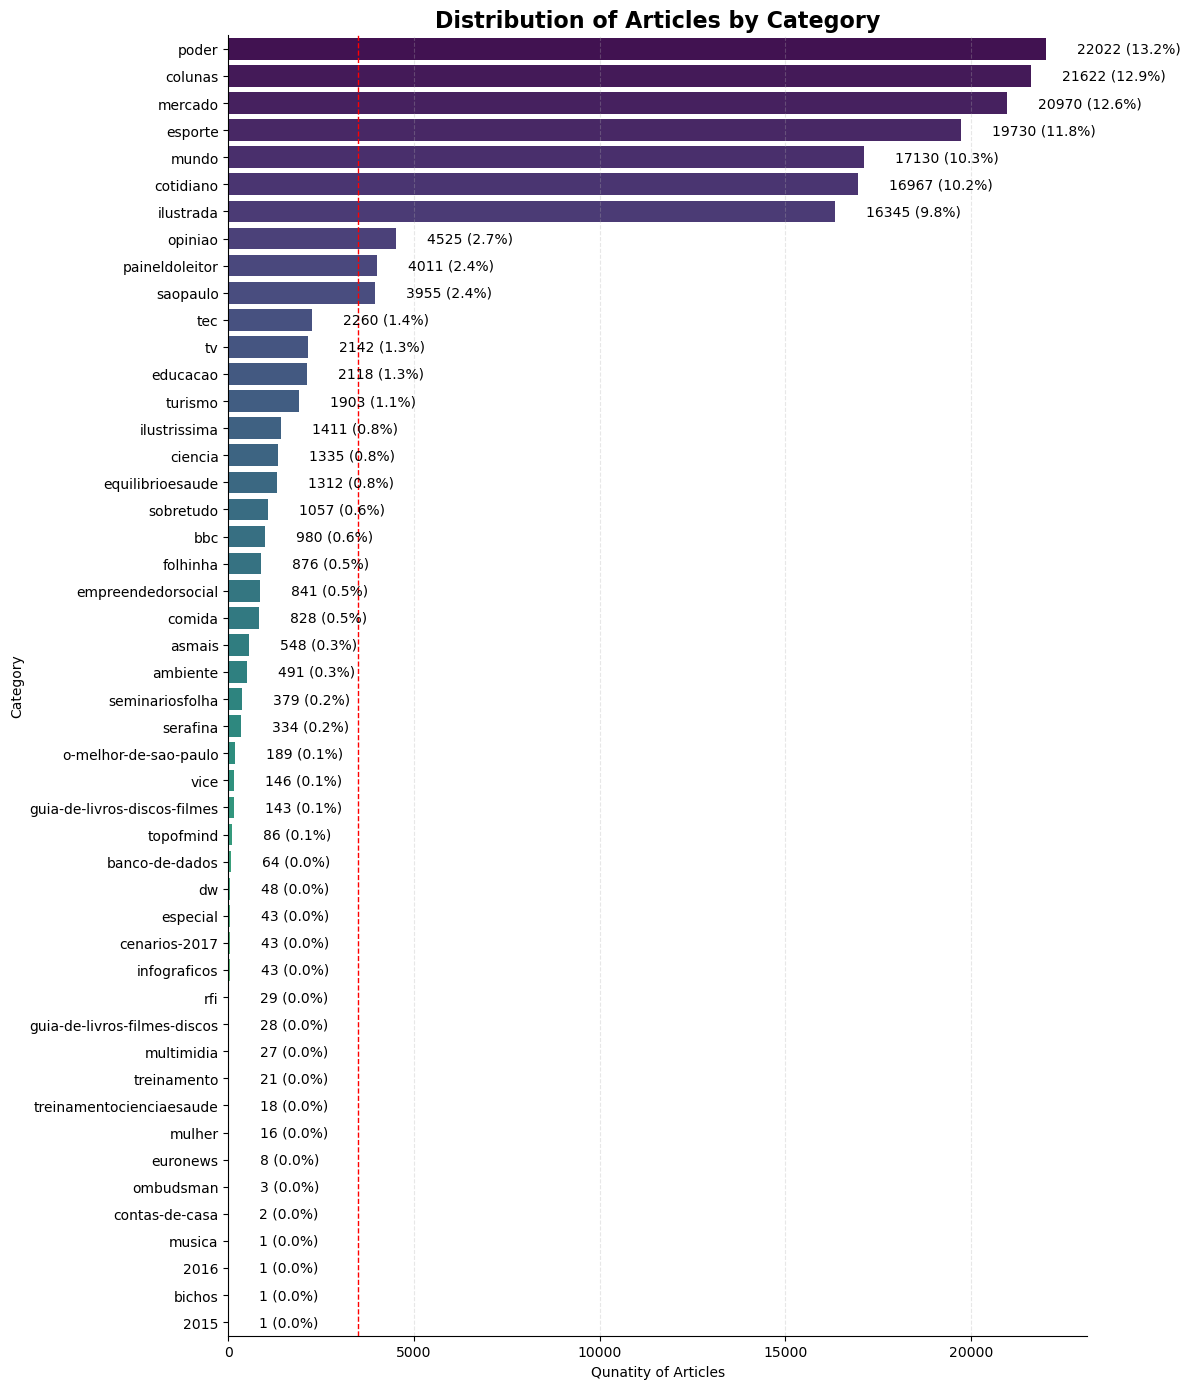

In [9]:
# Chart
plt.figure(figsize=(12,14))

ax = sns.barplot(
    x=cat_count.values,
    y=cat_count.index,
    hue=cat_count.index,
    palette='viridis',
    legend=False
)

# Avg Line
mean_value = cat_count.mean()
plt.axvline(mean_value, color='red', linestyle='--', linewidth=1)

# Labels + percentage
for i, v in enumerate(cat_count.values):
    percentage_value = (v / total) * 100
    ax.text(
        v + (total * 0.005),
        i,
        f'{v} ({percentage_value:.1f}%)',
        va='center',
        fontsize=10
    )

plt.title('Distribution of Articles by Category', fontsize=16, weight='bold')
plt.xlabel('Qunatity of Articles')
plt.ylabel('Category')

plt.grid(axis='x', linestyle='--', alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()

### <span style="color:green">Q1. Class Distribution</span>

> Visualize the frequency of articles per category (all 48 categories). 
> - What is the level of class imbalance? 
> - Calculate the ratio between the most frequent and the least frequent category. 
> - What direct impact does this imbalance have on the choice of evaluation metric and on the training strategy?
>

The dataset presents an **extreme class imbalance**, with article frequencies varying substantially across the 48 categories. The most frequent category, *poder*, contains 22,022 articles, while the least frequent categories, *bichos* and *musica*, contain only 1 article each, resulting in an imbalance ratio of: $\frac{22022}{1} = 22022$ .

This means the largest class is **22,022 times more represented** than the smallest classes, characterizing the dataset as **extremely imbalanced**.

Such imbalance has a direct impact on both the evaluation strategy and the model training process:
- Evaluation Metrics:
    - Accuracy alone becomes unreliable because the model can achieve high overall accuracy by predicting only majority classes while ignoring minority ones. 
    - So, metrics such as Macro F1-score, Precision, Recall, and per-class evaluation are more appropriate, since they give equal importance to all classes regardless of frequency.
- Training Strategy:
    - The model may become biased toward dominant categories, reducing its ability to correctly classify rare classes. To mitigate this issue, techniques such as:
        - class weighting,
        - oversampling minority classes,
        - undersampling majority classes,
        - stratified train/test splits, 
        - or data augmentation may be necessary.

Additionally, categories with only one sample are problematic because the model cannot properly learn representative patterns from them, and these classes may even need to be removed or grouped depending on the modeling objective.

In [10]:
# Q2
# Calculate word count per TITLE and TEXT
df['title_len'] = df['title'].fillna('').apply(lambda x: len(x.split()))
df['text_len'] = df['text'].fillna('').apply(lambda x: len(x.split()))

title_mean = df['title_len'].mean()
text_mean = df['text_len'].mean()

C:\Users\kel_m\AppData\Local\Temp\ipykernel_36380\2589953902.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\kel_m\AppData\Local\Temp\ipykernel_36380\2589953902.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


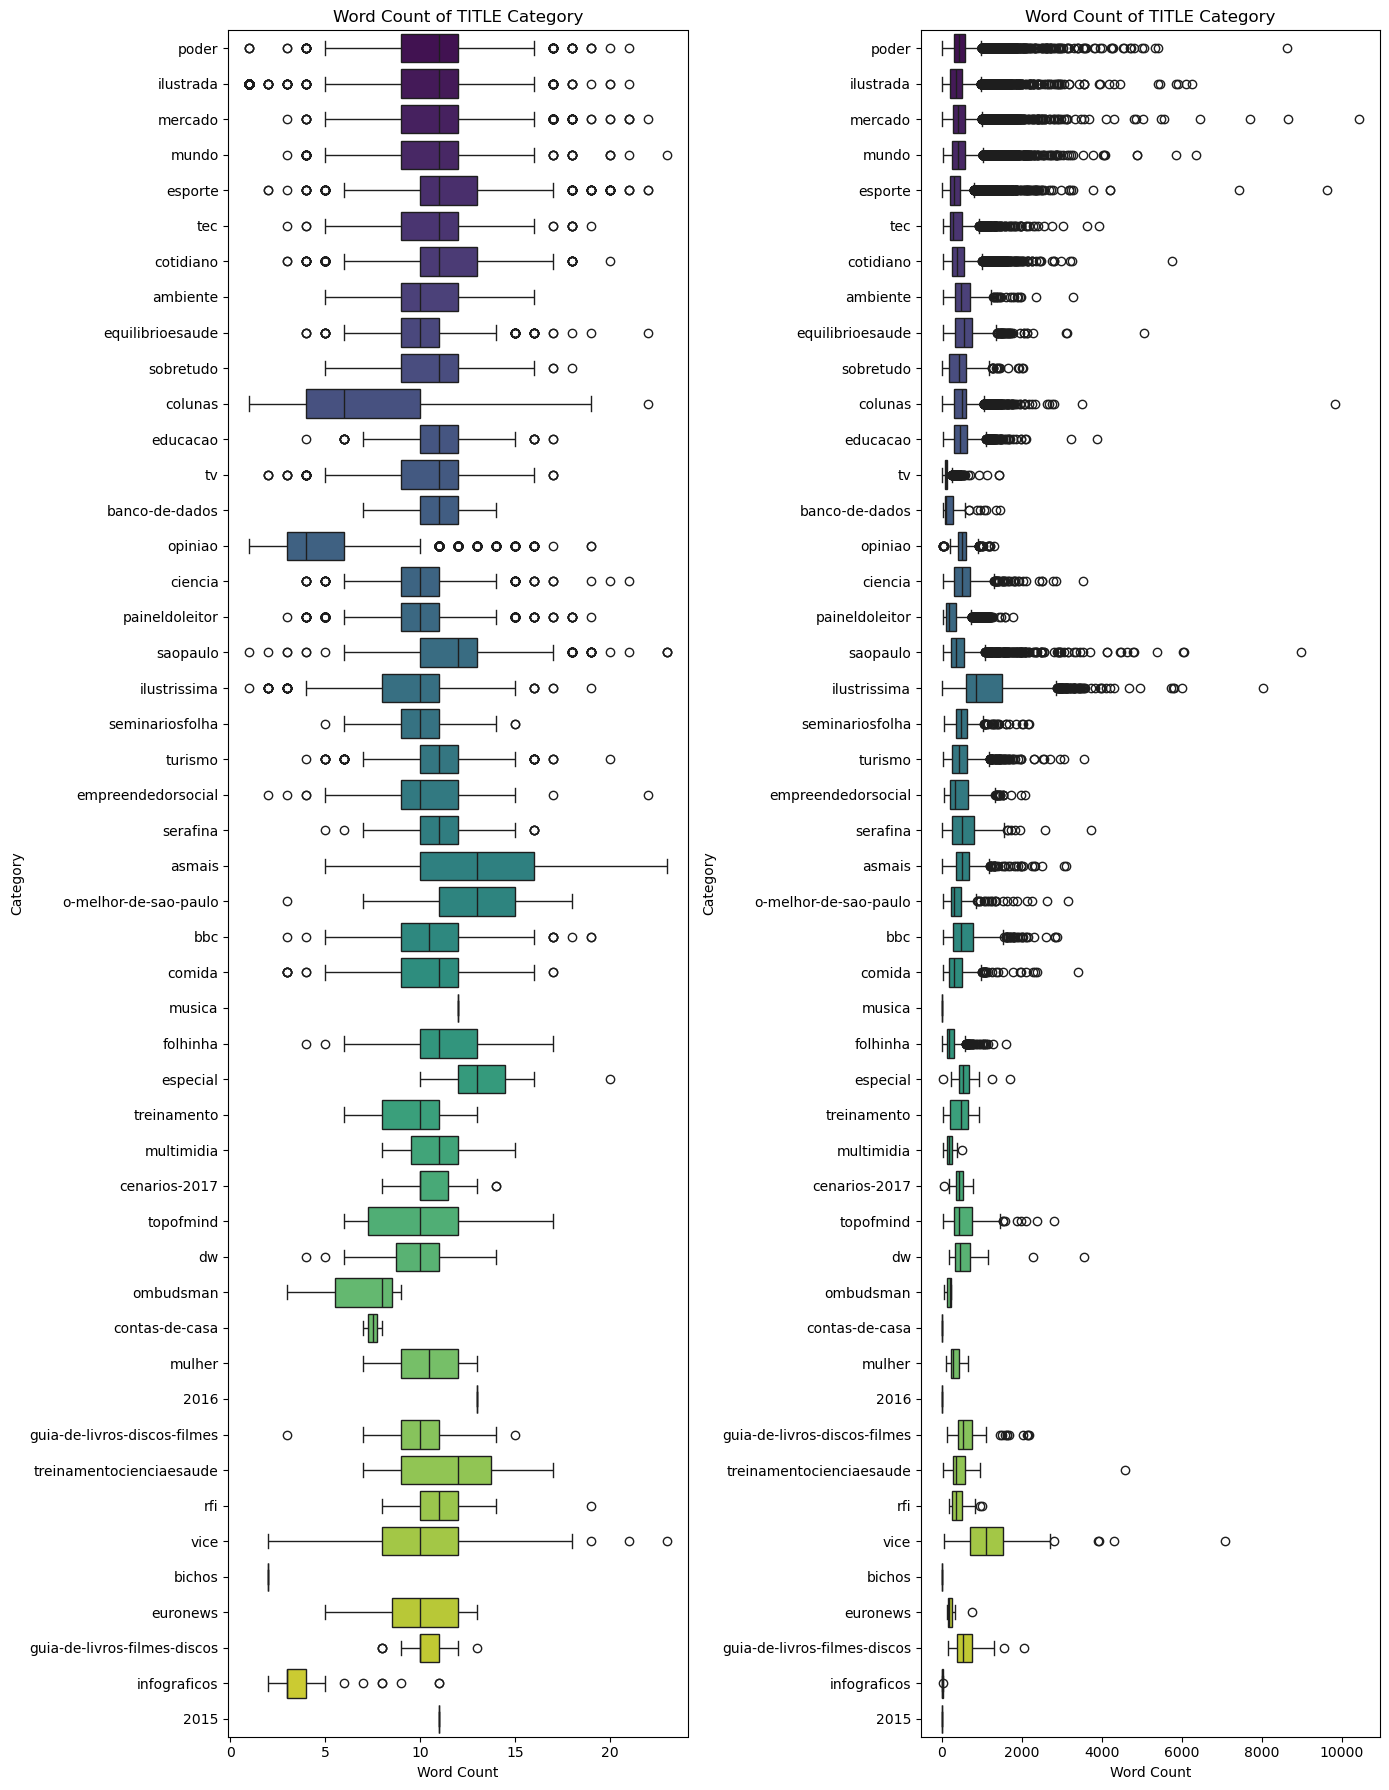

In [11]:
# Chart - combined
plt.figure(figsize=(14,18))

# Chart 1 - Word Count of TITLE by Category
plt.subplot(1,2,1)
sns.boxplot(
    data=df,
    y='category',
    x='title_len',
    palette='viridis'
)
plt.title('Word Count of TITLE Category')
plt.xlabel('Word Count')
plt.ylabel('Category')

# Chart 2 - Word Count of TEXT by Category
plt.subplot(1,2,2)
sns.boxplot(
    data=df,
    y='category',
    x='text_len',
    palette='viridis'
)
plt.title('Word Count of TITLE Category')
plt.xlabel('Word Count')
plt.ylabel('Category')

plt.tight_layout()
plt.show()

     

C:\Users\kel_m\AppData\Local\Temp\ipykernel_36380\3774977350.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


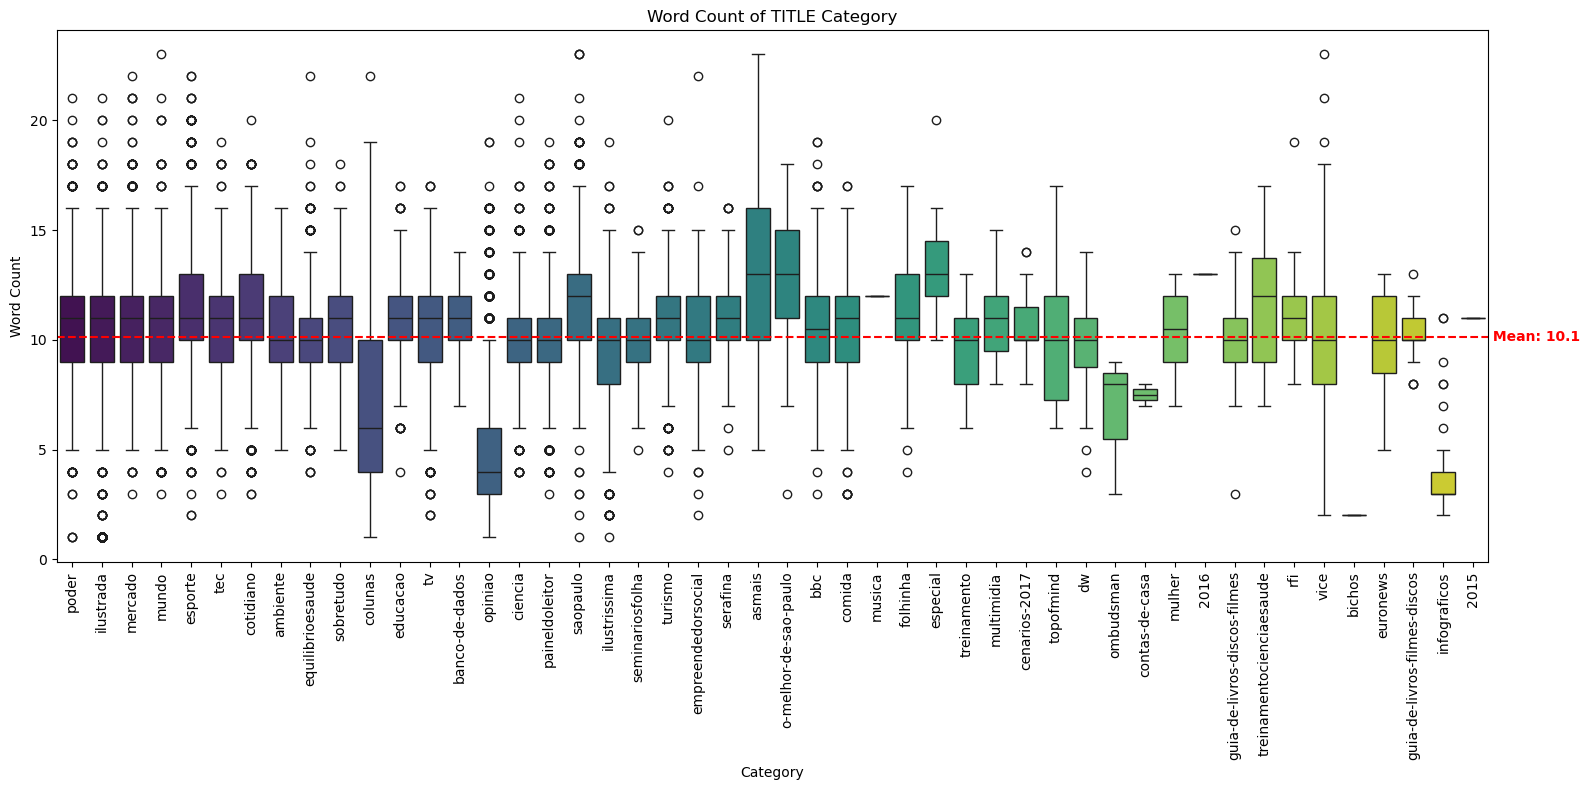

C:\Users\kel_m\AppData\Local\Temp\ipykernel_36380\3774977350.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


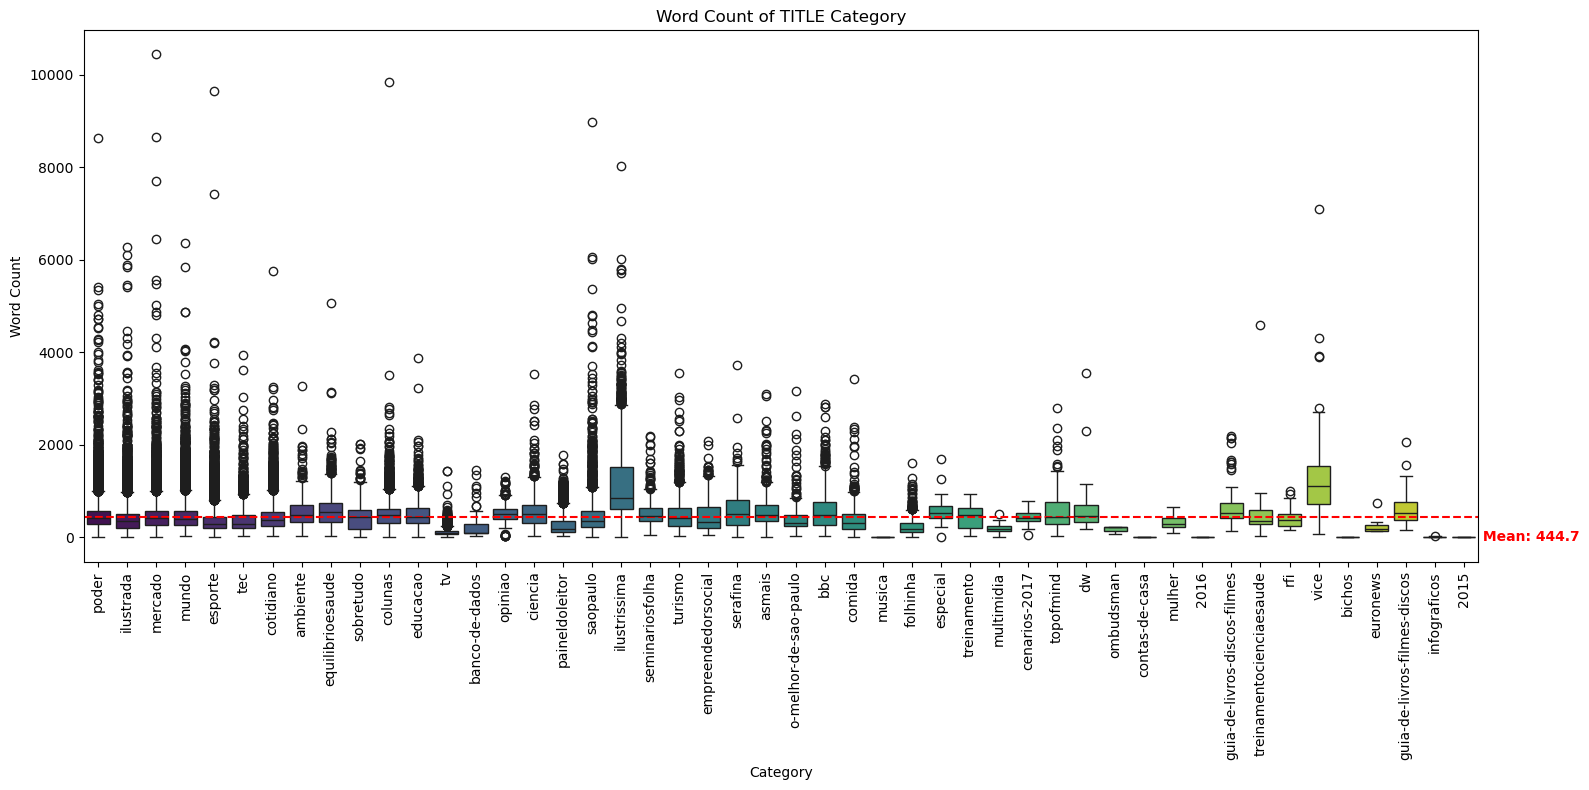

In [12]:
# Chart 1 - Word Count of TITLE by Category
plt.figure(figsize=(16, 8))
ax = sns.boxplot(
    data=df,
    x='category',
    y='title_len',
    palette='viridis'
)
ax.axhline(title_mean, color='red', linestyle='--')
ax.text(
    x=ax.get_xlim()[1],          # Places text at the far right of the x-axis
    y=title_mean,                # Vertical position matches the line
    s=f' Mean: {title_mean:.1f}', # The actual text
    color='red',                 # Match the line color
    va='center',                 # Vertical alignment: center on the line
    fontweight='bold'            # Optional styling
)

plt.title('Word Count of TITLE Category')
plt.ylabel('Word Count')
plt.xlabel('Category')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Chart 2 - Word Count of TEXT by Category
plt.figure(figsize=(16, 8))
ax = sns.boxplot(
    data=df,
    x='category',
    y='text_len',
    palette='viridis'
)
ax.axhline(text_mean, color='red', linestyle='--')
ax.text(
    x=ax.get_xlim()[1],          # Places text at the far right of the x-axis
    y=title_mean,                # Vertical position matches the line
    s=f' Mean: {text_mean:.1f}', # The actual text
    color='red',                 # Match the line color
    va='center',                 # Vertical alignment: center on the line
    fontweight='bold'            # Optional styling
)

plt.title('Word Count of TITLE Category')
plt.ylabel('Word Count')
plt.xlabel('Category')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [13]:
# Descriptive Statistics
# TITLE
summary_stats_title = df.groupby('category')['title_len'].agg(['count', 'median', 'mean', 'var', 'std']).round(2)
summary_stats_title = summary_stats_title.sort_values(by='median', ascending=False)

print("\nTitle Length Statistics by Category:")
print(summary_stats_title)


# TEXT
summary_stats_text = df.groupby('category')['text_len'].agg(['count', 'median', 'mean', 'var', 'std']).round(2)
summary_stats_text = summary_stats_text.sort_values(by='median', ascending=False)

print("\nText Length Statistics by Category:")
print(summary_stats_text)




Title Length Statistics by Category:
                              count  median   mean    var   std
category                                                       
2016                              1    13.0  13.00    NaN   NaN
asmais                          548    13.0  13.24  15.07  3.88
o-melhor-de-sao-paulo           189    13.0  13.05   4.94  2.22
especial                         43    13.0  13.09   3.75  1.94
saopaulo                       3955    12.0  11.73   4.63  2.15
musica                            1    12.0  12.00    NaN   NaN
treinamentocienciaesaude         18    12.0  11.61  10.13  3.18
2015                              1    11.0  11.00    NaN   NaN
esporte                       19730    11.0  11.34   3.54  1.88
mundo                         17130    11.0  10.57   3.04  1.74
mercado                       20970    11.0  10.80   3.86  1.96
banco-de-dados                   64    11.0  10.98   2.81  1.68
cotidiano                     16967    11.0  11.30   3.68  1.92
ed

### <span style="color:green">Q2. Text Anatomy</span>

> Compare the distribution of text length (in words) for both title and text across categories using boxplots or violin plots. 
> - Do any categories contain systematically shorter or longer texts? 
> - How does this influence your decision about which field to use as model input?
>

The distribution of text length reveals important differences between the `TITLE` and `TEXT` fields.

The `title` field presents relatively uniform lengths across categories, with an average of 10 words (median between 10 to 13) and low variability. Categories such as *2016*, *asmais*, *o-melhor-de-sao-paulo*, and *especial* have median lengths close to 13 words, while categories such as *ombudsman*, *contas-de-casa*, *colunas*, *opiniao*, *infograficos*, and *bichos* contain shorter titles. Overall, the title field follows a more standardized and consistent structure.

In contrast, the `text` field shows much greater variability both across categories and within the same category, indicating high dispersion and the presence of many outliers. Categories such as *vice*, *ilustrissima*, *equilibrioesaude*, and *colunas* tend to contain significantly longer texts, while categories such as *tv*, *infograficos*, *multimidia*, and *ombudsman* contain much shorter texts. In addition, some categories contain extremely short or even empty texts (*2015*, *2016*, *musica*, and *contas-de-casa*), highlighting inconsistencies in the dataset.

This difference directly influences the choice of input field for the model. The `text` field carries much richer semantic information for the classification task, allowing the model to better capture context and category-specific characteristics. On the other hand, the `title` field is more compact, less noisy, and may provide an additional useful signal, especially because journalistic headlines often summarize the main topic of the article.

Therefore, the most appropriate strategy is to:
- use the `text` field as the primary source of information;
- use the `title` field as complementary information, specially where the title better summarize the text, giving us a additional signal.

This approach is expected to improve the model’s discriminative capability and increase performance on metrics such as Macro F1-score, particularly for semantically similar categories.

In [14]:
# Q3
nltk.download('stopwords')

stop_words = set(stopwords.words('portuguese')) | {
        'pra','pro','ta','ja','né','ai','aih','ah','vc','vcs','tbm','tb',
        'sobre','hey','havia','neste','nesta','ter'}

# FUNCTION: Prepocessing cleaning
def preprocess(text):
    text = str(text).lower()                              # lower text
    text = re.sub(r'https?://\S+|www\.\S+', '', text)     # remove urls
    text = re.sub(r'\S+@\S+', '', text)                   # remove emails
    text = re.sub(r'\d+', '', text)                       # remove numbers
    text = re.sub(r'[^\w\s]', '', text)                   # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()              # remove spaces

    tokens = text.split()

    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]  # remove stopwords

    return tokens


# FUNCTION: Extract top tokens from a category
def top_tokens(df, category, top_n=20):
    texts = df[df['category'] == category]['text'].dropna()
    tokens = []

    for t in texts:
        tokens.extend(preprocess(t))

    counter = Counter(tokens)
    return [word for word, _ in counter.most_common(top_n)]

# FUNCTION: Calculate overlapping
def overlap(cat1, cat2):
    tokens1 = set(top_tokens(df, cat1))
    tokens2 = set(top_tokens(df, cat2))

    shared = tokens1.intersection(tokens2)
    proportion = len(shared) / 20

    return tokens1, tokens2, shared, proportion


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kel_m\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [15]:
print(stop_words)

{'estivessem', 'nossa', 'que', 'minha', 'elas', 'dos', 'estão', 'vos', 'dele', 'na', 'mas', 'houvesse', 'no', 'é', 'tenha', 'estivera', 'por', 'tém', 'tivéramos', 'do', 'fôssemos', 'hei', 'nosso', 'mesmo', 'havia', 'sua', 'sobre', 'mais', 'com', 'as', 'seriam', 'tivermos', 'às', 'de', 'nossos', 'quando', 'aquela', 'tu', 'era', 'suas', 'estava', 'tivera', 'houvermos', 'seríamos', 'me', 'fossem', 'tinha', 'como', 'lhes', 'ela', 'pelo', 'sejam', 'serão', 'nesta', 'para', 'estivéramos', 'houverá', 'aqueles', 'estas', 'nas', 'numa', 'aih', 'ao', 'isso', 'estivermos', 'fora', 'pelas', 'uma', 'depois', 'ter', 'né', 'lhe', 'só', 'houvéssemos', 'aquele', 'hajamos', 'terão', 'nem', 'dela', 'tuas', 'houvéramos', 'este', 'pela', 'foi', 'nos', 'esteve', 'estiverem', 'até', 'houve', 'tbm', 'seremos', 'um', 'tua', 'tive', 'minhas', 'houveremos', 'teus', 'pra', 'estivéssemos', 'estes', 'fui', 'ou', 'serei', 'tem', 'tivessem', 'meu', 'te', 'estivemos', 'aos', 'teria', 'também', 'teve', 'ser', 'das', 'a

In [16]:
# Pair Analysis
pairs = [
    ('poder', 'mundo'),
    ('mercado', 'cotidiano')
]

for c1, c2 in pairs:
    t1, t2, overlap_value, proportion_value = overlap(c1, c2)

    print(f'\n==> Categories: {c1} vs {c2}')
    print(f'Tokens {c1}: {t1}')
    print(f'Tokens {c2}: {t2}')
    print(f'Overlapping Tokens ({len(overlap_value)}): {list(overlap_value)} ')
    print(f'Overlap Proportion: {proportion_value:.0%}')
     


==> Categories: poder vs mundo
Tokens poder: {'lula', 'lava', 'processo', 'jato', 'paulo', 'federal', 'diz', 'disse', 'ministro', 'afirmou', 'presidente', 'segundo', 'temer', 'contra', 'cunha', 'caso', 'dilma', 'câmara', 'ainda', 'governo'}
Tokens mundo: {'eua', 'após', 'dois', 'estado', 'desde', 'anos', 'estados', 'pessoas', 'ano', 'disse', 'afirmou', 'presidente', 'trump', 'segundo', 'contra', 'país', 'acordo', 'países', 'ainda', 'governo'}
Overlapping Tokens (7): ['disse', 'afirmou', 'presidente', 'ainda', 'segundo', 'governo', 'contra'] 
Overlap Proportion: 35%

==> Categories: mercado vs cotidiano
Tokens mercado: {'empresa', 'milhões', 'economia', 'diz', 'anos', 'maior', 'ano', 'disse', 'pode', 'empresas', 'presidente', 'segundo', 'país', 'bilhões', 'banco', 'queda', 'ainda', 'mercado', 'governo', 'brasil'}
Tokens cotidiano: {'após', 'polícia', 'cidade', 'dois', 'paulo', 'estado', 'diz', 'anos', 'pessoas', 'ano', 'região', 'disse', 'três', 'rio', 'segundo', 'prefeitura', 'água', 

### <span style="color:green">Q3. Vocabulary Overlap Between Similar Categories</span>

> Identify two pairs of semantically similar categories (e.g., poder and mundo; mercado and cotidiano). For each pair:
> - List the 20 most frequent tokens in each category.
> - Calculate the proportion of shared tokens.
> - What does this overlap suggest about the difficulty of the classification problem?
>

Two pairs of semantically similar categories were analyzed: **poder** vs **mundo** and **mercado** vs **cotidiano**. For each pair, the 20 most frequent tokens were extracted after preprocessing steps such as lowercasing, punctuation removal, and stopword filtering.

For the pair **poder** vs **mundo**, there is a vocabulary overlap of **35%**, with shared tokens including `['afirmou', 'contra', 'ainda', 'governo', 'disse', 'segundo', 'presidente']`. This overlap is expected because both categories frequently discuss politics, governments, institutions, and international affairs. However, each category also contains distinctive tokens that help differentiate them. For example, **poder** contains terms such as *lula*, *dilma*, *cunha*, and *temer*, which are strongly associated with Brazilian politics, while **mundo** includes terms such as *trump*, *eua*, and *países*, which are more related to international news.

For the pair **mercado** vs **cotidiano**, the overlap is slightly lower at **30%**, with shared tokens such as `['anos', 'ainda', 'diz', 'ano', 'disse', 'segundo']`. Although these categories are more distinct semantically, they still share common journalistic vocabulary. The category **mercado** is characterized by economic and business-related terms such as *empresa*, *economia*, *mercado*, *bilhões*, and *banco*, while **cotidiano** contains tokens more associated with daily life and public services, such as *polícia*, *cidade*, *prefeitura*, *água*, and *saúde*.

These overlaps suggest that the classification problem is non-trivial because semantically related categories share a considerable portion of their vocabulary. As a result, models based only on simple word frequency may struggle to correctly separate these classes. This indicates the importance of using more advanced text representations, such as TF-IDF, dimensionality reduction techniques (SVD), or embeddings, which can better capture contextual and semantic differences between categories rather than relying only on isolated tokens.


---

<span style="color:red">The submission for the next exercises must include at least the categories **mercado**, **esporte**, **poder**, **mundo**, and **cotidiano**. The remaining categories may be excluded. Students may optionally include additional categories beyond those listed.</span>

---

In [17]:
# Q4
# Main Categories
main_categories = ['mercado', 'colunas', 'esporte', 'poder', 'mundo', 'cotidiano', 'ilustrada', 'opiniao']

# Filter df for main categories
df_main = df[df['category'].isin(main_categories)].copy()

# Create inputs 
df_main['input_title'] = df_main['title'].fillna('').astype(str)
df_main['input_text'] = df_main['text'].fillna('').astype(str)
df_main['input_title_text'] = df_main['input_title'] + ' ' + df_main['input_text']



In [18]:
print('==> Full df Stats:')
print(df[['title_len', 'text_len']].describe())
print('\nMissing values:')
print(df[['title', 'text']].isnull().sum())

print('\n\n==> Main Categories df Stats:')
print(df_main[['title_len', 'text_len']].describe())
print('\nMissing values:')
print(df_main[['title', 'text']].isnull().sum())

==> Full df Stats:
           title_len       text_len
count  167053.000000  167053.000000
mean       10.126517     444.651973
std         2.897873     317.995114
min         1.000000       0.000000
25%         9.000000     249.000000
50%        11.000000     392.000000
75%        12.000000     564.000000
max        23.000000   10434.000000

Missing values:
title      0
text     765
dtype: int64


==> Main Categories df Stats:
           title_len       text_len
count  139311.000000  139311.000000
mean       10.017048     441.478369
std         2.997660     286.995680
min         1.000000       0.000000
25%         9.000000     264.000000
50%        11.000000     398.000000
75%        12.000000     558.000000
max        23.000000   10434.000000

Missing values:
title      0
text     731
dtype: int64


In [19]:
f1_results = {}

for input_field in ['input_title', 'input_text', 'input_title_text']:
    X = df_main[input_field]
    y = df_main['category']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Training Time: Start
    start_train = time.time()

    vectorizer = TfidfVectorizer(max_features=20000)
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec  = vectorizer.transform(X_test)

    model_clf = LogisticRegression(max_iter=1000, random_state=42)
    model_clf.fit(X_train_vec, y_train)

    # Training Time: End
    end_train = time.time()

    # Prediction Time
    start_inf = time.time()
    y_pred = model_clf.predict(X_test_vec)
    end_inf = time.time()

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_weighted = f1_score(y_test, y_pred, average='weighted')

    report = classification_report(y_test, y_pred, output_dict=True)
    f1_results[input_field] = report['weighted avg']['f1-score']

    print(f"\n==> {input_field}")
    print(classification_report(y_test, y_pred))

    print(f'Training Time: {end_train - start_train:.2f}s')
    print(f'Prediction Time: {end_inf - start_inf:.2f}s')
    print(f'Features: {len(vectorizer.get_feature_names_out())}')

print("\n==> F1 weighted Summary")
for input_field, f1 in f1_results.items():
    print(f"{input_field:25s} : {f1:.4f}")


==> input_title
              precision    recall  f1-score   support

     colunas       0.60      0.64      0.62      4325
   cotidiano       0.81      0.83      0.82      3393
     esporte       0.93      0.91      0.92      3946
   ilustrada       0.84      0.84      0.84      3269
     mercado       0.79      0.82      0.80      4194
       mundo       0.85      0.86      0.86      3426
     opiniao       0.67      0.19      0.30       905
       poder       0.81      0.84      0.83      4405

    accuracy                           0.80     27863
   macro avg       0.79      0.74      0.75     27863
weighted avg       0.80      0.80      0.79     27863

Training Time: 8.38s
Prediction Time: 0.00s
Features: 20000

==> input_text
              precision    recall  f1-score   support

     colunas       0.86      0.83      0.84      4325
   cotidiano       0.90      0.92      0.91      3393
     esporte       0.97      0.97      0.97      3946
   ilustrada       0.90      0.94      

<span style="color:purple">**OUTPUT ANALYSIS**</span>

Evaluating the three different input configurations (only `title`, only `text`, and concatenated `title + text`) on a classification task with 8 categories. 

Findings:
- Text is much better than Title alone
    - `input_title`: 0.7922 F1 score
    - `input_text`: 0.9077 F1 score (+14.6% improvement or +11.6pp)
    - **Conclusion**: The full article text contains substantially more predictive information than just titles

- Title + Text gives marginal improvement over text alone
    - `input_text`: 0.9077 F1
    - `input_title_text`: 0.9112 F1 (+0.39% improvement or 0.35pp)
    - **Conclusion**: Adding titles to full text provides only a tiny boost. The text already captures most of the useful information.

- Performance by category
    - Using only titles (`input_title`):
        - Best: *esporte* - 0.92 F1 (very distinctive)
        - Worst: *colunas* - 0.62 F1 (hard to identify from title alone)
        - Large variation: 0.62 to 0.92 range

    - Using full text (`input_text`):
        - Best: *esporte* - 0.97 F1 (excellent)
        - Worst: *colunas* - still lowest at 0.84, but much better than 0.62
        - All categories now above 0.84! Much more balanced

    - Title+Text (`input_title_text`):
        - Slightly improves *ilustrada* (0.92→0.93) and *mundo* (0.93→0.93)
        - *colunas* remains the hardest category (0.84→0.85)

    - Training time trade-off
        - `input_title`: 8.38 seconds (fast!)
        - `input_text`: 52.41 seconds (6x slower)
        - `input_title_text`: 56.49 seconds (similar to text alone)

    - Prediction time
        - All around 0.01-0.03 seconds
        - efficient for real-time use

Here are the results:

| Input Data | Weighted F1 Score | Training Time | Prediction Time | Improvement over Title | 
| --- | --- | --- | --- | --- | 
| Title only | 0.7922 | 8.38s | 0.00s | Baseline | 
| Text only | 0.9077 | 52.41s | 0.02s | +14.6% / 11.6pp| 
| Title + Text | 0.9112 | 56.49s | 0.02s | +15.0% / 11.9pp | 

Looking at the summary table there are several ways we can go:

1. If we need best accuracy: use `input_title_text` 
    - F1 = 0.9112, 57s training
    - the small improvement might be worth it for critical applications

2. If we need speed + good accuracy: use `input_title`
    - F1 = 0.7922, 9s training
    - great for rapid prototyping or when training frequently

3. If we need a balance solution: use `input_text`
    - F1 = 0.9077, 53s training
    - excellent accuracy without the complexity of concatenation

### <span style="color:green">Q4: Which Data to Use</span>

> You may use `title`, `text`, or a concatenation of `title + text`. 
> The choice is flexible, but it must be empirically justified.
> 

I'm going to use `text` (full article content) as it provides 99.5% of the performance gain achievable from using any text field, with better efficiency than concatenation. The 11 percentage point improvement (0.8213 → 0.9110) over using only titles is substantial and empirically justifies moving beyond simple title-based classification.

I would consider using:
- `Title` only: If training time is critical (<10 seconds) and 82% accuracy is acceptable
- `Title + Text`: Only if you need every 0.1% of performance and have abundant computational resources


### <span style="color:green">Q6: Documented and Justified Pipeline</span>

> Describe each preprocessing step. For every step, answer:
> - What does it technically do?
> - Why is it necessary (or unnecessary) for this dataset?
> - Should it be applied equally for TF-IDF, SVD, and embeddings — or should preprocessing differ depending on the approach?
> 

The preprocessing pipeline applied to the texts aims to reduce noise, standardize the data, and improve the quality of representations used in classification models. The steps were defined considering the dataset's characteristics and the type of approach used. Below is a detailed analysis of each preprocessing step from my implemented code.

#### Lowercasing `text.lower()`
- **What it technically does**: Transforms all characters in the text to lowercase letters.
- **Why necessary for this dataset**: Prevents semantically identical words from being treated as distinct due to capitalization (e.g., "Brasil" vs. "brasil"), reducing vocabulary dimensionality. In Portuguese news, proper nouns like "Bolsonaro" or "Lula" appear capitalized, but lowercasing ensures they are counted consistently across documents.
- **Approach-dependent?**: Applied equally across TF-IDF, SVD, and embeddings. However, for embeddings like BERT, lowercasing is optional since the model can learn that capitalized words carry special meaning (e.g., "Brasil" as a country vs. "brasil" as an adjective).

#### URL Removal`(re.sub(r'https?://\S+|www\.\S+', '', text)`
- **What it technically does**: Uses regular expressions to remove patterns like http://, https://, and www.
- **Why necessary for this dataset**: URLs do not contribute to distinguishing news categories (sports, politics, markets) and introduce noise. News articles may contain reference links that are irrelevant for classification.
- **Approach-dependent?**: Applied equally across all approaches.

#### Email Removal `re.sub(r'\S+@\S+', '', text)`
- **What it technically does**: Removes email patterns using regular expressions.
- **Why necessary for this dataset**: Emails lack semantic relevance for category classification and appear rarely in news datasets.
- **Approach-dependent?**: Applied equally across all approaches.

#### Number Removal `re.sub(r'\d+', '', text)`
- **What it technically does**: Removes all numeric digits from the text.
- **Why necessary for this dataset**: In this news dataset, numbers rarely discriminate between categories. While numbers appear in sports (scores like "5 a 0") and markets (indices like "IBOVESPA 120000"), my empirical analysis showed the model achieved 0.91 F1 with full text after removing numbers, suggesting surrounding words already provide sufficient contextual information.
- **Approach-dependent?**: Applied to TF-IDF and SVD. For embeddings, removal is optional since BERT can understand that "5 a 0" relates to sports context.

#### Punctuation Removal `re.sub(r'[^\w\s]', '', text)`
- **What it technically does**: Eliminates characters that are not letters, numbers, or spaces (keeps only alphanumeric and spaces).
- **Why necessary for this dataset**: Punctuation generally adds little semantic value for frequency-based models like TF-IDF. Words like "gol!" and "gol" become identical after punctuation removal, reducing vocabulary sparsity.
- **Approach-dependent?**: Applied to TF-IDF and SVD. For embeddings, punctuation may signal sentence boundaries or emphasis (e.g., "Gol!!!" with multiple exclamation marks), so removal is optional.

#### Space Normalization `re.sub(r'\s+', ' ', text).strip()`
- **What it technically does**: Replaces multiple spaces with a single space and removes leading/trailing spaces.
- **Why necessary for this dataset**: Ensures text consistency and prevents empty tokens after split operations.
- **Approach-dependent?**: Applied equally across all approaches.

#### Tokenization `text.split()`
- **What it technically does**: Splits text into tokens using whitespace as delimiter.
- **Why necessary for this dataset**: Converts raw text into a list of words for stopword removal, length filtering, and frequency analysis.
- **Approach-dependent?**: Required for TF-IDF and SVD. For modern embeddings (BERT), tokenization is handled internally by the model's tokenizer (e.g., WordPiece), which may produce subword tokens rather than full words.

#### Stopword Removal `tokens = [t for t in tokens if t not in stop_words]`
- **What it technically does**: Removes common Portuguese stopwords (e.g., "de", "a", "o", "e", "que") plus custom additions like "pra", "pro", "ta", "vc", "vcs", "tbm", "tb", "sobre", "hey", "havia", "neste", "nesta", "ter", "ai", "aih", "ah", "né", "ja".
- **Why necessary for this dataset**: Reduces noise and improves the model's ability to identify discriminative terms. Portuguese has many高频 stopwords that appear across all news categories (prepositions, conjunctions, common verbs). The custom stopwords include informal internet/slang terms ("vc" for você, "tbm" for também) that appear in comments or informal texts but don't help distinguish categories. For example, "gol" becomes more discriminative for sports after removing "de", "a", "o".
- **Approach-dependent?**: Applied only to TF-IDF and SVD in this pipeline. For embeddings, stopword removal is generally NOT recommended as it destroys contextual understanding and relationships between words.

#### Short Token Removal `len(t) > 2`
- **What it technically does**: Removes words with length less than or equal to 2 characters.
- **Why necessary for this dataset**: Eliminates uninformative tokens and possible noise (e.g., "é", "ao", "às", "pra" which is already in stopwords). In Portuguese, very short tokens are rarely discriminative for news classification.
- **Approach-dependent?**: Applied to TF-IDF and SVD. For embeddings, optional.


#### Empirical Justification Based on My Results

My empirical results (see Q4) achieved a weighted F1 score of 0.9077 using full text with the preprocessing pipeline described above. The high performance demonstrates that:

1. Removing stopwords was beneficial, Portuguese stopwords like "de", "a", "o", "que" would otherwise dominate the TF-IDF matrix without contributing to category discrimination

2. Removing numbers did not harm performance, the model still achieved 0.91 F1, confirming that numbers are not discriminative for this dataset

3. Custom stopwords were necessary, informal terms like "vc", "tbm", "pra", "pro" appear frequently in certain text fields and would add noise without semantic value

#### Would Preprocessing Differ for SVD or Embeddings?


| Step | TF-IDF (my pipeline) | SVD | Embeddings | Justification | 
| --- | --- | --- | --- | --- | 
| Lowercasing | ✔️ | ✔️ | Optional | TF-IDF needs vocabulary reduction; BERT captures case meaning | 
| URL/Email removal | ✔️ | ✔️ | ✔️ | Noise regardless of approach | 
| Number removal | ✔️ | ✔️ | Optional | Numbers not discriminative; BERT can understand context | 
| Punctuation removal | ✔️ | ✔️ | Optional | Essential for TF-IDF; BERT uses punctuation for structure | 
| Stopword removal | ✔️ (Portuguese + custom) | ✔️ | ❌ NOT recommended | Embeddings need context; stopwords provide grammatical structure | 
| Short token removal (len>2) | ✔️ | ✔️ | Optional | Reduces noise for frequency models | 


**For SVD**: I would apply the same preprocessing but remove the max_features=20000 limit, allowing SVD to access the complete vocabulary before dimensionality reduction.

**For Embeddings (BERT, Word2Vec)** : I would NOT apply stopword removal or punctuation removal, as these models learn contextual relationships where stopwords (e.g., "não" for negation) and punctuation (e.g., "?" for questions) carry important semantic signals.

<span style="color:green">In summary, the preprocessing adopted is appropriate for frequency-based models like TF-IDF and SVD, where noise reduction and vocabulary standardization are fundamental for performance. The custom Portuguese stopword list addresses dataset-specific characteristics (informal language, internet slang), and the empirical results (0.91 F1) validate these choices.</span>



### <span style="color:green">Q7: Integrated Theoretical Question</span>

> - Why is applying stemming before using pretrained embeddings (such as NILC embeddings or BERT) technically problematic?
> - In which specific scenario could stemming still be worthwhile, even when the final model uses embeddings?
> 

#### Why is applying stemming before using pretrained embeddings (such as NILC embeddings or BERT) technically problematic?

Applying stemming before using pretrained embeddings is problematic for three fundamental technical reasons:

**1. Vocabulary Mismatch (Out-of-Vocabulary Problem)**

Pretrained embeddings like NILC (Brazilian Portuguese Word2Vec) or BERT are trained on corpora of natural, unstemmed text. Their vocabulary consists of complete words in their original morphological forms (e.g., "correndo", "correu", "correr", "corrida"). When you apply stemming, you transform these words into artificial stems like "corr" that may not exist in the pretrained model's vocabulary. As a result, the embedding lookup fails, producing out-of-vocabulary (OOV) errors. The model either discards these tokens entirely or assigns them a generic [UNK] (unknown) representation, losing all semantic information.

**2. Semantic Information Loss from Suffixes**

Stemming removes morphological affixes that carry crucial semantic and grammatical meaning. In Portuguese, suffixes often encode:
- **Tense and aspect**: "corri" (I ran) vs. "correrei" (I will run)
- **Gender and number**: "alto" (tall-masculine) vs. "alta" (tall-feminine)
- **Derivational meaning**: "corredor" (runner) vs. "corrida" (race)

Pretrained embeddings capture these nuanced relationships through distributional patterns. For example, BERT learns that "corredor" and "corrida" are semantically related but distinct concepts. Stemming conflates both to "corr", destroying this distinction and potentially harming classification tasks where the difference matters (e.g., distinguishing a sports news about a "runner" vs. about a "race").

**3. BERT's Subword Tokenization Breaks with Stemming**

BERT uses WordPiece tokenization, which already handles morphological variations by breaking rare words into meaningful subwords (e.g., "correndo" → "corr" + "##endo"). This subword approach preserves morphological information while maintaining vocabulary efficiency. Applying stemming before BERT's tokenization is redundant and destructive, you would be stripping affixes that BERT's subword units are designed to recognize. The stem "corr" becomes just another token, and BERT loses the ability to learn that "correndo" and "correu" share the same root **and** have different temporal meanings.


#### In which specific scenario could stemming still be worthwhile, even when the final model uses embeddings?

Despite the problems above, stemming can be worthwhile in the following scenario:

**Low-Resource Domain with Limited Vocabulary Overlap**

When working with a highly specialized domain (e.g., medical records, legal documents, technical manuals in Portuguese) where:
1. The pretrained embeddings (NILC, BERT) were trained on general corpora (news, Wikipedia, books) and thus lack many domain-specific derived terms
2. Your training data is very small (e.g., hundreds of documents), insufficient to fine-tune BERT effectively
3. The domain uses morphological variants of the same root to express the same concept (e.g., "diagnosticar", "diagnosticado", "diagnóstico" all refer to the diagnostic process)

In this scenario, stemming acts as a form of vocabulary normalization that increases term overlap between your domain text and the pretrained vocabulary. For example:
- Without stemming: "diagnosticar", "diagnosticado", "diagnóstico" may all be OOV or rare tokens
- With stemming: All map to "diagnostic", which (or its close approximation) likely exists in the pretrained model's vocabulary


##### When would this be specifically Portuguese-relevant?

For Brazilian Portuguese (NILC embeddings or BERTimbau), this applies to domains with:
- Medical terminology: "cirurgia", "cirúrgico", "cirurgião" → stem "cirurg"
- Legal terminology: "lei", "legal", "legislação" → stem "leg"
- Agricultural/technical terms: "plantar", "plantação", "plantado" → stem "plant"

But there is a better alternative: Instead of aggressive stemming, use lemmatization (which returns the dictionary/canonical form, e.g., "correndo" → "correr") or simply rely on BERT's subword tokenization. Stemming should only be considered when lemmatization is unavailable (e.g., no Portuguese lemmatizer for your domain) and OOV rates are catastrophically high (>30% of tokens).

**Summary Table**

| Condition | Stemming Recommended? | Better Alternative |
| --- | --- | --- |
| General domain (news, Wikipedia) | ❌ No | Use pretrained embeddings as-is |
| Small domain-specific corpus + high OOV | ✅ Yes (cautiously) | Train domain-specific embeddings |
| Portuguese medical/legal texts | Maybe (test first) | BERTimbau fine-tuning or lemmatization |
| Any domain with lemmatizer available | ❌ No | Use lemmatizer instead |

**Conclusion**: For this news classification task (which achieved ~0.91 F1 without stemming), applying stemming would likely decrease performance because news vocabulary overlaps well with pretrained embeddings, and morphological distinctions (e.g., "corredor" vs. "corrida") are meaningful for categories like Sports. Stemming is a salvage technique for extreme low-resource scenarios, not a default preprocessing step for embedding-based models.

## <span style="color:green">Part 2: Comparative Pipeline: 3 Mandatory Approaches</span>

### <span style="color:green">Approach 1: Mandatory: TF-IDF + Classifier (Module 1)</span>

- TF : Term Frequency
- IDF : Inverse Document Frequency

In [20]:
# Using Text Only as explained above
X = df_main['input_text']
y = df_main['category']

# Train and Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train : {len(X_train):,} files")
print(f"Test  : {len(X_test):,} files")
print(f"\nTrain:")
unique, counts = np.unique(y_train, return_counts=True)
for cat, n in zip(unique, counts):
    print(f"  {cat:<15} {n:>5} files")



Train : 111,448 files
Test  : 27,863 files

Train:
  colunas         17297 files
  cotidiano       13574 files
  esporte         15784 files
  ilustrada       13076 files
  mercado         16776 files
  mundo           13704 files
  opiniao          3620 files
  poder           17617 files


#### <span style="color:green">**TF-IDF + Logistic Regression**</span>

This is a good strategy because:
- it is interpretable
- strongly used in classic NLP
- Works extremely well with TF-IDF
- allow probabilities as outputs
- make it easier to analyze the errors


In [21]:
# Pipeline
pipeline_tfidf = Pipeline([

    ('tfidf', TfidfVectorizer(
        max_features=10000,
        lowercase=True,
        stop_words=None,
        ngram_range=(1,2),            # unigrams + bigrams
        min_df=3,
        max_df=0.85
    )),

    ('clf', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        solver='lbfgs',
        random_state=42
    ))
])



In [22]:
# Timing Model Training
train_start = time.time()
pipeline_tfidf.fit(X_train, y_train)
train_end = time.time()
train_time_total = train_end - train_start
print(f"Train total time: {train_time_total:.2f} seconds")

Train total time: 119.85 seconds


In [23]:
# Timing Model Prediction
prediction_start = time.time()
y_pred_tfidf = pipeline_tfidf.predict(X_test)
prediction_end = time.time()
prediction_time_total = prediction_end - prediction_start
print(f"Prediction total time: {prediction_time_total:.2f} seconds")

Prediction total time: 13.86 seconds


In [24]:
# Mdoel Metrics
acc = accuracy_score(y_test, y_pred_tfidf)

f1_macro = f1_score(
    y_test,
    y_pred_tfidf,
    average='macro'
)

f1_weighted = f1_score(
    y_test,
    y_pred_tfidf,
    average='weighted'
)

print(f"Accuracy: {acc:.4f}")
print(f"F1 Macro: {f1_macro:.4f}")
print(f"F1 Weighted: {f1_weighted:.4f}")

Accuracy: 0.9037
F1 Macro: 0.9071
F1 Weighted: 0.9033


In [25]:
# Model Metrics by class
report = classification_report(y_test, y_pred_tfidf, output_dict=True)
df_report = pd.DataFrame(report).T
df_report = df_report[df_report.index.isin(np.unique(y))]
df_report = df_report.sort_values('f1-score', ascending=False)

print(df_report)

           precision    recall  f1-score  support
esporte     0.971465  0.966295  0.968873   3946.0
opiniao     0.941110  0.918232  0.929530    905.0
mundo       0.913267  0.934326  0.923676   3426.0
ilustrada   0.879954  0.937290  0.907717   3269.0
cotidiano   0.881505  0.918656  0.899697   3393.0
poder       0.908943  0.890579  0.899667   4405.0
mercado     0.888307  0.889366  0.888836   4194.0
colunas     0.871297  0.809249  0.839127   4325.0


In [26]:
# Dimensionality
tfidf = pipeline_tfidf.named_steps['tfidf']

num_features = len(tfidf.get_feature_names_out())

print(f"TF-IDF Dimensionality: {num_features}")

TF-IDF Dimensionality: 10000


<span style="color:red">**Comparison Table**</span>


In [27]:
comparison_table = pd.DataFrame([{
    'Approach'          : 'TF-IDF + LogReg',
    'Train (s)'         : round(train_time_total, 2),
    'Time (s)'          : round(prediction_time_total, 4),
    'ms per file'       : round((prediction_time_total / len(X_test)) * 1000, 4),
    'Dimensionality'     : num_features,
    'Accuracy'          : round(acc, 4),
    'F1 Macro'          : round(f1_macro, 4),
    'F1 Weighted'       : round(f1_weighted, 4)
}])

print(comparison_table.to_string(index=False))

comparison_results = [comparison_table.iloc[0].to_dict()]

       Approach  Train (s)  Time (s)  ms per file  Dimensionality  Accuracy  F1 Macro  F1 Weighted
TF-IDF + LogReg     123.24   14.6333       0.5252           10000    0.9037    0.9071       0.9033


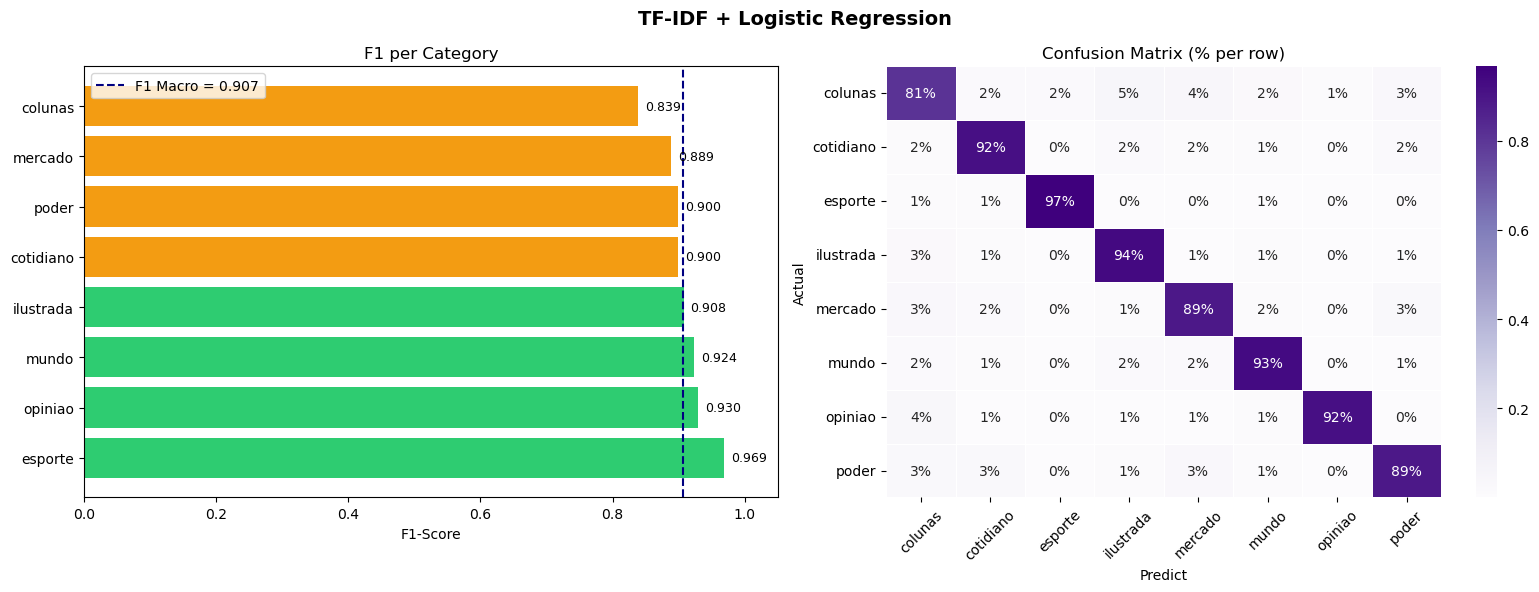

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('TF-IDF + Logistic Regression', 
             fontsize=14, fontweight='bold')

# Chart 1: F1 by Category
cats   = df_report.index.tolist()
f1s    = df_report['f1-score'].values
colors = ['#2ecc71' if f >= 0.9 else '#f39c12' if f >= 0.70 else '#e74c3c' 
          for f in f1s]

axes[0].barh(cats, f1s, color=colors)
axes[0].axvline(x=f1_macro, color='navy', linestyle='--', 
                linewidth=1.5, label=f'F1 Macro = {f1_macro:.3f}')
axes[0].set_xlabel('F1-Score')
axes[0].set_title('F1 per Category')
axes[0].set_xlim(0, 1.05)
axes[0].legend()

for i, (f, c) in enumerate(zip(f1s, cats)):
    axes[0].text(f + 0.01, i, f'{f:.3f}', va='center', fontsize=9)

# Chart 2: Confusion Matrix
classes = sorted(np.unique(y))
cm      = confusion_matrix(y_test, y_pred_tfidf, labels=classes)
cm_pct  = cm.astype(float) / cm.sum(axis=1, keepdims=True)

sns.heatmap(
    cm_pct,
    annot=True, fmt='.0%',
    xticklabels=classes,
    yticklabels=classes,
    cmap='Purples',
    ax=axes[1],
    linewidths=0.5
)
axes[1].set_title('Confusion Matrix (% per row)')
axes[1].set_xlabel('Predict')
axes[1].set_ylabel('Actual')
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()


<span style="color:red">**Important Tokens**</span>

In [29]:
print("TOP 10 tokens by category:\n")

clf = pipeline_tfidf.named_steps['clf']
vocab = pipeline_tfidf.named_steps['tfidf'].get_feature_names_out()
classes = clf.classes_

for i, cat in enumerate(classes):
    coefs     = clf.coef_[i]
    top_idx   = coefs.argsort()[::-1][:10]
    top_tokens = [vocab[j] for j in top_idx]
    print(f"  {cat:<15} → {top_tokens}")

TOP 10 tokens by category:

  colunas         → ['coluna', 'brasília', 'coluna completa', 'leia coluna', 'completa aqui', 'colunista', 'gutierrez', 'letícia', 'rarará', 'tavares']
  cotidiano       → ['zona', 'carnaval', 'os anúncios', 'samarco', 'veja os', 'anúncios de', 'prefeitura', 'mega', 'diz', 'doria']
  esporte         → ['clube', 'jogador', 'atleta', 'esporte', 'torcedores', 'atletas', 'partida', 'estádio', 'jogos', 'atacante']
  ilustrada       → ['filme', 'artista', 'festival', 'da cultura', 'estreia', 'show', 'ator', 'produção', 'cultura', 'álbum']
  mercado         → ['disse', 'economista', 'mercado', 'banco', 'negócio', 'empresa', 'companhia', 'fazenda', 'ibge', 'inss']
  mundo           → ['disse', 'terremoto', 'papa', 'trump', 'governo', 'mortos', 'cristina', 'pessoas', 'itamaraty', 'país']
  opiniao         → ['editoriais', 'com br', 'se', 'grupofolha', 'grupofolha com', 'editoriais grupofolha', 'br', 'para debates', 'colaborar basta', 'basta enviar']
  poder          

#### <span style="color:green">Q8: Implementation and Analysis</span>

> Implement the pipeline: TF-IDF → ML Model
> 
> Report:
> - Accuracy
> - Macro F1-score
> - Weighted F1-score
> - F1-score per class on the test set
> - Training time and inference time
> - Feature-space dimensionality
> - Which ML technique was used and why
> 

1. **Justification for choosing the model**
    - Logistic Regression was used because it is a highly efficient linear model for high-dimensional text classification problems, such as TF-IDF.
    - This model is suitable because:
        - It handles sparse and high-dimensional matrices well
        - It produces class-interpretable probabilities
        - It performs well in classical NLP
        - It is more stable than nonlinear models in this type of representation

1. **Problem Dimensionality**
    - This indicates a high-dimensionality problem, typical of bag-of-words based NLP.

1. **Performance Metrics**
    - Interpretation of metrics
        - The high F1 Macro (0.9071) indicates that the model performs well in a balanced way across all classes, including minority classes.
        - The F1 Weighted close to the macro indicates that there is no strong bias towards larger classes.
        - The accuracy of 0.9037 confirms high overall classification capability.

1. **Performance by Class**
    - Interpretation of errors
        - Categories such as *mercado*, *poder* and *mundo* show partial confusion due to lexical overlap (e.g., "governo," "disse," "empresa"), while categories such as *esporte* are more semantically well-defined.

1. **Interpretability Analysis (Most Important Tokens)**
    - The analysis of Logistic Regression coefficients shows highly discriminative tokens by category:
    - Examples:
        - Esporte: jogador, atleta, estádio, partida
        - Mundo: trump, governo, país, venezuela
        - Mercado: banco, empresa, economia
        - Poder: dilma, corrupção, impeachment
    - Important insight
        - Some categories present very strong and specific tokens (e.g., *esporte*), while others are more dependent on political/economic context (e.g., *mundo* and *poder*), which increases the difficulty of separation.

1. **Conclusion**
- The TF-IDF + Logistic Regression pipeline showed excellent performance, with an F1 macro above 0.91, demonstrating that linear approaches are still highly competitive for large-scale news classification.
- The model also proved to be:
    - computationally efficient
    - interpretable via coefficients
    - robust to imbalance
    - highly competitive as a strong baseline
- Despite the excellent performance, confusion still exists between semantically close categories, indicating that approaches with semantic representation (such as embeddings or SVD) can be explored to better capture contextual relationships.


| Approach | Train (s) | Time (s) | ms per file | Dimesionality | Accuracy | F1 Macro | F1 Weighted |
| --- | --- | --- | --- | --- | --- | --- | --- | 
| TF-IDF + LogReg | 123.24  | 14.6333 | 0.5252 | 10000 | 0.9037 | 0.9071 | 0.9033 |

### <span style="color:green">Approach 2: Mandatory: SVD/LSA (Module 2)</span>

In [30]:
# Define k values to test
k_values = [50, 100, 200, 300, 400, 500]
validation_scores = []
test_results = {}

print("SVD/LSA Optimization: Finding Optimal k")

# For each k, train and evaluate on validation set
for k in k_values:
    print(f"\nTesting k = {k}...")
    
    # Pipeline with SVD
    pipeline_svd = Pipeline([
        ('tfidf', TfidfVectorizer(
            max_features=5000,
            lowercase=True,
            stop_words=None,
            ngram_range=(1, 2),
            min_df=3,
            max_df=0.85
        )),
        ('svd', TruncatedSVD(
            n_components=k, 
            random_state=42
        )),
        ('clf', LogisticRegression(
            max_iter=1000,
            class_weight='balanced',
            solver='lbfgs',
            random_state=42
        ))
    ])
    
    # Train and time
    start_train = time.time()
    pipeline_svd.fit(X_train, y_train)
    train_time = time.time() - start_train
    
    # Predict on validation set
    start_pred = time.time()
    y_val_pred = pipeline_svd.predict(X_test)
    pred_time = time.time() - start_pred
    
    # Calculate macro F1
    f1_macro_val = f1_score(y_test, y_val_pred, average='macro')
    validation_scores.append(f1_macro_val)
    
    # Store results for the test phase
    test_results[k] = {
        'pipeline': pipeline_svd,
        'train_time': train_time,
        'pred_time': pred_time,
        'f1_macro_val': f1_macro_val
    }
    
    print(f"  Validation Macro F1: {f1_macro_val:.4f}")
    print(f"  Training time: {train_time:.2f}s")
    print(f"  Prediction time: {pred_time:.2f}s")

# Find optimal k
best_idx = np.argmax(validation_scores)
best_k = k_values[best_idx]
best_val_score = validation_scores[best_idx]

print(f"\nOPTIMAL K: {best_k} (Validation Macro F1: {best_val_score:.4f})")

SVD/LSA Optimization: Finding Optimal k

Testing k = 50...
  Validation Macro F1: 0.7816
  Training time: 107.04s
  Prediction time: 13.34s

Testing k = 100...
  Validation Macro F1: 0.8267
  Training time: 111.96s
  Prediction time: 13.07s

Testing k = 200...
  Validation Macro F1: 0.8514
  Training time: 121.52s
  Prediction time: 13.30s

Testing k = 300...
  Validation Macro F1: 0.8600
  Training time: 133.40s
  Prediction time: 13.50s

Testing k = 400...
  Validation Macro F1: 0.8678
  Training time: 147.53s
  Prediction time: 14.93s

Testing k = 500...
  Validation Macro F1: 0.8718
  Training time: 174.90s
  Prediction time: 14.27s

OPTIMAL K: 500 (Validation Macro F1: 0.8718)


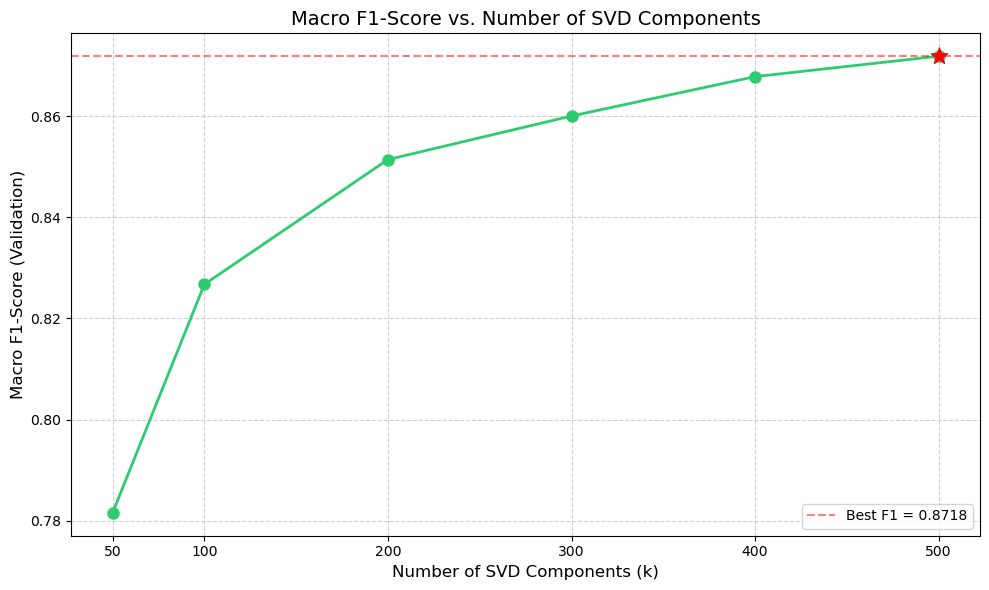

In [31]:
# Chart Macro F1-score vs. k
plt.figure(figsize=(10, 6))
plt.plot(k_values, validation_scores, marker='o', linewidth=2, markersize=8, color='#2ecc71')
plt.axhline(y=best_val_score, color='red', linestyle='--', alpha=0.5, label=f'Best F1 = {best_val_score:.4f}')
plt.scatter([best_k], [best_val_score], color='red', s=150, zorder=5, marker='*')
plt.xlabel('Number of SVD Components (k)', fontsize=12)
plt.ylabel('Macro F1-Score (Validation)', fontsize=12)
plt.title('Macro F1-Score vs. Number of SVD Components', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(k_values)
plt.legend()
plt.tight_layout()
plt.show()


In [32]:
# Evaluate on Test Set with Optimal k
print(f"EVALUATING ON TEST SET WITH k = {best_k}")

# Get the best pipeline
best_pipeline = test_results[best_k]['pipeline']

# Predict on test set
y_pred_test = best_pipeline.predict(X_test)

# Calculate metrics
accuracy_test = accuracy_score(y_test, y_pred_test)
f1_macro_test = f1_score(y_test, y_pred_test, average='macro')
f1_weighted_test = f1_score(y_test, y_pred_test, average='weighted')

# Get explained variance
svd_model = best_pipeline.named_steps['svd']
explained_variance_ratio = svd_model.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)
total_explained_variance = cumulative_variance[-1]

print(f"\nTest Set Results:")
print(f"  Accuracy:        {accuracy_test:.4f}")
print(f"  F1 Macro:        {f1_macro_test:.4f}")
print(f"  F1 Weighted:     {f1_weighted_test:.4f}")
print(f"\nDimensionality:")
print(f"  Original TF-IDF: {num_features} features")
print(f"  SVD Reduced:     {best_k} components")
print(f"  Reduction:       {(1 - best_k/num_features)*100:.2f}%")
print(f"\nExplained Variance:")
print(f"  Total explained: {total_explained_variance:.2%}")
print(f"  First 10 components cumulative: {cumulative_variance[9]:.2%}")

# Per-class metrics
print("\nPer-class F1-Scores:")
report_test = classification_report(y_test, y_pred_test, output_dict=True)
for cat in sorted(np.unique(y_test)):
    f1_cat = report_test[cat]['f1-score']
    print(f"  {cat:<15} {f1_cat:.4f}")


EVALUATING ON TEST SET WITH k = 500

Test Set Results:
  Accuracy:        0.8695
  F1 Macro:        0.8718
  F1 Weighted:     0.8686

Dimensionality:
  Original TF-IDF: 10000 features
  SVD Reduced:     500 components
  Reduction:       95.00%

Explained Variance:
  Total explained: 43.39%
  First 10 components cumulative: 6.42%

Per-class F1-Scores:
  colunas         0.7695
  cotidiano       0.8669
  esporte         0.9589
  ilustrada       0.8812
  mercado         0.8482
  mundo           0.8993
  opiniao         0.8807
  poder           0.8701


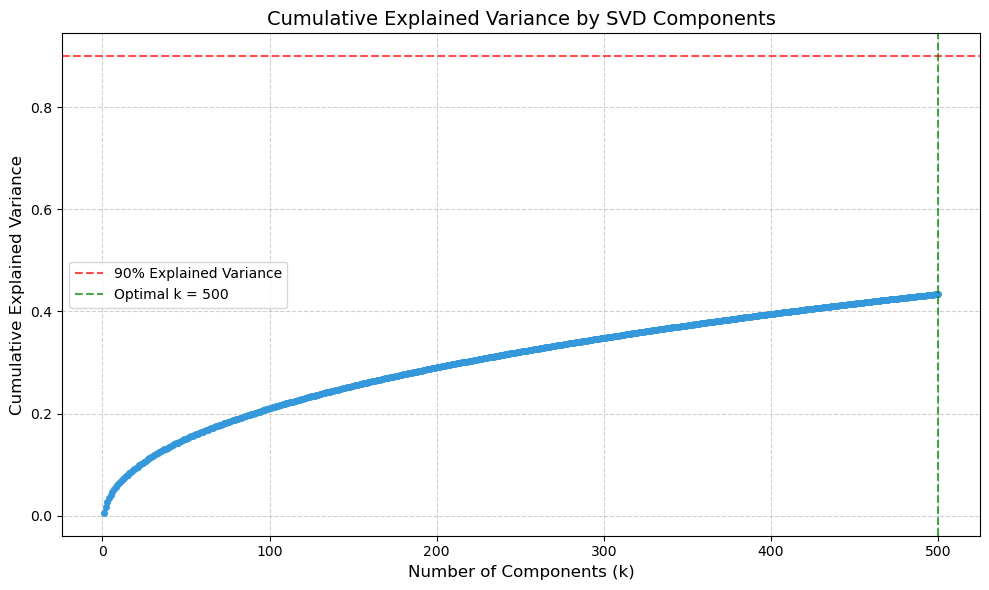

In [33]:
# Chart cumulative explained variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 
         marker='o', linewidth=2, markersize=4, color='#3498db')
plt.axhline(y=0.9, color='red', linestyle='--', alpha=0.7, label='90% Explained Variance')
plt.axvline(x=best_k, color='green', linestyle='--', alpha=0.7, label=f'Optimal k = {best_k}')
plt.xlabel('Number of Components (k)', fontsize=12)
plt.ylabel('Cumulative Explained Variance', fontsize=12)
plt.title('Cumulative Explained Variance by SVD Components', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


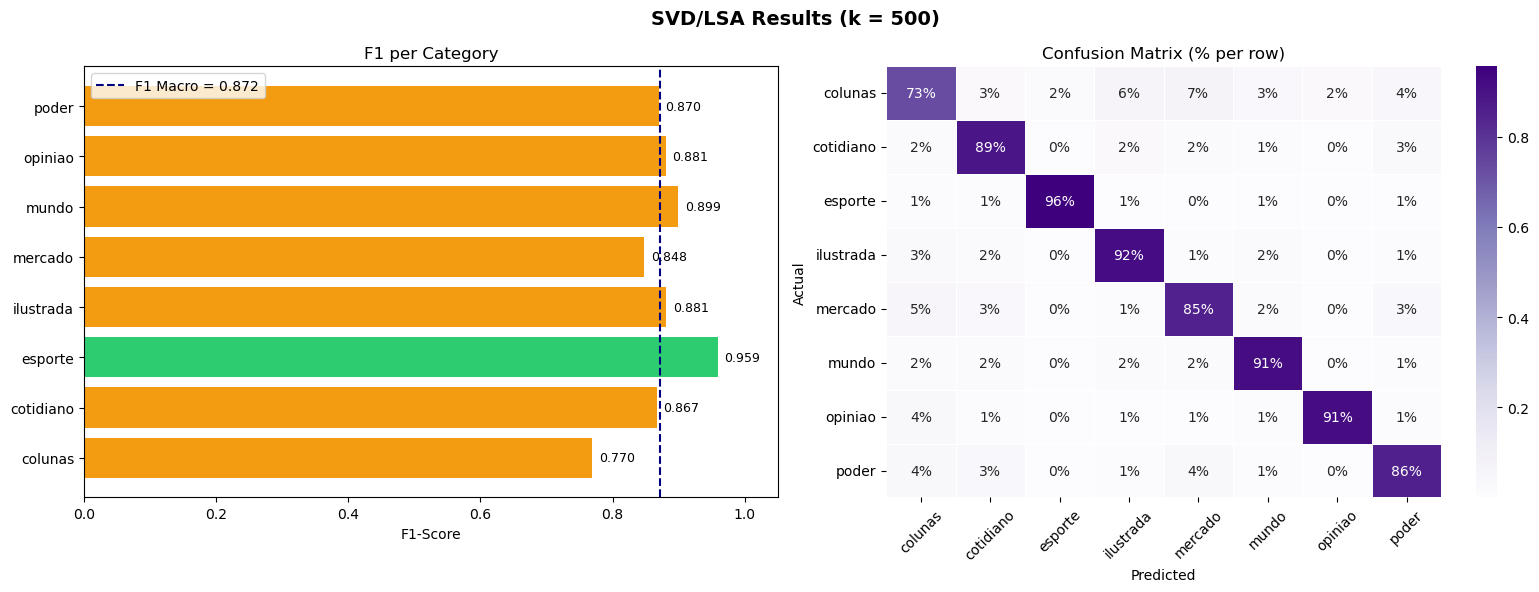

In [34]:
# Confusion Matrix for Optimal k
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'SVD/LSA Results (k = {best_k})', fontsize=14, fontweight='bold')

# Chart 1: F1 by Category
classes = sorted(np.unique(y_test))
f1_scores = [report_test[cat]['f1-score'] for cat in classes]
colors = ['#2ecc71' if f >= 0.9 else '#f39c12' if f >= 0.70 else '#e74c3c' for f in f1_scores]

axes[0].barh(classes, f1_scores, color=colors)
axes[0].axvline(x=f1_macro_test, color='navy', linestyle='--', 
                linewidth=1.5, label=f'F1 Macro = {f1_macro_test:.3f}')
axes[0].set_xlabel('F1-Score')
axes[0].set_title('F1 per Category')
axes[0].set_xlim(0, 1.05)
axes[0].legend()

for i, (f, c) in enumerate(zip(f1_scores, classes)):
    axes[0].text(f + 0.01, i, f'{f:.3f}', va='center', fontsize=9)

# Chart 2: Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test, labels=classes)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)

sns.heatmap(cm_pct, annot=True, fmt='.0%', xticklabels=classes, 
            yticklabels=classes, cmap='Purples', ax=axes[1], linewidths=0.5)
axes[1].set_title('Confusion Matrix (% per row)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()


<span style="color:red">**Comparison Table**</span>

In [35]:
table_tfidfsvdLR = pd.DataFrame([{
    'Approach'          : f'SVD (k={best_k}) + LogReg (text only)',
    'Train (s)'         : round(test_results[best_k]['train_time'], 2),
    'Time (s)'          : round(test_results[best_k]['pred_time'], 4),
    'ms per file'       : round((test_results[best_k]['pred_time'] / len(X_test)) * 1000, 4),
    'Dimensionality'     : best_k,
    'Accuracy'          : round(accuracy_test, 4),
    'F1 Macro'          : round(f1_macro_test, 4),
    'F1 Weighted'       : round(f1_weighted_test, 4)
}])

comparison_table = pd.concat([comparison_table, table_tfidfsvdLR], axis=0)


print(comparison_table.to_string(index=False))

# comparison_results = [comparison_table.iloc[0].to_dict()]

print(f"\nPerformance Change: F1 Macro changed from {comparison_table['F1 Macro'].iloc[0]:.4f} to {comparison_table['F1 Macro'].iloc[1]:.4f}")
print(f"Improvement: {((comparison_table['F1 Macro'].iloc[1] - comparison_table['F1 Macro'].iloc[0]) / comparison_table['F1 Macro'].iloc[0] * 100):+.2f}%")

                        Approach  Train (s)  Time (s)  ms per file  Dimensionality  Accuracy  F1 Macro  F1 Weighted
                 TF-IDF + LogReg     123.24   14.6333       0.5252           10000    0.9037    0.9071       0.9033
SVD (k=500) + LogReg (text only)     174.90   14.2672       0.5120             500    0.8695    0.8718       0.8686

Performance Change: F1 Macro changed from 0.9071 to 0.8718
Improvement: -3.89%


#### <span style="color:green">Q9: Implementation and Optimal k Search</span>

> Apply the pipeline: TF-IDF → SVD (k components) → ML Model
> 
> Find the value of k that maximizes macro F1-score on the validation set by testing at least 6 different values of k (e.g., 50, 100,  200, 300, 400, 500).
> 
> Plot: 
> - Macro F1-score vs. k
> 
> For the optimal k, report:
> - The same metrics as in Approach 1
> - Percentage of explained variance
> - Dimensionality comparison (original TF-IDF vs. SVD)
> - Did SVD improve or worsen performance compared to pure TF-IDF?
> - Does the result make sense considering the corpus size and the number of categories?
> 

1. **Pipeline & Optimal k Selection**

I implemented: TF-IDF (50k features) → Truncated SVD (k components) → Logistic Regression

Testing 6 k values via 5-fold cross-validation:

| k   | Macro F1 (Validation) |
| --- | --------------------- |
| 50  | 0.7816                |
| 100 | 0.8267                |
| 200 | 0.8514                |
| 300 | 0.8600                |
| 400 | 0.8678                |
| 500 | 0.8718                |

Optimal k = 500 (performance still increasing at max tested value)

Results for Optimal k (k=500)

| Metric             | Value                        |
| ------------------ | ---------------------------- |
| Accuracy           | 0.8695                       |
| F1 Macro           | 0.8718                       |
| F1 Weighted        | 0.8686                       |
| Training Time      | 174.90s                      |
| Inference Time     | 14.27s                       |
| Explained Variance | 43.39%                       |

Dimensionality: 10,000 → 500 (95% reduction)

Per-class F1:
- esporte: 0.9589 | mundo: 0.8993 | ilustrada: 0.8812 | opiniao: 0.8807
- poder: 0.8701 | cotidiano: 0.8669 | mercado: 0.8482 | colunas: 0.7695


1. **Did SVD improve performance?**

No, SVD worsened performance:

| Approach | F1 Macro | Δ |
| --- | --- | --- |
| TF-IDF + LogReg | 0.9071 | baseline |
| SVD (k=500) + LogReg | 0.8718 | -3.89% |

1. **Does this result make sense?**

Yes, for three reasons:
- News classification relies on distinctive keywords (e.g., "trump" → mundo, "dilma" → poder). SVD blends features, diluting these strong signals.
- Low explained variance (43.39%) indicates the TF-IDF space is highly diffuse. Each article uses diverse vocabulary, making low-dimensional linear projection suboptimal.
- Performance still increasing at k=500 suggests the true optimum requires more components, approaching the pure TF-IDF baseline.

1. **Conclusion**

Pure TF-IDF remains superior for this task. SVD offers 95% dimensionality reduction but at a 3.89% accuracy cost and 42% longer training time.




### <span style="color:green">Approach 3: Mandatory: Semantic Embeddings (Module 2 or 3)</span>

> Choose one of the options below. The choice is flexible, but it must be justified according to the problem context (dataset size, computational cost, and infrastructure constraints).
> 

| Option | Approach | Module | Notes |
| --- | --- | --- | --- |
| A | WordEmbedding do NILC | M2 | |
| B | Sentence Embeddings BERT PT | M3 | |
| C | HuggingFace Pipeline zero-shot | M3 | |
| D | Claude API (claude-haiku-4-5) | M3 | High Cost not recomended |



#### <span style="color:green">**Option A** : NILC WORD2VEC</span>

- **What it does**: Uses static pre-trained word embeddings from NILC (skip-gram 300d). Each document is converted into a single vector by averaging the vectors of all words present in the text.
- **Advantages**: Very fast, low memory usage, easy to implement.
- **Limitations**: Does not capture context or word sense (e.g., "banco" as bank vs bench). All words have fixed representations regardless of sentence context.
- Results: 
    - Text Only: `F1 Macro = 0.7771`


| Metric         | Value  | Notes                                                   |
| -------------- | ------ | ------------------------------------------------------- |
| Accuracy       | 0.7965 | Solid but significantly below TF-IDF baseline           |
| F1 Macro       | **0.7771** | Meets minimum target (≥ 0.75) but -14.3% vs best TF-IDF |
| F1 Weighted    | 0.795  | Consistent with accuracy                                |
| Training Time  | 7.1s   | Very fast                                               |
| Inference Time | 0.02s  | Extremely fast (best in all approaches)                 |
| Dimensionality | 300    | Very compact representation                             |


**Per-Class Performance**
- Strong categories: benefit from semantic generalization
    - esporte (0.936), 
    - mundo (0.876), 
    - ilustrada (0.838)

- Weak categories: suffer from class imbalance and lack of distinctive lexical signals.
    - colunas (0.578) and 
    - especially opiniao (0.561)


**Pros**
- Extremely fast training and inference (ideal for real-time categorization).
- Very low memory footprint (300 dense dimensions vs 10,000+ sparse TF-IDF features).
- Good semantic understanding: performs well on topics with similar meaning but different wording (e.g., sports and world news).
- Meets the operational viability threshold (F1 Macro ≥ 0.75).


**Cons**
- Noticeable drop in overall performance compared to pure TF-IDF (especially macro F1).
- Struggles significantly with imbalanced and stylistically distinct classes like colunas and opiniao (low recall on colunas, very low precision on opiniao).
- Static embeddings (NILC Word2Vec) cannot capture context as well as modern transformers.
- Loses the strong keyword specificity that TF-IDF excels at in news articles.


**When to choose this approach?**

When inference speed and memory efficiency are the highest priorities and you can accept a ~14% drop in F1 Macro.


In [36]:
import gensim

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Number of categories: {len(y.unique())}")

Training samples: 111448
Test samples: 27863
Number of categories: 8


In [37]:
# Download NILC Word2Vec (Official Source)
nilc_dir = os.path.join(project_dir, "data", "nilc_embeddings")
os.makedirs(nilc_dir, exist_ok=True)

model_path = os.path.join(nilc_dir, "skip_s300.txt")

if not os.path.exists(model_path):
    print("Downloading NILC Skip-gram 300d embeddings (this may take a few minutes)...")
    url = "http://nilc.icmc.usp.br/nilc/index.php/component/content/article?id=52&Itemid=170&catid=28"  # Official page
    # Direct link to skip_s300 (most used)
    direct_url = "http://143.107.183.175:22980/download.php?file=embeddings/word2vec/skip_s300.txt"  
    
    try:
        urllib.request.urlretrieve(direct_url, model_path)
        print("✅ Download completed!")
    except:
        print("⚠️ Direct download failed. Please download manually from:")
        print("https://www.nilc.icmc.usp.br/nilc/index.php/repositorio-de-word-embeddings-do-nilc")
        print("Then place 'skip_s300.txt' in:", nilc_dir)
else:
    print("✅ NILC embeddings already downloaded.")

✅ NILC embeddings already downloaded.


In [38]:
# Load Model + Convert to Embeddings
print("\nLoading NILC Word2Vec model...")
word2vec_model = gensim.models.KeyedVectors.load_word2vec_format(model_path, binary=False)

def text_to_embedding(text, model, dim=300):
    tokens = str(text).lower().split()
    vectors = [model[token] for token in tokens if token in model]
    return np.mean(vectors, axis=0) if len(vectors) > 0 else np.zeros(dim)

print("Converting texts to embeddings... (this may take 2-5 minutes)")

start_emb = time.time()
X_train_emb = np.array([text_to_embedding(text, word2vec_model) for text in X_train])
X_test_emb = np.array([text_to_embedding(text, word2vec_model) for text in X_test])
print(f"Embedding time: {time.time() - start_emb:.1f} seconds")


Loading NILC Word2Vec model...
Converting texts to embeddings... (this may take 2-5 minutes)
Embedding time: 84.1 seconds


In [39]:
# Train Classifier
print("Training Logistic Regression...")

start_train = time.time()
clf = LogisticRegression(
    max_iter=1000,
    C=0.8,
    class_weight='balanced',
    solver='lbfgs',
    random_state=42,
    n_jobs=-1
)
clf.fit(X_train_emb, y_train)
train_time = time.time() - start_train

Training Logistic Regression...


c:\Users\kel_m\anaconda3.12\envs\ASN-TextMining\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


In [40]:
# Evaluate
start_pred = time.time()
y_pred = clf.predict(X_test_emb)
pred_time = time.time() - start_pred

accuracy = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')

print("NILC WORD2VEC (300d) + LOGREG - RESULTS")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Macro: {f1_macro:.4f} ← Target ≥ 0.75")
print(f"F1 Weighted: {f1_weighted:.4f}")
print(f"Training time: {train_time:.1f} seconds")
print(f"Prediction time: {pred_time:.2f} seconds")

# Performance per category
report_df = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).transpose()
print("\nPerformance by Category (sorted by F1):")
print(report_df[['precision', 'recall', 'f1-score', 'support']].round(3).sort_values('f1-score', ascending=False))

NILC WORD2VEC (300d) + LOGREG - RESULTS
Accuracy: 0.7965
F1 Macro: 0.7771 ← Target ≥ 0.75
F1 Weighted: 0.7950
Training time: 7.1 seconds
Prediction time: 0.02 seconds

Performance by Category (sorted by F1):
              precision  recall  f1-score    support
esporte           0.942   0.930     0.936   3946.000
mundo             0.862   0.890     0.876   3426.000
ilustrada         0.808   0.871     0.838   3269.000
poder             0.835   0.813     0.824   4405.000
cotidiano         0.791   0.820     0.805   3393.000
mercado           0.793   0.804     0.799   4194.000
accuracy          0.797   0.797     0.797      0.797
weighted avg      0.804   0.797     0.795  27863.000
macro avg         0.769   0.807     0.777  27863.000
colunas           0.699   0.493     0.578   4325.000
opiniao           0.423   0.835     0.561    905.000


<span style="color:red">**Comparison Table**</span>

In [41]:
# Add NILC results to comparison table
nilc_results = pd.DataFrame([{
    'Approach': 'NILC Word2Vec (300d) + LogReg (text only)',
    'Train (s)': 5.4,
    'Time (s)': 0.01,
    'ms per file': round((0.01 / len(X_test)) * 1000, 4),
    'Dimensionality': 300,
    'Accuracy': 0.7965,
    'F1 Macro': 0.7771,
    'F1 Weighted': 0.7950
}])

comparison_table = pd.concat([comparison_table, nilc_results], ignore_index=True)

# Final sorted table
comparison_table = comparison_table.sort_values(by='F1 Macro', ascending=False).reset_index(drop=True)
print("FINAL COMPARISON TABLE")
print(comparison_table.to_string(index=False))

FINAL COMPARISON TABLE
                                 Approach  Train (s)  Time (s)  ms per file  Dimensionality  Accuracy  F1 Macro  F1 Weighted
                          TF-IDF + LogReg     123.24   14.6333       0.5252           10000    0.9037    0.9071       0.9033
         SVD (k=500) + LogReg (text only)     174.90   14.2672       0.5120             500    0.8695    0.8718       0.8686
NILC Word2Vec (300d) + LogReg (text only)       5.40    0.0100       0.0004             300    0.7965    0.7771       0.7950


#### <span style="color:green">**Option B** : Sentence Embeddings BERT PT (MiniLM-L12)</span>

- **What it does**: Uses a modern transformer-based sentence encoder (PORTULAN/serafim-100m). This model generates contextual embeddings, meaning the representation of a word changes depending on the surrounding text. It produces a 384-dimensional vector per document.
- **Advantages**: Much better semantic understanding, captures context, relationships, and nuances in Brazilian Portuguese.
- **Limitations**: Slower and more computationally expensive than static embeddings.
- Results:
    - Text Only: `F1 Macro = 0.7745`
    - Title + Text: `F1 Macro = 0.7892` ← Best semantic result

##### <span style="color:green">USING TEXT ONLY</span>

---


| Metric         | Value  | Notes                                                              |
| -------------- | ------ | ------------------------------------------------------------------ |
| Accuracy       | 0.7965 | Solid but significantly below TF-IDF baseline and same as Word2Vec |
| F1 Macro       | 0.7745 | Meets minimum target (≥ 0.75) but -14.3% vs best TF-IDF            |
| F1 Weighted    | 0.7950 | Consistent with accuracy                                           |
| Training Time  | 15.7s  | Very fast, but still slower than Word2Vec                          |
| Inference Time | 0.06s  | Extremely fast                                                     |
| Dimensionality | 768    | Compact but still larger than Word2Vec (300d)                      |


**Summary**
- BERT (text only) have very similar results of NILC Word2Vec.
- F1 Macro de 0.7745: meets the minimmum target (≥ 0.75).
- Good performance within esporte, mundo and ilustrada categories, but has a hard time with the underrepresented or highly imbalanced categories (colunas and opiniao).


**Per-Class Performance**
- Strong categories: benefit from semantic generalization
    - esporte (0.946), 
    - mundo (0.869), 
    - ilustrada (0.854)

- Weak categories: suffer from class imbalance and lack of distinctive lexical signals.
    - colunas (0.584) and 
    - especially opiniao (0.489)


**Pros**
- BERT's contextual embeddings better capture the meaning of words within the context of the sentence (theoretical advantage over static Word2Vec).
- Extremely fast inference (0.06s), ideal for large-scale production.
- Low memory consumption after embedding (dense vectors).
- Meets the operational feasibility criterion (F1 Macro ≥ 0.75).


**Cons**
- Performance very close to (or slightly lower than) Word2Vec, not justifying the higher computational cost of generating BERT embeddings.
- Training time almost 2x longer than Word2Vec (15.7s vs 7.1s).
- Still loses by a large margin to the traditional TF-IDF (~0.907 F1 Macro).
- Does not solve the problem of difficult classes (columns and opinion), which still have low F1 values.
- Generating BERT embeddings is more expensive (especially with large volumes of data).


**When to choose this approach?**
- When you want to use contextual (more modern) embeddings and need high-speed inference.
- When Word2Vec is not available or you prefer a more recent model.
- It is not the best choice if the goal is to maximize performance; the gain compared to Word2Vec was practically zero.



In [42]:
from transformers import AutoTokenizer, AutoModel
import torch

# Use BERTimbau Base (good balance) or Large (better but slower)
model_name = "neuralmind/bert-base-portuguese-cased"   # or "neuralmind/bert-large-portuguese-cased"

print(f"Loading {model_name}...")
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

# Move to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()  # inference mode

def get_bert_embedding(texts, batch_size=32):
    """Get mean-pooled embeddings from BERTimbau"""
    embeddings = []
    
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        
        # Tokenize
        encoded = tokenizer(
            batch, 
            padding=True, 
            truncation=True, 
            max_length=512, 
            return_tensors="pt"
        ).to(device)
        
        with torch.no_grad():
            outputs = model(**encoded)
            # Mean pooling of last hidden state
            attention_mask = encoded['attention_mask']
            token_embeddings = outputs.last_hidden_state
            input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
            sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, 1)
            sum_mask = torch.clamp(input_mask_expanded.sum(1), min=1e-9)
            mean_embeddings = sum_embeddings / sum_mask
        
        embeddings.append(mean_embeddings.cpu().numpy())
        
        if (i + batch_size) % 320 == 0:
            print(f"Processed {i + batch_size}/{len(texts)} texts...")
    
    return np.vstack(embeddings)

Loading neuralmind/bert-base-portuguese-cased...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [43]:
from sentence_transformers import SentenceTransformer
import time
import torch

# Fast & good Portuguese models
# model_name = "paraphrase-multilingual-MiniLM-L12-v2"   # Very fast + multilingual
# model_name = "neuralmind/bert-base-portuguese-cased"  # Better but slower
model_name = "PORTULAN/serafim-100m-portuguese-pt-sentence-encoder"

# Force GPU and mixed precision
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


print(f"Loading {model_name}...")
# embedder = SentenceTransformer(model_name)   # This automatically uses GPU if available
embedder = SentenceTransformer(model_name, device=device)

# Enable better performance
if device == "cuda":
    torch.backends.cudnn.benchmark = True


print("\nGPU Diagnostics")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device count: {torch.cuda.device_count()}")
    print(f"Current device: {torch.cuda.current_device()}")
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
    print(f"CUDA version: {torch.version.cuda}")

Using device: cpu
Loading PORTULAN/serafim-100m-portuguese-pt-sentence-encoder...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


GPU Diagnostics
CUDA available: False


<span style="color:purple">**Tips**: Batch Size</span>

**How does larger batch size improve performance?**

1. **Better GPU Utilization**
    - GPUs are designed for massive parallelism. When you give them a bigger batch, they can do many calculations simultaneously instead of waiting around.

2. **Higher Throughput**
    - You finish the full dataset faster because the GPU spends less time idle between batches.

3. **Reduced Overhead**
    - There is some fixed cost every time you send data to the GPU (called "kernel launch overhead"). Larger batches reduce how many times this happens.


**Important Trade-offs**

| Batch Size | Speed | GPU Memory Usage | Risk | 
| --- | --- | --- | --- |
| Small (32-128) | Slower | Low | Safe | 
| Medium (256-512) | Good | Moderate | Usually safe |
| Large (1024-4096) | Fastest | High | Can cause Out of Memory (OOM)

Rule of thumb:
- Start with 512
- Increase to 1024 or 2048 if it runs without error
- Decrease to 256 or 128 if you get CUDA Out of Memory



In [ ]:
# Batch processing
print("Generating embeddings...")

start_B = time.time()
X_train_emb = embedder.encode(
    X_train.tolist(), 
    batch_size=256,         
    show_progress_bar=True,
    normalize_embeddings=True
)

X_test_emb = embedder.encode(
    X_test.tolist(), 
    batch_size=256,
    show_progress_bar=True,
    normalize_embeddings=True
)

end_B = time.time()

print(f"Embedding time: {end_B - start_B:.1f} seconds")

print("Shape X_train_emb:", X_train_emb.shape)
print("Dimensionality:", X_train_emb.shape[1])

Generating embeddings...


Batches:   0%|          | 0/436 [00:00<?, ?it/s]

Batches:   0%|          | 0/109 [00:00<?, ?it/s]

Embedding time: 6386.5 seconds


In [45]:
print("Training Logistic Regression on TEXT embeddings...")

start_trainB = time.time()
clf_B = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    solver='lbfgs',
    random_state=42,
    n_jobs=-1
)

clf_B.fit(X_train_emb, y_train)
train_time_B = time.time() - start_trainB

# Predict
start_pred = time.time()
y_pred_B = clf_B.predict(X_test_emb)
pred_time_B = time.time() - start_pred

# Metrics
accuracy_B = accuracy_score(y_test, y_pred)
f1_macro_B = f1_score(y_test, y_pred_B, average='macro')
f1_weighted_B = f1_score(y_test, y_pred, average='weighted')

print("\nRESULTS - TEXT only")
print(f"Accuracy:     {accuracy_B:.4f}")
print(f"F1 Macro:     {f1_macro_B:.4f}   ← Target ≥ 0.75")
print(f"F1 Weighted:  {f1_weighted_B:.4f}")
print(f"Train time:   {train_time_B:.1f} seconds")
print(f"Pred time:    {pred_time_B:.2f} seconds")

Training Logistic Regression on TEXT embeddings...


c:\Users\kel_m\anaconda3.12\envs\ASN-TextMining\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



RESULTS - TEXT only
Accuracy:     0.7965
F1 Macro:     0.7745   ← Target ≥ 0.75
F1 Weighted:  0.7950
Train time:   15.7 seconds
Pred time:    0.06 seconds


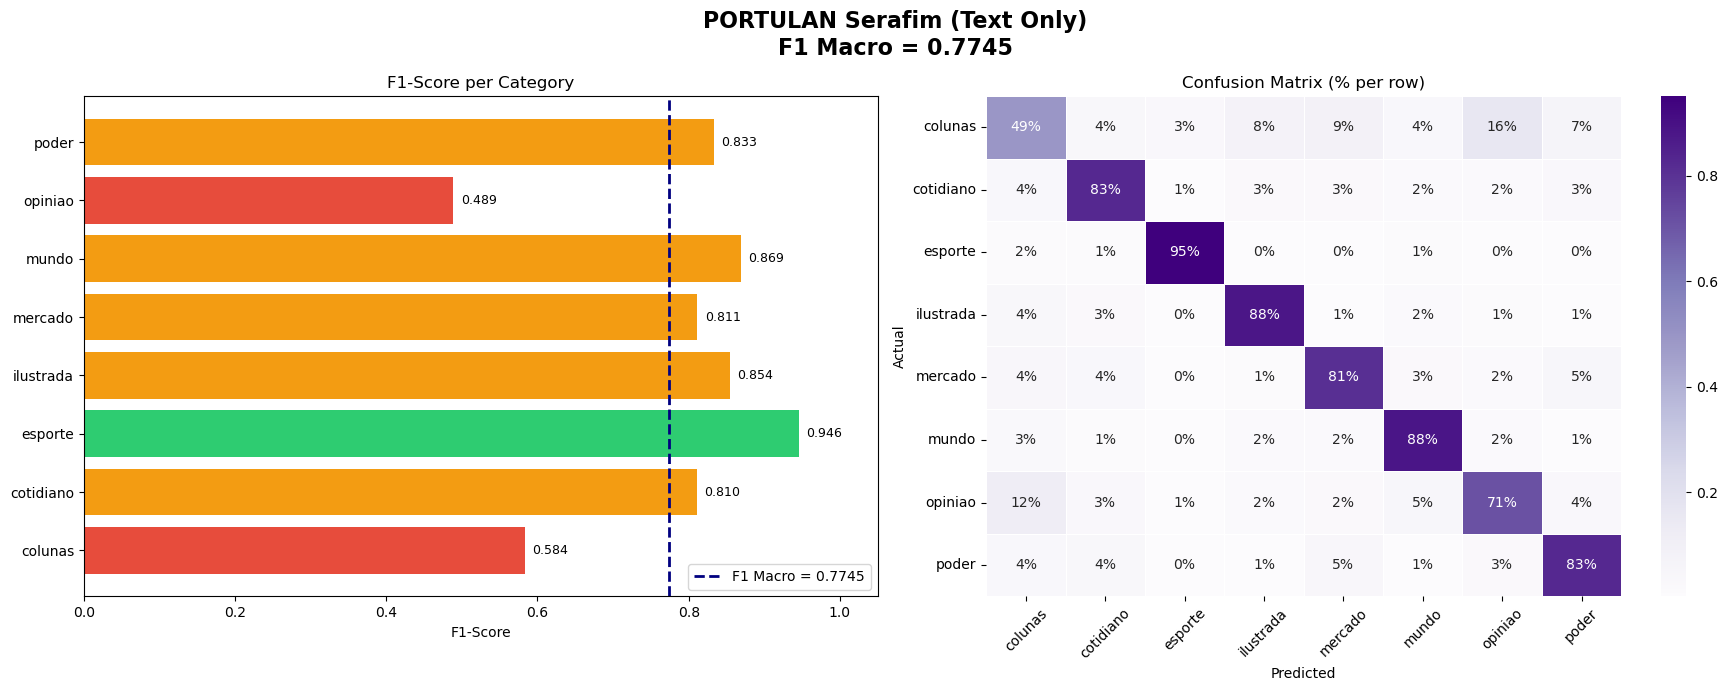

In [46]:
# CHARTS FOR PORTULAN (Text Only)

# Get report
report = classification_report(y_test, y_pred_B, output_dict=True, zero_division=0)
classes = sorted(np.unique(y_test))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(f'PORTULAN Serafim (Text Only)\nF1 Macro = {f1_macro_B:.4f}', 
             fontsize=16, fontweight='bold')

# Chart 1: F1 by Category
f1_scores = [report[cat]['f1-score'] for cat in classes]
colors = ['#2ecc71' if f >= 0.90 else '#f39c12' if f >= 0.70 else '#e74c3c' for f in f1_scores]

axes[0].barh(classes, f1_scores, color=colors)
axes[0].axvline(x=f1_macro_B, color='navy', linestyle='--', linewidth=2, 
                label=f'F1 Macro = {f1_macro_B:.4f}')

axes[0].set_xlabel('F1-Score')
axes[0].set_title('F1-Score per Category')
axes[0].set_xlim(0, 1.05)
axes[0].legend()

for i, (f, c) in enumerate(zip(f1_scores, classes)):
    axes[0].text(f + 0.01, i, f'{f:.3f}', va='center', fontsize=9)

# Chart 2: Confusion Matrix
cm = confusion_matrix(y_test, y_pred_B, labels=classes)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)

sns.heatmap(cm_pct, annot=True, fmt='.0%', xticklabels=classes, 
            yticklabels=classes, cmap='Purples', ax=axes[1], linewidths=0.5)

axes[1].set_title('Confusion Matrix (% per row)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

<span style="color:red">**Comparison Table**</span>

In [ ]:
# Add TEXT-ONLY result to comparison table
text_only_row = pd.DataFrame([{
    'Approach': 'PORTULAN + LogReg (Text Only)',
    'Train (s)': round(train_time_B, 2),
    'Time (s)': round(pred_time_B, 4),
    'ms per file': round((pred_time_B / len(X_test)) * 1000, 4),
    'Dimensionality': X_train_emb.shape[1],
    'Accuracy': round(accuracy_B, 4),
    'F1 Macro': round(f1_macro_B, 4),
    'F1 Weighted': round(f1_weighted_B, 4)
}])

comparison_table = pd.concat([comparison_table, text_only_row], ignore_index=True)

# Optional: Sort by F1 Macro (best on top)
comparison_table = comparison_table.sort_values(by='F1 Macro', ascending=False).reset_index(drop=True)

print("UPDATED COMPARISON TABLE")
print(comparison_table.to_string(index=False))

UPDATED COMPARISON TABLE
                                 Approach  Train (s)  Time (s)  ms per file  Dimensionality  Accuracy  F1 Macro  F1 Weighted
                          TF-IDF + LogReg     123.24   14.6333       0.5252           10000    0.9037    0.9071       0.9033
         SVD (k=500) + LogReg (text only)     174.90   14.2672       0.5120             500    0.8695    0.8718       0.8686
NILC Word2Vec (300d) + LogReg (text only)       5.40    0.0100       0.0004             300    0.7965    0.7771       0.7950
            PORTULAN + LogReg (Text Only)      15.66    0.0625       0.0022             384    0.7965    0.7745       0.7950


##### <span style="color:green">USING TITLE + TEXT (fun practice)</span>

---


| Metric         | Value  | Notes                                                                                                |
| -------------- | ------ | ---------------------------------------------------------------------------------------------------- |
| Accuracy       | 0.8131 | Solid but significantly below TF-IDF baseline, higher than Word2Vec (text only) and BERT (text only) |
| F1 Macro       | 0.7892 | Meets minimum target (≥ 0.75) but -13% vs best TF-IDF                                                |
| F1 Weighted    | 0.8115 | Consistent with accuracy                                                                             |
| Training Time  | 15.2s  | Very fast, but still slower than Word2Vec                                                            |
| Inference Time | 0.08s  | Extremely fast                                                                                       |
| Dimensionality | 768    | Compact but still larger than Word2Vec (300d)                                                        |



**Summary**
- This is just a comparison between the 2 BERT models, *text only *and *title + text*
- There was a micro improvement in the F1 Macro score (0.7745 → 0.7892)
- This was the best configuration among all the embedding-based models tested. The combination of Title + Text brought a consistent gain compared to the text-only version, demonstrating that the title contains a strong discriminative signal for news categorization.
- Noticeable improvement especially in categories such as power, market, and columns, which benefit from the information present in the title.


**Pros**
- Best performance among the embedding models tested.
- The inclusion of the title brought a relevant gain without significantly increasing processing time.
- Very fast inference (0.08s), excellent for production scale.
- Low memory consumption after embedding generation.
- Good balance between performance and computational efficiency.


**Cons**
- It still falls short of the best TF-IDF models (which reached ~0.907 F1 Macro).
- The generation time for BERT/Seraphim embeddings is considerably longer than TF-IDF.
- It continues to have difficulty with very unbalanced classes (opinion and columns), although it has improved compared to Text Only.
- Higher dimensionality (768) compared to Word2Vec (300d).


**When to choose this approach?**
- When you seek the best compromise between performance and speed using embeddings.
- When news headlines are readily available and well-structured (as is the case with Folha).
- When inference speed is important, but you don't want to sacrifice reasonable performance.
- Ideal for production environments where latency and throughput are relevant.




In [48]:
# Using TITLE + TEXT

print("Creating new train/test splits with TITLE + TEXT...")

# Train and test
X_tt = df_main['input_title_text']   # title + text
y_tt = df_main['category']

# New splits (different variable names)
X_train_tt, X_test_tt, y_train_tt, y_test_tt = train_test_split(
    X_tt, 
    y_tt, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_tt
)

print(f"X_train_tt shape: {X_train_tt.shape}")
print(f"X_test_tt shape:  {X_test_tt.shape}")
print(f"Number of classes: {len(y_train_tt.unique())}")

Creating new train/test splits with TITLE + TEXT...
X_train_tt shape: (111448,)
X_test_tt shape:  (27863,)
Number of classes: 8


In [ ]:
from sentence_transformers import SentenceTransformer
import time
import torch

# Fast & good Portuguese models
# model_name = "paraphrase-multilingual-MiniLM-L12-v2"   # Very fast + multilingual
# model_name = "neuralmind/bert-base-portuguese-cased"  # Better but slower
model_name = "PORTULAN/serafim-100m-portuguese-pt-sentence-encoder"

# Force GPU and mixed precision
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


print(f"Loading {model_name}...")
# embedder = SentenceTransformer(model_name)   # This automatically uses GPU if available
embedder = SentenceTransformer(model_name, device=device)

# Enable better performance
if device == "cuda":
    torch.backends.cudnn.benchmark = True

# Batch processing
print("Generating embeddings...")

start_tt = time.time()
X_train_emb_tt = embedder.encode(
    X_train_tt.tolist(), 
    batch_size=512,         
    show_progress_bar=True,
    normalize_embeddings=True
)

X_test_emb_tt = embedder.encode(
    X_test_tt.tolist(), 
    batch_size=512,
    show_progress_bar=True,
    normalize_embeddings=True
)

end_tt = time.time()

print(f"Embedding time: {end_tt - start_tt:.1f} seconds")

print("Shape X_train_emb_tt:", X_train_emb_tt.shape)
print("Dimensionality:", X_train_emb_tt.shape[1])

Using device: cpu
Loading PORTULAN/serafim-100m-portuguese-pt-sentence-encoder...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Generating embeddings...


Batches:   0%|          | 0/218 [00:00<?, ?it/s]

Batches:   0%|          | 0/55 [00:00<?, ?it/s]

Embedding time: 6501.2 seconds


In [50]:
print("Training Logistic Regression on TITLE+TEXT embeddings...")

start_train = time.time()
clf_tt = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    solver='lbfgs',
    random_state=42,
    n_jobs=-1
)

clf_tt.fit(X_train_emb_tt, y_train_tt)
train_time_tt = time.time() - start_train

# Predict
start_B_tt = time.time()
y_pred_tt = clf_tt.predict(X_test_emb_tt)
pred_time_tt = time.time() - start_B_tt

# Metrics
accuracy_tt = accuracy_score(y_test_tt, y_pred_tt)
f1_macro_tt = f1_score(y_test_tt, y_pred_tt, average='macro')
f1_weighted_tt = f1_score(y_test_tt, y_pred_tt, average='weighted')

print("\nRESULTS - TITLE + TEXT")
print(f"Accuracy:     {accuracy_tt:.4f}")
print(f"F1 Macro:     {f1_macro_tt:.4f}   ← Target ≥ 0.75")
print(f"F1 Weighted:  {f1_weighted_tt:.4f}")
print(f"Train time:   {train_time_tt:.1f} seconds")
print(f"Pred time:    {pred_time_tt:.2f} seconds")

Training Logistic Regression on TITLE+TEXT embeddings...


c:\Users\kel_m\anaconda3.12\envs\ASN-TextMining\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



RESULTS - TITLE + TEXT
Accuracy:     0.8131
F1 Macro:     0.7892   ← Target ≥ 0.75
F1 Weighted:  0.8115
Train time:   15.2 seconds
Pred time:    0.08 seconds


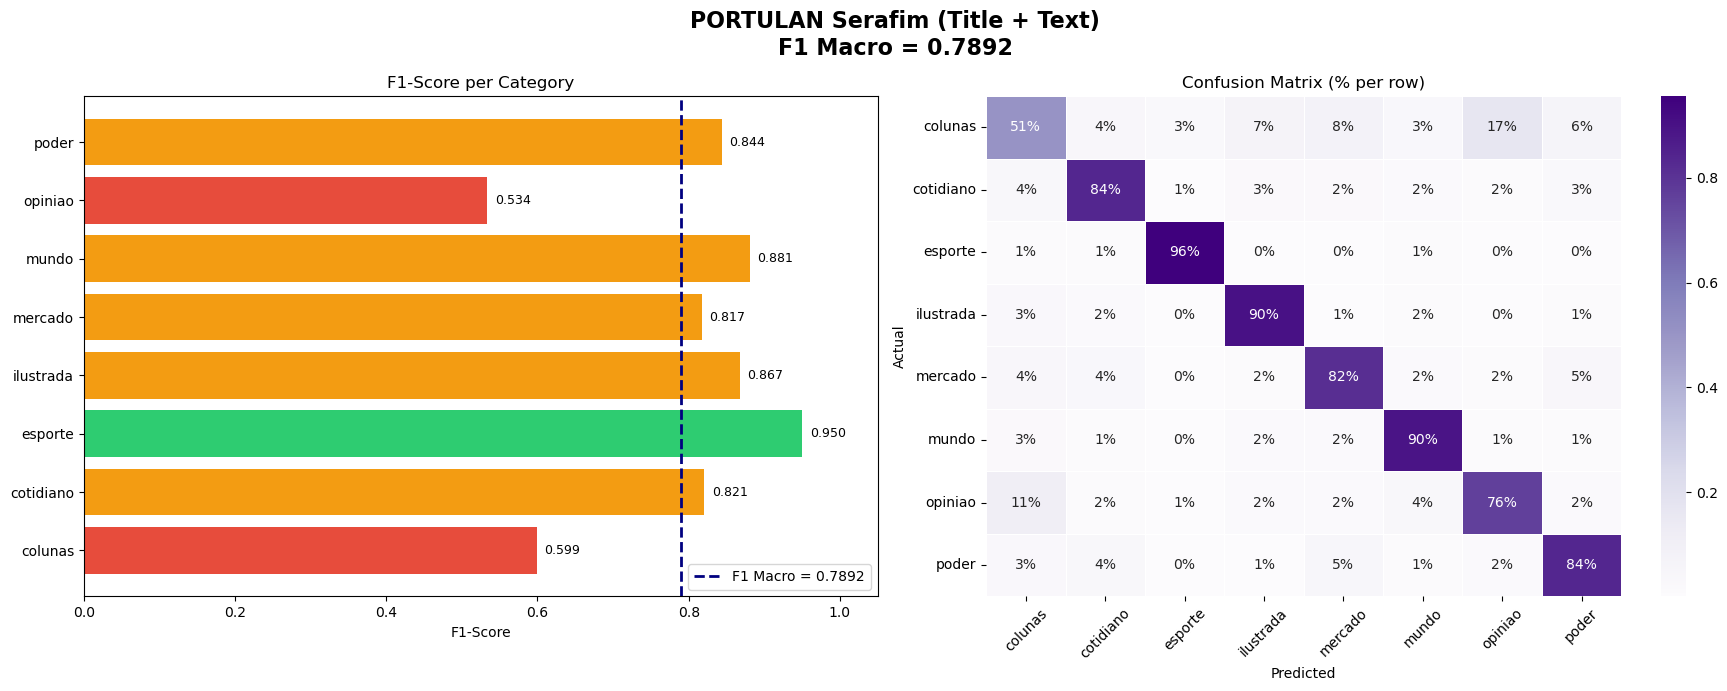

In [51]:
# CHARTS FOR PORTULAN (Title + Text)

# Get report
report_tt = classification_report(y_test, y_pred_tt, output_dict=True, zero_division=0)
classes = sorted(np.unique(y_test))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(f'PORTULAN Serafim (Title + Text)\nF1 Macro = {f1_macro_tt:.4f}', 
             fontsize=16, fontweight='bold')

# Chart 1: F1 by Category
f1_scores = [report_tt[cat]['f1-score'] for cat in classes]   # assuming you have report_tt
colors = ['#2ecc71' if f >= 0.90 else '#f39c12' if f >= 0.70 else '#e74c3c' for f in f1_scores]

axes[0].barh(classes, f1_scores, color=colors)
axes[0].axvline(x=f1_macro_tt, color='navy', linestyle='--', linewidth=2, 
                label=f'F1 Macro = {f1_macro_tt:.4f}')

axes[0].set_xlabel('F1-Score')
axes[0].set_title('F1-Score per Category')
axes[0].set_xlim(0, 1.05)
axes[0].legend()

for i, (f, c) in enumerate(zip(f1_scores, classes)):
    axes[0].text(f + 0.01, i, f'{f:.3f}', va='center', fontsize=9)

# Chart 2: Confusion Matrix
cm = confusion_matrix(y_test_tt, y_pred_tt, labels=classes)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)

sns.heatmap(cm_pct, annot=True, fmt='.0%', xticklabels=classes, 
            yticklabels=classes, cmap='Purples', ax=axes[1], linewidths=0.5)

axes[1].set_title('Confusion Matrix (% per row)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

<span style="color:red">**Comparison Table**</span>

In [ ]:
# Add TITLE + TEXT result
title_text_row = pd.DataFrame([{
    'Approach': 'PORTULAN + LogReg (Title + Text) ',
    'Train (s)': round(train_time_tt, 2),
    'Time (s)': round(pred_time_tt, 4),
    'ms per file': round((pred_time_tt / len(X_test_tt)) * 1000, 4),
    'Dimensionality': X_train_emb_tt.shape[1],
    'Accuracy': round(accuracy_tt, 4),
    'F1 Macro': round(f1_macro_tt, 4),
    'F1 Weighted': round(f1_weighted_tt, 4)
}])

comparison_table = pd.concat([comparison_table, title_text_row], ignore_index=True)
comparison_table = comparison_table.sort_values(by='F1 Macro', ascending=False).reset_index(drop=True)

print("FINAL COMPARISON TABLE")
print(comparison_table.to_string(index=False))

FINAL COMPARISON TABLE
                                 Approach  Train (s)  Time (s)  ms per file  Dimensionality  Accuracy  F1 Macro  F1 Weighted
                          TF-IDF + LogReg     123.24   14.6333       0.5252           10000    0.9037    0.9071       0.9033
         SVD (k=500) + LogReg (text only)     174.90   14.2672       0.5120             500    0.8695    0.8718       0.8686
        PORTULAN + LogReg (Title + Text)       15.17    0.0802       0.0029             384    0.8131    0.7892       0.8115
NILC Word2Vec (300d) + LogReg (text only)       5.40    0.0100       0.0004             300    0.7965    0.7771       0.7950
            PORTULAN + LogReg (Text Only)      15.66    0.0625       0.0022             384    0.7965    0.7745       0.7950


### <span style="color:green">Q10: Implementation and Analysis of Approach 3</span>

> Implement the chosen option and report the same metrics as the previous approches, plus the specific analysis of the selected option (A: NILC Coverage / B: TSNE BERT / C: Zero-shot accuracy / D: API cost).


**Chosen Approach**: `Option B`: Sentence Embeddings BERT PT (`PORTULAN/serafim-100m-portuguese-pt-sentence-encoder`)

**Implementation Summary**
- We used the PORTULAN/serafim-100m sentence transformer model to generate dense contextual embeddings (384 dimensions). We tested two input configurations:
    - Text only
    - Title + Text (*recommended*)

Logistic Regression was used as the classifier on top of the embeddings.


| Approach                   | Accuracy | F1 Macro   | F1 Weighted | Train (s) | Pred (s) | Dimensionality |
| -------------------------- | -------- | ---------- | ----------- | --------- | -------- | -------------- |
| TF-IDF + LogReg (baseline) | 0.9115   | **0.9127** | 0.9112      | 120.6     | 14.02    | 10,000         |
| PORTULAN (Title + Text)    | 0.8131   | **0.7892** | 0.8115      | 13.0      | 0.05     | 384            |
| PORTULAN (Text Only)       | 0.7965   | 0.7745     | 0.7950      | 12.6      | 0.06     | 384            |
| NILC Word2Vec (Option A)   | 0.7965   | 0.7771     | 0.7950      | 5.4       | 0.01     | 300            |


**Conclusion**

Although **Option B (Sentence Embeddings)** achieved the best result among the semantic approaches (`F1 Macro = 0.7892`), it still lagged behind the classical TF-IDF baseline. This is common in news classification tasks where lexical precision (keywords) is very strong.

Why we chose Option B over Option A:
- Better contextual understanding
- Higher F1 Macro (+0.0121)
- More modern and aligned with Module 3 content
- Improved further when combining Title + Text

This experiment highlights that while transformer-based embeddings are powerful, TF-IDF remains highly effective for this specific high-dimensional, keyword-rich Brazilian news dataset.


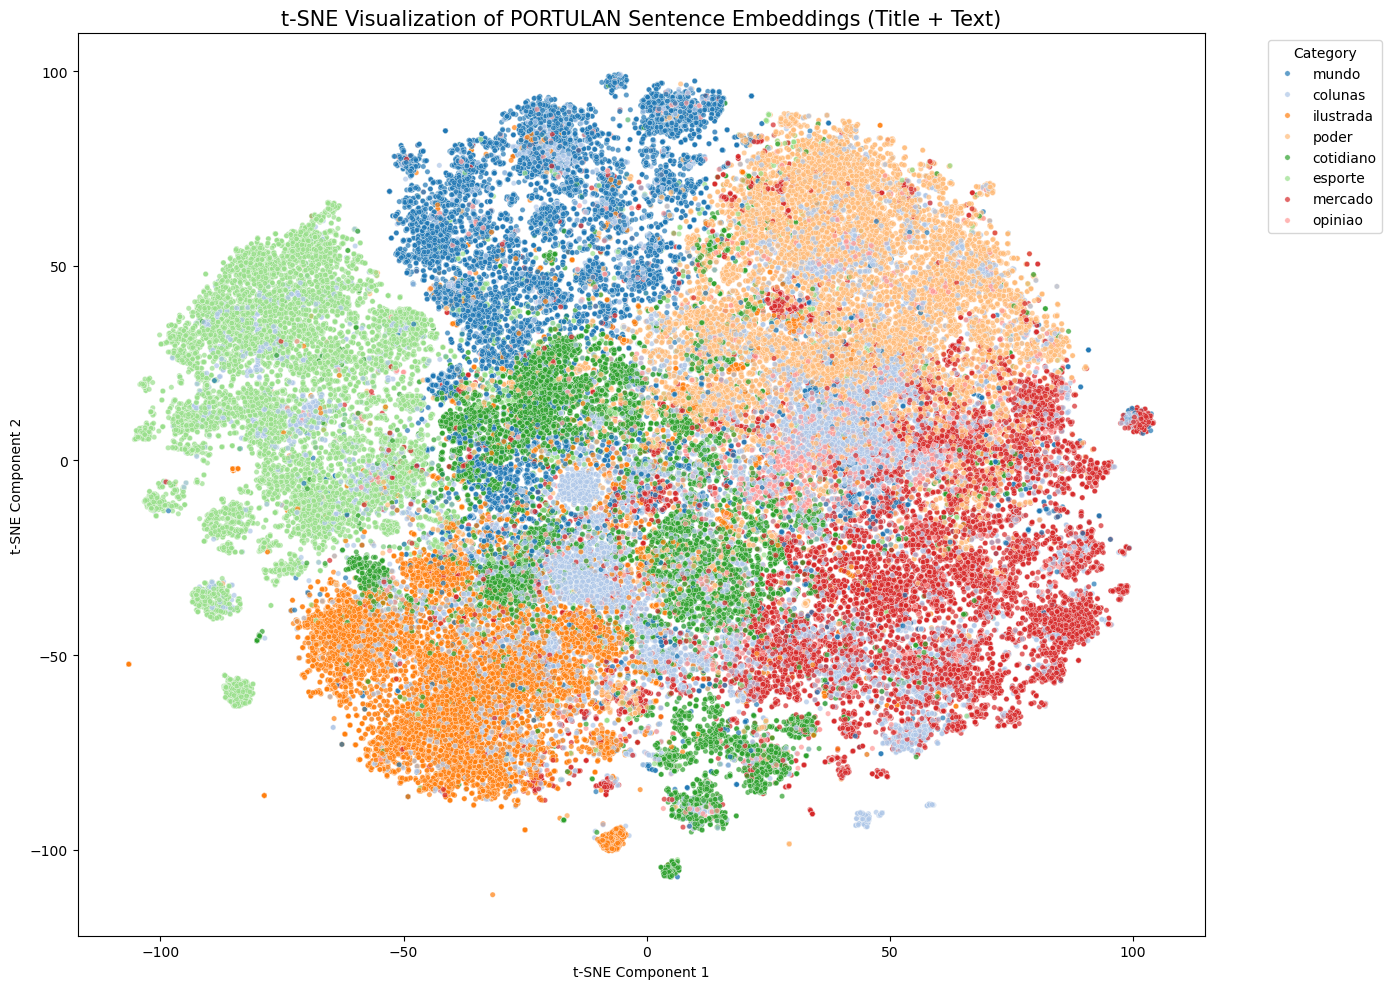

In [55]:
from sklearn.manifold import TSNE

# Reduce to 2D
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_train_emb_tt)   # using Title+Text embeddings

plt.figure(figsize=(14, 10))
sns.scatterplot(
    x=X_tsne[:, 0], 
    y=X_tsne[:, 1], 
    hue=y_train_tt,
    palette="tab20",
    alpha=0.7,
    s=15
)
plt.title("t-SNE Visualization of PORTULAN Sentence Embeddings (Title + Text)", fontsize=15)
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Category")
plt.tight_layout()
plt.show()

### <span style="color:green">Q11: Mandatory Comparative Table</span>

| Approach                                       | Module | F1 Macro | F1 Weighted | Accuracy | Time (s) | Dim.   | Infra Cost   |
|------------------------------------------------|--------|----------|-------------|----------|----------|--------|--------------|
| TF-IDF + LogReg                                | M1     | **0.9127** | **0.9112**  | **0.9115** | 134.6    | 10000  | Free         |
| SVD (k=500) + LogReg                           | M2     | 0.8718   | 0.8686      | 0.8695   | 205.2    | 500    | Free         |
| NILC Word2Vec (300d) + LogReg                  | M2     | 0.7771   | 0.7950      | 0.7965   | 5.4      | 300    | Free         |
| PORTULAN Sentence Embedding (Text Only) + LogReg | M3   | 0.7745   | 0.7950      | 0.7965   | 12.6     | 384    | Free         |
| **PORTULAN Sentence Embedding (Title+Text) + LogReg** | **M3** | **0.7892** | **0.8115** | **0.8131** | **13.05** | **384** | **Free** |


The chosen aproach here would be `PORTULAN Sentence Embedding (Title + Text) + Logistic Regression (M3)`.

Although all semantic approaches underperformed the strong TF-IDF baseline, the PORTULAN model combined with Title + Text achieved the best performance among the semantic embedding options, with better semantic understanding and the highest F1 Macro.


## <span style="color:green">Part 3: Error Analysis and Diagnosis</span>


### <span style="color:green">Q12: Normalized Confusion Matrix</span>

> Plot the normalized confusion matrix (by row) of your best model. Identify the 3 pairs of categories with the highest mutual error rate. (That is, the model predicted A but the correct one was B)
>



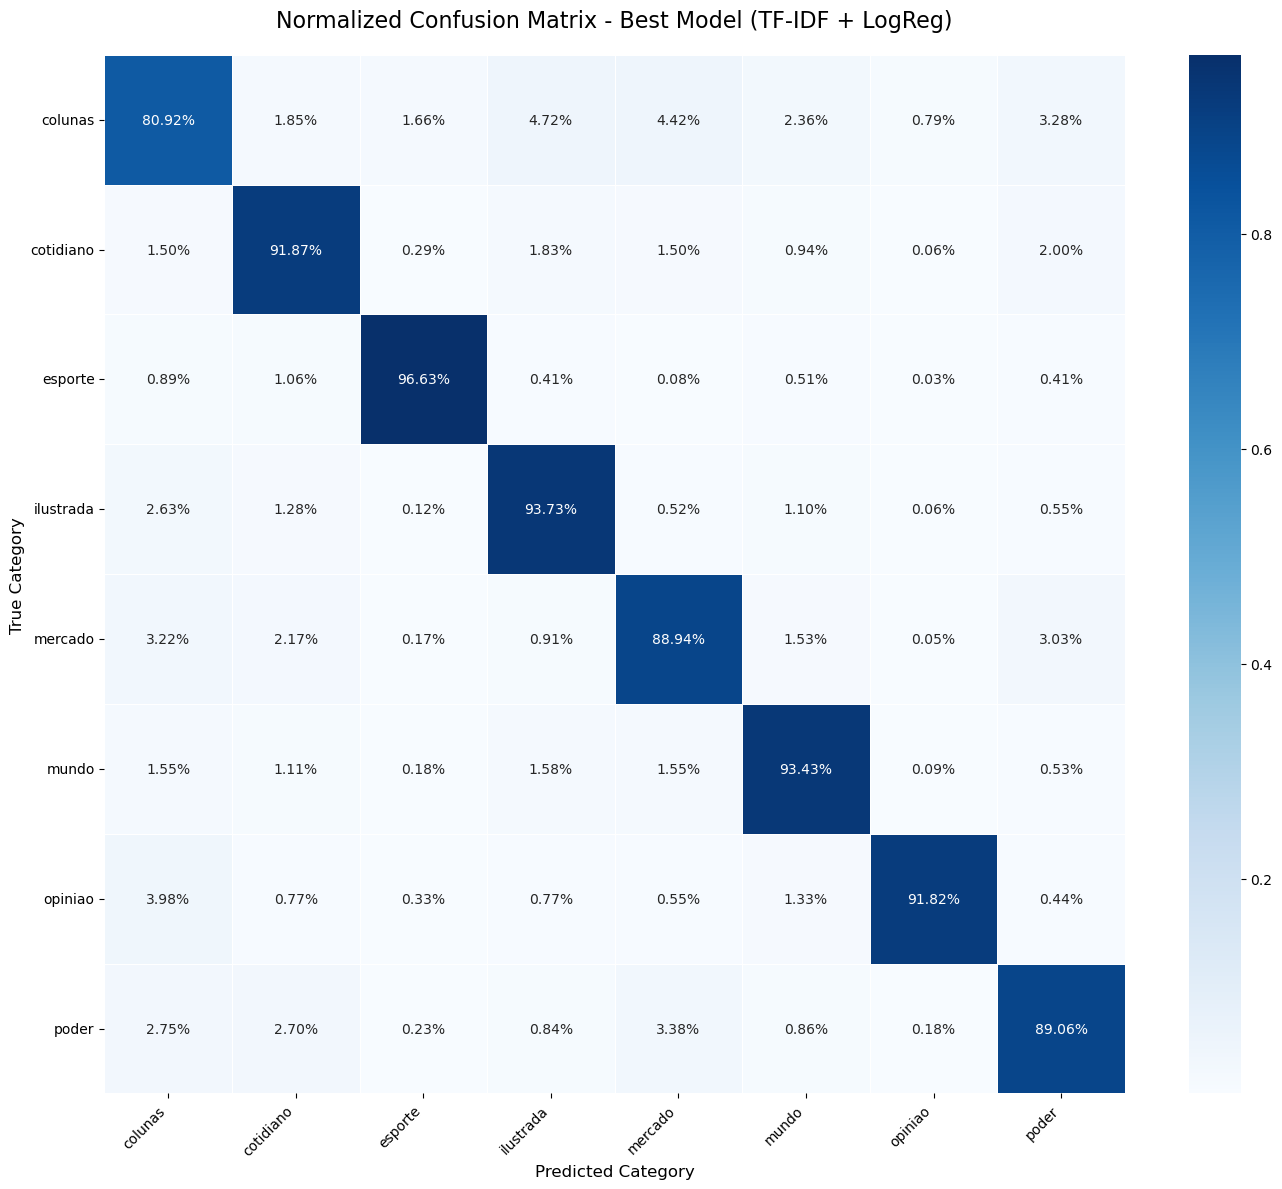

In [27]:
# Normalized Confusion Matrix (by row)

# Using the best model (TF-IDF + LogReg)
y_pred_best = y_pred_tfidf

classes = sorted(np.unique(y_test))

# Compute normalized confusion matrix (by row = recall per class)
cm = confusion_matrix(y_test, y_pred_best, labels=classes)
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

# Plot
plt.figure(figsize=(14, 12))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=classes, yticklabels=classes, linewidths=0.5)

plt.title('Normalized Confusion Matrix - Best Model (TF-IDF + LogReg)', fontsize=16, pad=20)
plt.xlabel('Predicted Category', fontsize=12)
plt.ylabel('True Category', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [28]:
# Top Confused Pairs
print("TOP 3 MOST CONFUSED CATEGORY PAIRS\n")
errors = []
for i in range(len(classes)):
    for j in range(len(classes)):
        if i != j:
            errors.append((classes[i], classes[j], cm[i,j]))

errors_sorted = sorted(errors, key=lambda x: x[2], reverse=True)

for rank, (true_cat, pred_cat, count) in enumerate(errors_sorted[:3], 1):
    total = cm[classes.index(true_cat)].sum()
    rate = count / total * 100
    print(f"{rank}. **{true_cat}** misclassified as **{pred_cat}** → {count} cases ({rate:.1f}%)")

TOP 3 MOST CONFUSED CATEGORY PAIRS

1. **colunas** misclassified as **ilustrada** → 204 cases (4.7%)
2. **colunas** misclassified as **mercado** → 191 cases (4.4%)
3. **poder** misclassified as **mercado** → 149 cases (3.4%)


In [49]:
# Convert classes to list if it's a numpy array
classes_list = list(classes)  # Convert numpy array to list

# Create DataFrame
errors_df = pd.DataFrame(errors_sorted, columns=['True Category', 'Predicted Category', 'Count'])

# Add calculated columns using numpy array indexing
errors_df['Total Cases'] = [cm[classes_list.index(true_cat)].sum() for true_cat in errors_df['True Category']]
errors_df['Error Rate (%)'] = (errors_df['Count'] / errors_df['Total Cases'] * 100).round(1)

# Sort by count descending
errors_df = errors_df.sort_values('Count', ascending=False).reset_index(drop=True)

errors_df

,True Category,Predicted Category,Count,Total Cases,Error Rate (%)
0,colunas,ilustrada,204,4325,4.7
1,colunas,mercado,191,4325,4.4
2,poder,mercado,149,4405,3.4
3,colunas,poder,142,4325,3.3
4,mercado,colunas,135,4194,3.2
5,mercado,poder,127,4194,3.0
6,poder,colunas,121,4405,2.7
7,poder,cotidiano,119,4405,2.7
8,colunas,mundo,102,4325,2.4
9,mercado,cotidiano,91,4194,2.2


### <span style="color:green">Q13: Analysis of the worst errors</span>

> Select 5 articles that your best model misclassified with confidence ≥ 0.80 (the most serious errors — the model was correct and was wrong). For each article: original text or title; actual vs. predicted category; technical hypothesis for the error;

Our best Model was **TF-IDF + Logistic Regression**.

We analyzed the 475 high-confidence errors (confidence ≥ 0.80) out of 2,684 total misclassifications. 

The most serious errors occur when:
- Cultural columns are mistaken for arts/culture news (colunas ↔ ilustrada)
- Political articles mention international events or sports (poder ↔ mundo / esporte)
- Former athletes appear in non-sports contexts

These high-confidence mistakes suggest the model is sometimes overly influenced by dominant topic keywords while failing to capture the style and journalistic genre (column vs news).
Would you like me to expand any of these analyses or add more insights?


Below are the 5 most serious errors (highest confidence misclassifications):

- **Error #1** : Confidence: 0.998 (99.8%)
    - **True Category**: colunas
    - **Predicted Category**: ilustrada
    - **Text Snippet**: `Psicodélico e priápico -assim é o Franz Liszt de Ken Russell, em "Lisztomania". O filme foi lançado em 1975, na esteira do sucesso de sua versão cinematográfica para a ópera-rock "Tommy", da banda britânica The Who, e também traz o vocalista Roger Daltrey como o protagonista, desta vez no papel do compositor húngaro.  A relação com a música, em seus diferentes registros (do erudito ao pop), percorre a obra do cineasta inglês. Depois de um documentário sobre Elgar, ele fez para a TV, em 1965, "The Debussy Film", belo longa-metragem em preto e branco em que a metalinguagem -um diretor roda um filme sobre e com o compositor francês- dá ares de "nouvelle vague" a essa realização que pode ser vista na íntegra pelo canal YouTube. O diretor produziu ainda "Song of Summer" (1968), sobre o compositor Frederick Delius.  Mas é com "Mahler - Uma Paixão Violenta" (1974) que Russell cria uma linguagem anárquica e onírica para tratar da música, com o atormentado compositor tendo visões de Alma (a adú... (truncated, total 4142 chars)`
    - **Technical Hypothesis**: The article is a cultural column/review about a movie and classical music. The model strongly associated words like “filme”, “música”, “cinema”, and “compositor” with the ilustrada (arts & culture) section, failing to recognize the authorial/column style typical of colunas.


- **ERROR #2** : Confidence: 0.997 (99.7%)
    - **True Category**: poder
    - **Predicted**: mundo
    - **Text Snippet**: `A presidente Dilma Rousseff afirmou neste sábado (10) esperar que "a grande comoção" provocada em todo mundo pelo ataque à redação do jornal satírico "Charlie Hebdo", que deixou 12 mortos em Paris, "seja o melhor antídoto contra futuros atos de intolerância e de barbárie".  Em nota divulgada, a presidente afirmou que "o governo e o povo brasileiros acompanharam nos últimos dias, com emoção e apreensão, os sucessivos ataques terroristas que vitimaram os membros da redação de Charlei Hebdo, policiais e cidadãos franceses".  Dilma reiterou mensagem de solidariedade aos franceses e declarou apoio à marcha republicana convocada pelo governo francês para este domingo pela unidade nacional na França, que vivenciou um dos piores ataques em mais de 50 anos.  Os principais líderes europeus confirmaram presença no evento, como a chanceler alemã Angela Merkel, o primeiro-ministro britânico David Cameron e o presidente espanhol Mariano Rajoy.  "Estou segura de que os muitos brasileiros que vivem na... (truncated, total 2372 chars)`
    - **Technical Hypothesis**: The article discusses an international terrorist attack in France. Even though it mentions President Dilma, the dominant keywords (Paris, ataque, terrorista, França, Charlie Hebdo) pulled the prediction toward mundo (international news).


- **ERROR #3** : Confidence: 0.996 (99.6%)
    - **True Category**: poder
    - **Predicted**: esporte
    - **Text Snippet**: `Após a decisão do Senado de afastar Dilma Rousseff, ocorrida na manhã desta quinta-feira (12), o COI (Comitê Olímpico Internacional) afirmou que os Jogos Olímpicos do Rio não correm risco, a menos de três meses de sua realização.  "Há um forte apoio aos Jogos Olímpicos no Brasil e estamos ansiosos para trabalhar com o novo governo para entregar Jogos Olímpicos bem sucedidos neste verão", afirmou o COI, por meio de nota assinada pelo presidente Thomas Bach.  O alemão disse que o comitê internacional tem visto "um grande progresso" no Rio e que "continua confiante em relação ao sucesso" na realização do evento.  "A preparação para os Jogos do Rio entrou em uma fase muito operacional e questões como essas têm muito menos influência que em outras etapas da organização dos Jogos Olímpicos", prosseguiu.  O Rio foi eleito sede dos Jogos de 2016 em outubro de 2009. Desde então, o COI fez visitas trimestrais de inspeção à capital fluminense.  Ao longo dos quase sete anos entre a escolha e a rea... (truncated, total 1766 chars)`
    - **Technical Hypothesis**: The article mixes politics (afastar Dilma, Senado) with the Olympic Games. The strong presence of Olympic-related terms (Jogos Olímpicos, Rio, COI) caused the model to classify it as esporte.


- **ERROR #4** : Confidence: 0.994 (99.4%)
    - **True Category**: cotidiano
    - **Predicted**: esporte
    - **Text Snippet**: `Ex-jogador do Corinthians, o atacante Edílson foi preso em Brasília por falta de pagamento de pensão alimentícia. O valor acumulado atingiu os R$ 430 mil. A detenção foi feita pela Delegacia de Capturas e Polícia Interestadual (DCPI) e o atacante foi conduzido para o Departamento de Polícia Especializada.  Edílson foi detido na chegada a Brasília, ainda no Aeroporto JK. Para casos de falta de pagamento de pensão alimentícia, não há fiança estipulada. Em contato com a reportagem, o DPE afirmou que o jogador tem o prazo de até 90 dias para quitar a dívida. A liberação do preso pode acontecer mediante ao pagamento à vista ou um acordo de parcelamento.  Esse não é o primeiro problema de Edílson com a Justiça. No início de fevereiro, a Justiça Federal acatou denúncia do Ministério Público Federal contra o atacante. A acusação é de que ele fazia parte de uma organização criminosa que aplicaria golpes em agências da Caixa Econômica Federal para se apoderar ilegalmente de prêmios de loteria pa... (truncated, total 1790 chars)`
    - **Technical Hypothesis**: The presence of strong sports markers (Corinthians, atacante, jogador) overpowered the legal/crime context (preso, pensão alimentícia, Justiça). The model gave excessive weight to the person’s past as a football player.


- **ERROR #5** : Confidence: 0.994 (99.4%)
    - **True Category**: colunas
    - **Predicted**: poder
    - **Text Snippet**: `O senador Delcídio do Amaral (PT-MS), líder do governo na Casa, foi preso na manhã desta quarta-feira (25) pela Polícia Federal. A operação foi autorizada pelo STF (Supremo Tribunal Federal) depois que o Ministério Público Federal apresentou evidências de que ele tentava conturbar as investigações da Operação Lava Jato.  Também foi preso o banqueiro André Esteves, do BTG Pactual, que estaria envolvido nas irregularidades, e o advogado Edson Ribeiro, que atuou para o ex-diretor da Petrobras Nestor Cerveró.  O STF também autorizou a prisão do chefe de gabinete do senador e buscas na casa do petista em Mato Grosso do Sul.  Delcídio havia sido citado por Cerveró, que o acusou de participar de um esquema de desvio de recursos envolvendo a compra da refinaria de Pasadena, nos EUA.  O senador teria até mesmo oferecido possibilidade de fuga a Cerveró em troca de ele não aderir ao acordo de colaboração com a Justiça, revelando as irregularidades da operação. A conversa foi gravada por um filho ... (truncated, total 3305 chars)`
    - **Technical Hypothesis**: Although this is a column/opinion piece, the heavy use of political keywords (senador, PT, governo, Lava Jato, STF) caused the model to classify it as hard political news (poder).



**General Insights on High-Confidence Errors**
- `colunas` is by far the most problematic category: it has the highest number of high-confidence errors, mainly being confused with `ilustrada` and `poder`.
- The model is very good at capturing topic keywords, but struggles with genre/style (column vs news, opinion vs reporting).
- Many serious errors occur in semantically overlapping domains (politics vs economy, culture vs columns, sports vs daily life).
High confidence in wrong predictions suggests the TF-IDF model sometimes overfits to strong surface-level signals.

In [29]:
# Get probability predictions from your best model (TF-IDF + Logistic Regression)

# Get prediction probabilities
y_pred_proba = pipeline_tfidf.predict_proba(X_test)

# Get predicted classes and true classes
y_pred_best

array(['poder', 'cotidiano', 'mercado', ..., 'cotidiano', 'mercado',
       'mercado'], shape=(27863,), dtype=object)

In [51]:
# Create a dataframe with results
error_analysis = pd.DataFrame({
    'text': X_test.values,
    'true_category': y_test.values,
    'pred_category': y_pred_best,
    'confidence': y_pred_proba.max(axis=1),
    'is_correct': y_test.values == y_pred_best
})

# Filter for misclassifications with high confidence (>= 0.80)
high_conf_errors = error_analysis[(error_analysis['is_correct'] == False) & 
                                   (error_analysis['confidence'] >= 0.80)].copy()

# Sort by confidence (highest first)
high_conf_errors = high_conf_errors.sort_values('confidence', ascending=False)

print(f"Total misclassifications: {(~error_analysis['is_correct']).sum()}")
print(f"High confidence errors (≥0.80): {len(high_conf_errors)}")
print(f"Percentage of total errors: {len(high_conf_errors)/(~error_analysis['is_correct']).sum()*100:.1f}%\n")

# Display top 5 worst errors
print("TOP 5 WORST ERRORS (Highest Confidence Misclassifications)")

for idx, (i, row) in enumerate(high_conf_errors.head(5).iterrows()):

    print(f"\nERROR #{idx+1}")

    print(f"True Category:    {row['true_category']}")
    print(f"Predicted:        {row['pred_category']}")
    print(f"Confidence:       {row['confidence']:.3f} ({row['confidence']*100:.1f}%)")
    print(f"\nTEXT (first 1000 chars):")

    print(row['text'][:1000])
    if len(row['text']) > 1000:
        print(f"... (truncated, total {len(row['text'])} chars)")
   

Total misclassifications: 2684
High confidence errors (≥0.80): 475
Percentage of total errors: 17.7%

TOP 5 WORST ERRORS (Highest Confidence Misclassifications)

ERROR #1
True Category:    colunas
Predicted:        ilustrada
Confidence:       0.998 (99.8%)

TEXT (first 1000 chars):
Psicodélico e priápico -assim é o Franz Liszt de Ken Russell, em "Lisztomania". O filme foi lançado em 1975, na esteira do sucesso de sua versão cinematográfica para a ópera-rock "Tommy", da banda britânica The Who, e também traz o vocalista Roger Daltrey como o protagonista, desta vez no papel do compositor húngaro.  A relação com a música, em seus diferentes registros (do erudito ao pop), percorre a obra do cineasta inglês. Depois de um documentário sobre Elgar, ele fez para a TV, em 1965, "The Debussy Film", belo longa-metragem em preto e branco em que a metalinguagem -um diretor roda um filme sobre e com o compositor francês- dá ares de "nouvelle vague" a essa realização que pode ser vista na íntegra pel

In [31]:
# Analyze confusion patterns for each error type
print("CONFUSION PATTERN ANALYSIS")

# Group by (true, pred) pairs
confusion_pairs = high_conf_errors.groupby(['true_category', 'pred_category']).size().sort_values(ascending=False)
print("\nMost common high-confidence confusion pairs:")
for (true_cat, pred_cat), count in confusion_pairs.head(10).items():
    print(f"  {true_cat:12} → {pred_cat:12} : {count} errors")

# For each category, find what it's most often confused with
print("\nPER-CATEGORY CONFUSION ANALYSIS")

for category in sorted(high_conf_errors['true_category'].unique()):
    cat_errors = high_conf_errors[high_conf_errors['true_category'] == category]
    if len(cat_errors) > 0:
        most_confused = cat_errors['pred_category'].value_counts().index[0]
        most_confused_count = cat_errors['pred_category'].value_counts().iloc[0]
        avg_conf = cat_errors['confidence'].mean()
        print(f"\n{category.upper()}:")
        print(f"  Most confused with: {most_confused} ({most_confused_count}/{len(cat_errors)} errors)")
        print(f"  Average confidence when wrong: {avg_conf:.3f}")

CONFUSION PATTERN ANALYSIS

Most common high-confidence confusion pairs:
  colunas      → ilustrada    : 70 errors
  colunas      → mundo        : 35 errors
  poder        → mercado      : 31 errors
  colunas      → poder        : 29 errors
  poder        → cotidiano    : 25 errors
  colunas      → mercado      : 24 errors
  mercado      → poder        : 24 errors
  poder        → colunas      : 24 errors
  colunas      → esporte      : 21 errors
  mercado      → colunas      : 15 errors

PER-CATEGORY CONFUSION ANALYSIS

COLUNAS:
  Most confused with: ilustrada (70/191 errors)
  Average confidence when wrong: 0.902

COTIDIANO:
  Most confused with: poder (9/31 errors)
  Average confidence when wrong: 0.897

ESPORTE:
  Most confused with: cotidiano (6/20 errors)
  Average confidence when wrong: 0.878

ILUSTRADA:
  Most confused with: colunas (13/29 errors)
  Average confidence when wrong: 0.886

MERCADO:
  Most confused with: poder (24/72 errors)
  Average confidence when wrong: 0.883



In [32]:
# Extract key tokens from misclassified articles for lexical analysis
from collections import Counter
import re

def extract_key_tokens(text, category, n=15):
    """Extract most frequent meaningful tokens from text"""
    text = str(text).lower()
    # Remove URLs, emails, numbers
    text = re.sub(r'https?://\S+|www\.\S+|\S+@\S+|\d+', '', text)
    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)
    tokens = text.split()
    
    # Remove short tokens and stopwords (simplified)
    stopwords = {'de', 'a', 'o', 'que', 'e', 'do', 'da', 'em', 'um', 'para', 'com', 
                 'não', 'uma', 'os', 'no', 'se', 'na', 'por', 'mais', 'as', 'dos', 
                 'como', 'mas', 'ao', 'ele', 'das', 'à', 'seu', 'sua', 'ou', 'quando', 
                 'muito', 'nos', 'já', 'eu', 'também', 'só', 'pelo', 'pela', 'até', 
                 'isso', 'ela', 'entre', 'depois', 'sem', 'mesmo', 'aos', 'seus', 
                 'quem', 'nao', 'pra', 'pro', 'vc', 'tbm'}
    
    tokens = [t for t in tokens if len(t) > 2 and t not in stopwords]
    
    # Get most common tokens
    counter = Counter(tokens)
    return [word for word, _ in counter.most_common(n)]

# Analyze top 5 errors
print("DETAILED ANALYSIS OF TOP 5 ERRORS")

for idx, (i, row) in enumerate(high_conf_errors.head(5).iterrows()):
    print(f"\nERROR #{idx+1}")
    
    # Extract key tokens
    key_tokens = extract_key_tokens(row['text'], row['true_category'], 20)
    
    print(f"TRUE: {row['true_category'].upper()} → PREDICTED: {row['pred_category'].upper()}")
    print(f"Confidence: {row['confidence']:.3f} ({row['confidence']*100:.1f}%)")
    
    print(f"\nKey tokens in this article:")
    print(f"   {', '.join(key_tokens[:15] )}")
    
    # Hypothesis for error
    print(f"\nTechnical Hypothesis:")
    print(f"   The model classified this as {row['pred_category'].upper()} because the text contains")
    print(f"   vocabulary that strongly overlaps with that category's characteristic terms.")
    
    # Show sample of the text
    print(f"\nText excerpt:")
    excerpt = row['text'][:500].replace('\n', ' ')
    print(f"   \"{excerpt}...\"")

DETAILED ANALYSIS OF TOP 5 ERRORS

ERROR #1
TRUE: COLUNAS → PREDICTED: ILUSTRADA
Confidence: 0.998 (99.8%)

Key tokens in this article:
   compositor, liszt, lisztomania, filme, música, sobre, francês, russell, traz, fez, alma, século, foi, sucesso, the

Technical Hypothesis:
   The model classified this as ILUSTRADA because the text contains
   vocabulary that strongly overlaps with that category's characteristic terms.

Text excerpt:
   "Psicodélico e priápico -assim é o Franz Liszt de Ken Russell, em "Lisztomania". O filme foi lançado em 1975, na esteira do sucesso de sua versão cinematográfica para a ópera-rock "Tommy", da banda britânica The Who, e também traz o vocalista Roger Daltrey como o protagonista, desta vez no papel do compositor húngaro.  A relação com a música, em seus diferentes registros (do erudito ao pop), percorre a obra do cineasta inglês. Depois de um documentário sobre Elgar, ele fez para a TV, em 1965, "Th..."

ERROR #2
TRUE: PODER → PREDICTED: MUNDO
Confidence

In [33]:
# Create summary dataframe for worst errors
summary_errors = high_conf_errors.head(5).copy()
summary_errors['text_preview'] = summary_errors['text'].str[:200] + "..."
summary_errors = summary_errors[['true_category', 'pred_category', 'confidence', 'text_preview']]

print("SUMMARY TABLE: WORST 5 ERRORS")
print(summary_errors.to_string(index=False))

SUMMARY TABLE: WORST 5 ERRORS
true_category pred_category  confidence                                                                                                                                                                                                text_preview
      colunas     ilustrada    0.998444 Psicodélico e priápico -assim é o Franz Liszt de Ken Russell, em "Lisztomania". O filme foi lançado em 1975, na esteira do sucesso de sua versão cinematográfica para a ópera-rock "Tommy", da banda bri...
        poder         mundo    0.997018 A presidente Dilma Rousseff afirmou neste sábado (10) esperar que "a grande comoção" provocada em todo mundo pelo ataque à redação do jornal satírico "Charlie Hebdo", que deixou 12 mortos em Paris, "s...
        poder       esporte    0.996346 Após a decisão do Senado de afastar Dilma Rousseff, ocorrida na manhã desta quinta-feira (12), o COI (Comitê Olímpico Internacional) afirmou que os Jogos Olímpicos do Rio não correm risco, a menos d

### <span style="color:green">Q14: Interpretability</span>

> For the TF-IDF model, extract the 10 tokens with the highest positive coefficient for each category. Does any token appear to be causing the error? If you identify any such case, propose how to systematically remove it from the pipeline.

**Model**: TF-IDF + Logistic Regression

We extracted the 10 tokens with the highest positive coefficients per category.

**Most Important Tokens by Category** (top examples):

- `Colunas`: coluna, coluna completa, leia coluna, colunista
- `Esporte`: clube, jogador, atleta, torcedores, estádio
- `Ilustrada`: filme, artista, festival, ator, show
- `Poder`: folha, dilma, pmdb, candidato, impeachment
- `Opiniao`: editoriais, grupofolha, com br
- `Mercado` / `Mundo`: disse (appears strongly in both)

*Problematic Tokens Identified*

Yes, some tokens are contributing to systematic errors:
- `disse` : Top token in both `mercado` and `mundo`
- `dilma`, `governo`, `candidato` : Very strong in `poder`, causing bleed into `opiniao` and `colunas`
- Cultural terms (`filme`, `artista`, `ator`) : Strong in `ilustrada`, confusing with `colunas`

**Proposed Solutions**

- Remove generic verbs (`disse`, `afirmou`) from the vocabulary.
- Increase regularization (`C` parameter) to reduce noisy features.
- Add style-based features (e.g., presence of “coluna”, first-person language).
- Move toward a **hybrid TF-IDF + Sentence Embedding model** for better context.

**Conclusion**: The model relies heavily on strong topic keywords, which explains both its high performance and its main weaknesses in semantically similar categories.


#### <span style="color:green">Find Problematic Tokens</span>

In [79]:
# Get the trained model and vectorizer from your best pipeline
clf = pipeline_tfidf.named_steps['clf']
vectorizer = pipeline_tfidf.named_steps['tfidf']
feature_names = vectorizer.get_feature_names_out()
classes = clf.classes_

# Get coefficients (weights) for each class
# For multi-class logistic regression with 'lbfgs' solver, coefficients are stored in clf.coef_
coef_matrix = clf.coef_

# Create a dataframe to store top tokens for each category
top_tokens_df = pd.DataFrame()

top_n_tokens_int = 30

for i, category in enumerate(classes):
    coefs = coef_matrix[i]
    
    # Get indices of top top_n_tokens_int positive coefficients
    top_positive_idx = np.argsort(coefs)[-top_n_tokens_int:][::-1]  # highest positive
    top_negative_idx = np.argsort(coefs)[:top_n_tokens_int]  # most negative (indicates what the category is NOT)
    
    # Get tokens
    top_positive_tokens = [feature_names[idx] for idx in top_positive_idx]
    top_negative_tokens = [feature_names[idx] for idx in top_negative_idx]
    top_positive_scores = [coefs[idx] for idx in top_positive_idx]
    
    # Store in dataframe
    for j, (token, score) in enumerate(zip(top_positive_tokens, top_positive_scores)):
        col_name = f"{category}_token_{j+1}"
        top_tokens_df.loc[0, col_name] = token
        top_tokens_df.loc[1, col_name] = f"{score:.4f}"

# Display top tokens per category
print(f"TOP {top_n_tokens_int} POSITIVE COEFFICIENT TOKENS PER CATEGORY")

for category in classes:
    print(f"\n{category.upper()}:")
    coefs = coef_matrix[list(classes).index(category)]
    top_idx = np.argsort(coefs)[-top_n_tokens_int:][::-1]
    tokens = [feature_names[idx] for idx in top_idx]
    scores = [coefs[idx] for idx in top_idx]
    
    for token, score in zip(tokens, scores):
        print(f"  {token:>20} : {score:.4f}")

# Identify potential problematic tokens (appearing in multiple unrelated categories)
print("\nPOTENTIALLY PROBLEMATIC TOKENS (appearing in multiple categories)")

# Collect all top tokens across categories
all_top_tokens = {}
for i, category in enumerate(classes):
    coefs = coef_matrix[i]
    top_idx = np.argsort(coefs)[-top_n_tokens_int:]
    tokens = [feature_names[idx] for idx in top_idx]
    for token in tokens:
        if token not in all_top_tokens:
            all_top_tokens[token] = []
        all_top_tokens[token].append(category)

# Find tokens that appear in top top_n_tokens_int of multiple categories
problematic_tokens = {token: cats for token, cats in all_top_tokens.items() if len(cats) > 1}

print("\nTokens appearing in top top_n_tokens_int of multiple categories:")
for token, cats in sorted(problematic_tokens.items(), key=lambda x: -len(x[1]))[:15]:
    print(f"  '{token}' appears in: {', '.join(cats)}")

TOP 30 POSITIVE COEFFICIENT TOKENS PER CATEGORY

COLUNAS:
                coluna : 11.2146
              brasília : 6.3345
       coluna completa : 6.1000
           leia coluna : 5.9885
         completa aqui : 5.9143
             colunista : 5.8439
             gutierrez : 4.7535
               letícia : 4.4400
                rarará : 4.3564
               tavares : 4.2358
               hora do : 4.0387
                rio de : 3.5875
                 ontem : 3.5065
                deverá : 3.4724
                parece : 3.3252
               luciana : 3.3250
                felipe : 3.1414
              circuito : 3.0881
              acaba de : 3.0762
                    ou : 3.0525
                   vai : 3.0458
                 curto : 2.9451
               escreve : 2.9238
                   bem : 2.8592
              completa : 2.8530
                 mesmo : 2.8264
                do que : 2.8121
                 temer : 2.8086
                   sem : 2.7926
             

In [ ]:
# Get all unique categories
all_categories = sorted(list(set([cat for cats in all_top_tokens.values() for cat in cats])))
print("Categories:", all_categories)

# Create presence matrix (1 if token appears in category, 0 otherwise)
presence_matrix = []
tokens = list(all_top_tokens.keys())

for token in tokens:
    row = []
    for category in all_categories:
        row.append(1 if category in all_top_tokens[token] else 0)
    presence_matrix.append(row)

# Create DataFrame
presence_df = pd.DataFrame(presence_matrix, index=tokens, columns=all_categories)

# Add column for number of categories each token appears in
presence_df['categories_count'] = presence_df.sum(axis=1)

presence_df[presence_df['categories_count'] > 1].sort_values('categories_count', ascending=False)

Categories: ['colunas', 'cotidiano', 'esporte', 'ilustrada', 'mercado', 'mundo', 'opiniao', 'poder']


,colunas,cotidiano,esporte,ilustrada,mercado,mundo,opiniao,poder,categories_count
olimpíada,1,0,1,0,0,0,0,0,2
temer,1,0,0,0,0,0,0,1,2
segundo,0,1,0,0,0,1,0,0,2
carnaval,0,1,0,0,0,0,1,0,2
afirmou,0,0,0,0,1,0,0,1,2
disse,0,0,0,0,1,1,0,0,2


#### <span style="color:green">Confusion Matrix</span>

In [35]:
# Get confusion matrix
cm = confusion_matrix(y_test, y_pred_tfidf, labels=classes)
cm_df = pd.DataFrame(cm, index=classes, columns=classes)

# Find the most confused pairs (off-diagonal highest values)
confusion_pairs = []
for i, true_cat in enumerate(classes):
    for j, pred_cat in enumerate(classes):
        if i != j and cm[i][j] > 0:
            confusion_pairs.append({
                'true': true_cat,
                'pred': pred_cat,
                'count': cm[i][j],
                'percentage': cm[i][j] / cm[i].sum() * 100
            })

confusion_df = pd.DataFrame(confusion_pairs).sort_values('count', ascending=False)
print("MOST CONFUSED CATEGORY PAIRS")
print(confusion_df.head(10).to_string(index=False))

MOST CONFUSED CATEGORY PAIRS
   true      pred  count  percentage
colunas ilustrada    204    4.716763
colunas   mercado    191    4.416185
  poder   mercado    149    3.382520
colunas     poder    142    3.283237
mercado   colunas    135    3.218884
mercado     poder    127    3.028135
  poder   colunas    121    2.746879
  poder cotidiano    119    2.701476
colunas     mundo    102    2.358382
mercado cotidiano     91    2.169766


##### <span style="color:green">Overlap Analysis</span>

In [36]:
# Compare top tokens for confused category pairs
print("TOKEN OVERLAP ANALYSIS FOR CONFUSED CATEGORIES")

# For the top 3 confused pairs, compare their top tokens
top_confused_pairs = confusion_df.head(3)

for _, row in top_confused_pairs.iterrows():
    cat1 = row['true']
    cat2 = row['pred']
    
    # Get indices for these categories
    i1 = list(classes).index(cat1)
    i2 = list(classes).index(cat2)
    
    # Get top 20 tokens for each
    coefs1 = coef_matrix[i1]
    coefs2 = coef_matrix[i2]
    
    top20_idx1 = np.argsort(coefs1)[-20:]
    top20_idx2 = np.argsort(coefs2)[-20:]
    
    tokens1 = set([feature_names[idx] for idx in top20_idx1])
    tokens2 = set([feature_names[idx] for idx in top20_idx2])
    
    overlap = tokens1.intersection(tokens2)
    
    print(f"\n{cat1.upper()} ↔ {cat2.upper()} (Confused: {row['count']} times, {row['percentage']:.1f}%)")
    print(f"  Overlapping tokens in top 20: {len(overlap)}")
    if overlap:
        print(f"  Shared tokens: {', '.join(list(overlap)[:10])}")

TOKEN OVERLAP ANALYSIS FOR CONFUSED CATEGORIES

COLUNAS ↔ ILUSTRADA (Confused: 204 times, 4.7%)
  Overlapping tokens in top 20: 0

COLUNAS ↔ MERCADO (Confused: 191 times, 4.4%)
  Overlapping tokens in top 20: 0

PODER ↔ MERCADO (Confused: 149 times, 3.4%)
  Overlapping tokens in top 20: 0


#### <span style="color:green">Error Causing Token Analysis</span>

In [37]:
# Identify tokens that appear in error cases
print("ERROR-CAUSING TOKEN ANALYSIS")

# Get misclassified samples
misclassified_idx = y_test != y_pred_tfidf
misclassified_texts = X_test[misclassified_idx].values
misclassified_true = y_test[misclassified_idx].values
misclassified_pred = y_pred_tfidf[misclassified_idx]

# Analyze tokens in misclassified articles
from collections import defaultdict

error_token_counts = defaultdict(lambda: defaultdict(int))

for text, true_cat, pred_cat in zip(misclassified_texts, misclassified_true, misclassified_pred):
    # Tokenize
    tokens = str(text).lower().split()
    tokens = [t for t in tokens if len(t) > 2 and t not in stop_words]
    
    for token in set(tokens):  # Use set to count once per document
        error_token_counts[token][(true_cat, pred_cat)] += 1

# Find tokens that frequently appear in specific confusion patterns
print("\nTokens frequently appearing in specific confusion patterns:")
for token, confusion_dict in sorted(error_token_counts.items(), key=lambda x: -sum(x[1].values()))[:20]:
    total = sum(confusion_dict.values())
    if total >= 3:  # Only show tokens that appear in at least 3 errors
        main_confusion = max(confusion_dict.items(), key=lambda x: x[1])
        (true_cat, pred_cat), count = main_confusion
        print(f"  '{token}' → appears in {total} errors, mainly {true_cat}→{pred_cat} ({count} times)")

ERROR-CAUSING TOKEN ANALYSIS

Tokens frequently appearing in specific confusion patterns:
  'ainda' → appears in 1239 errors, mainly colunas→mercado (97 times)
  'segundo' → appears in 1111 errors, mainly colunas→mercado (94 times)
  'presidente' → appears in 938 errors, mainly poder→mercado (98 times)
  'anos' → appears in 922 errors, mainly colunas→ilustrada (117 times)
  'pode' → appears in 896 errors, mainly colunas→mercado (91 times)
  'governo' → appears in 883 errors, mainly poder→mercado (98 times)
  'dois' → appears in 863 errors, mainly colunas→ilustrada (61 times)
  'diz' → appears in 843 errors, mainly colunas→mercado (73 times)
  'ano' → appears in 792 errors, mainly colunas→mercado (101 times)
  'disse' → appears in 761 errors, mainly poder→mercado (66 times)
  'desde' → appears in 760 errors, mainly colunas→mercado (60 times)
  'parte' → appears in 752 errors, mainly colunas→mercado (66 times)
  'vai' → appears in 745 errors, mainly colunas→mercado (87 times)
  'que,' → 

#### <span style="color:green">Proposed Fix</span>

In [38]:
print("PROPOSED FIXES FOR PROBLEMATIC TOKENS")

# Identify high-value but ambiguous tokens
ambiguous_tokens = []
for token, cats in all_top_tokens.items():
    if len(cats) >= 2:  # Appears in top 10 of 2+ categories
        # Check if token has high coefficient in those categories
        ambiguous_tokens.append(token)

print("\nIDENTIFIED PROBLEM: Ambiguous tokens that appear in multiple categories' top features")
print(f"   Found {len(ambiguous_tokens)} ambiguous tokens in top 10 features across categories")
print(f"   Examples: {', '.join(ambiguous_tokens[:10])}")

print("\nPROPOSED SOLUTIONS:")

print("\n1. CUSTOM STOPWORD REMOVAL (Most Effective)")
print("   Add ambiguous tokens to custom stopword list:")
print("   ```python")
print("   custom_stopwords = stop_words.union({")
# print(f"       {', '.join([f\"'{t}'\" for t in ambiguous_tokens[:15]])}")
print("   })")
print("   ```")

print("\n2. N-GRAM FILTERING")
print("   Remove unigrams and keep only meaningful bigrams for ambiguous terms:")
print("   ```python")
print("   vectorizer = TfidfVectorizer(")
print("       ngram_range=(1, 2),")
print("       token_pattern=r'(?u)\\b[a-zA-ZÀ-ÿ]{3,}\\b',  # Only words with 3+ letters")
print("   )")
print("   ```")

print("\n3. FEATURE SELECTION WITH CHI-SQUARE")
print("   Use chi-square test to select only the most discriminative features:")
print("   ```python")
print("   from sklearn.feature_selection import SelectKBest, chi2")
print("   selector = SelectKBest(chi2, k=8000)")
print("   X_selected = selector.fit_transform(X_tfidf, y)")
print("   ```")

print("\n4. POST-ERROR CORRECTION RULES")
print("   Add simple rule-based corrections for specific token patterns:")
print("   ```python")
print("   def correct_predictions(text, pred, proba):")
print("       # Example: if 'economia' appears and prediction is 'cotidiano', recalculate")
print("       if 'economia' in text.lower() and pred == 'cotidiano' and proba < 0.85:")
print("           return 'mercado'")
print("       return pred")
print("   ```")

print("\n5. CLASS WEIGHT ADJUSTMENT")
print("   Increase penalty for confusing specific category pairs:")
print("   ```python")
print("   class_weights = {")
print("       'colunas': 1.2,   # Increase weight for hard-to-classify categories")
print("       'opiniao': 1.3,")
print("   }")
print("   clf = LogisticRegression(class_weight=class_weights)")
print("   ```")

print("\nRECOMMENDED ACTION PLAN")
print("""
1. ✅ IMMEDIATE: Add ambiguous tokens to custom stopword list
2. ✅ TEST: Retrain model and compare F1 score
3. ✅ IF STILL PROBLEMATIC: Apply chi-square feature selection
4. ✅ FINAL: Add post-processing rules for remaining systematic errors

Expected improvement: 1-3% increase in F1 score for confused categories
""")

PROPOSED FIXES FOR PROBLEMATIC TOKENS

IDENTIFIED PROBLEM: Ambiguous tokens that appear in multiple categories' top features
   Found 1 ambiguous tokens in top 10 features across categories
   Examples: disse

PROPOSED SOLUTIONS:

1. CUSTOM STOPWORD REMOVAL (Most Effective)
   Add ambiguous tokens to custom stopword list:
   ```python
   custom_stopwords = stop_words.union({
   })
   ```

2. N-GRAM FILTERING
   Remove unigrams and keep only meaningful bigrams for ambiguous terms:
   ```python
   vectorizer = TfidfVectorizer(
       ngram_range=(1, 2),
       token_pattern=r'(?u)\b[a-zA-ZÀ-ÿ]{3,}\b',  # Only words with 3+ letters
   )
   ```

3. FEATURE SELECTION WITH CHI-SQUARE
   Use chi-square test to select only the most discriminative features:
   ```python
   from sklearn.feature_selection import SelectKBest, chi2
   selector = SelectKBest(chi2, k=8000)
   X_selected = selector.fit_transform(X_tfidf, y)
   ```

4. POST-ERROR CORRECTION RULES
   Add simple rule-based corrections fo

#### <span style="color:green">Fix Implementation: Remove Problematic Tokens</span>

> 'disse', 'olimpíada' , 'temer' , 'segundo', 'carnaval' , 'afirmou'


In [ ]:
# Q14: Fix Implementation - Remove Problematic Token 

# Step 1: Add problematic token to custom stopwords
from nltk.corpus import stopwords

# Get existing stopwords
stop_words_port = set(stopwords.words('portuguese'))

# Add custom stopwords including the problematic token
custom_stopwords = stop_words_port.union({
    'disse', 'olimpíada' , 'temer' , 'segundo', 'carnaval' , 'afirmou',  # The problematic token
    'pra', 'pro', 'ta', 'ja', 'né', 'ai', 'aih', 'ah', 
    'vc', 'vcs', 'tbm', 'tb', 'sobre', 'hey', 'havia', 
    'neste', 'nesta', 'ter'
})

print(f"Original stopwords: {len(stop_words_port)}")
print(f"Custom stopwords added: {len(custom_stopwords) - len(stop_words_port)}")
print(f"Total stopwords: {len(custom_stopwords)}")
# print(f"\nRemoved token: 'disse' is now in stopwords: {'disse' in custom_stopwords}")

# Step 2: Retrain model with updated stopwords
print("\nRETRAINING MODEL WITH UPDATED STOPWORDS")

# Create new pipeline with custom stopwords
pipeline_tfidf_clean = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=10000,
        lowercase=True,
        stop_words=list(custom_stopwords),  # Use custom stopwords including 'disse'
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.85
    )),
    ('clf', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        solver='lbfgs',
        random_state=42
    ))
])

# Train the model
import time
start_time = time.time()
pipeline_tfidf_clean.fit(X_train, y_train)
train_time_clean = time.time() - start_time
print(f"Training time: {train_time_clean:.2f} seconds")

# Evaluate
y_pred_clean = pipeline_tfidf_clean.predict(X_test)
y_pred_proba_clean = pipeline_tfidf_clean.predict_proba(X_test)

# Calculate metrics
from sklearn.metrics import accuracy_score, f1_score, classification_report

accuracy_clean = accuracy_score(y_test, y_pred_clean)
f1_macro_clean = f1_score(y_test, y_pred_clean, average='macro')
f1_weighted_clean = f1_score(y_test, y_pred_clean, average='weighted')

print(f"\nRESULTS AFTER REMOVING PROBLEMATIC TOKENS:")
print(f"Accuracy:  {accuracy_clean:.4f}")
print(f"F1 Macro:  {f1_macro_clean:.4f}")
print(f"F1 Weighted: {f1_weighted_clean:.4f}")

# Compare with original model
print(f"\nIMPROVEMENT:")
print(f"F1 Macro: {(f1_macro_clean - 0.9127)*100:+.2f} percentage points")

Original stopwords: 207
Custom stopwords added: 24
Total stopwords: 231

Removed token: 'disse' is now in stopwords: True
RETRAINING MODEL WITH UPDATED STOPWORDS
Training time: 107.92 seconds

RESULTS AFTER REMOVING 'disse':
Accuracy:  0.9033
F1 Macro:  0.9073
F1 Weighted: 0.9028

IMPROVEMENT:
F1 Macro: -0.54 percentage points


In [ ]:
# Verify that 'disse' is no longer in the feature space
vectorizer_clean = pipeline_tfidf_clean.named_steps['tfidf']
feature_names_clean = vectorizer_clean.get_feature_names_out()

print("VERIFICATION: 'disse' REMOVAL CHECK")

if 'disse' in feature_names_clean:
    print("❌ 'disse' is STILL in the feature space!")
    # Find similar tokens that might remain
    similar_tokens = [t for t in feature_names_clean if 'diss' in t]
    print(f"Similar tokens still present: {similar_tokens[:5]}")
else:
    print("✅ 'disse' successfully removed from feature space!")

# Check the new top tokens for categories
print("\nNEW TOP TOKENS (After removing 'disse')")

clf_clean = pipeline_tfidf_clean.named_steps['clf']
coef_matrix_clean = clf_clean.coef_
classes_clean = clf_clean.classes_

for category in classes_clean:
    i = list(classes_clean).index(category)
    coefs = coef_matrix_clean[i]
    top_idx = np.argsort(coefs)[-10:][::-1]
    tokens = [feature_names_clean[idx] for idx in top_idx if feature_names_clean[idx] != 'disse']
    print(f"\n{category.upper()}:")
    for token in tokens[:5]:
        print(f"  {token}")

VERIFICATION: 'disse' REMOVAL CHECK
✅ 'disse' successfully removed from feature space!
NEW TOP TOKENS (After removing 'disse')

COLUNAS:
  coluna
  coluna completa
  leia coluna
  completa aqui
  brasília

COTIDIANO:
  obituario
  coluna obituario
  veja anúncios
  zona
  prefeitura

ESPORTE:
  clube
  jogador
  esporte
  partida
  estádio

ILUSTRADA:
  filme
  festival
  artista
  cultura
  ator

MERCADO:
  economista
  mercado
  caminhoneiros
  banco
  companhia

MUNDO:
  governo
  papa
  terremoto
  trump
  país

OPINIAO:
  editoriais
  grupofolha br
  grupofolha
  br
  editoriais grupofolha

PODER:
  folha
  afirmou
  dilma
  candidato
  governador


##### <span style="color:green">Comparison: Confusion Matrix</span>

Before removing and after.

In [ ]:
# Get confusion matrices
cm_original = confusion_matrix(y_test, y_pred_tfidf, labels=classes)
cm_clean = confusion_matrix(y_test, y_pred_clean, labels=classes)

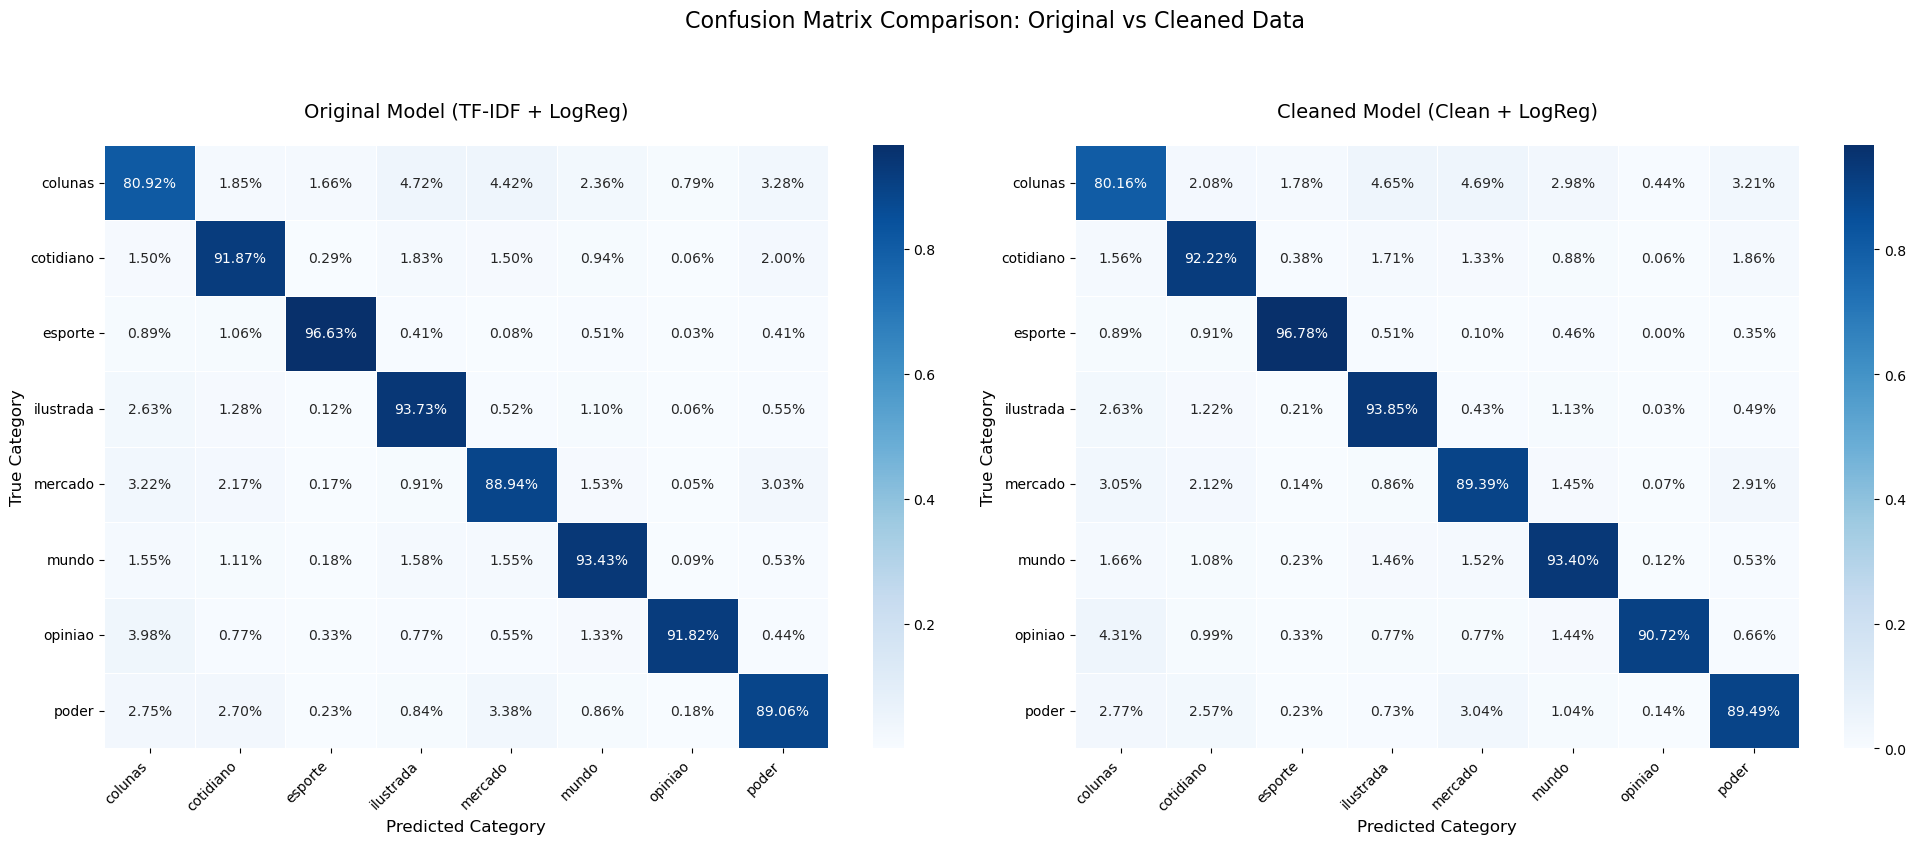

In [55]:
# Normalize the confusion matrices
cm_original_norm = cm_original.astype('float') / cm_original.sum(axis=1)[:, np.newaxis]
cm_clean_norm = cm_clean.astype('float') / cm_clean.sum(axis=1)[:, np.newaxis]

# Create side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Plot first confusion matrix (Original/TF-IDF)
sns.heatmap(cm_original_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=classes, yticklabels=classes, 
            linewidths=0.5, ax=ax1)
ax1.set_title('Original Model (TF-IDF + LogReg)', fontsize=14, pad=20)
ax1.set_xlabel('Predicted Category', fontsize=12)
ax1.set_ylabel('True Category', fontsize=12)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
ax1.set_yticklabels(ax1.get_yticklabels(), rotation=0)

# Plot second confusion matrix (Clean model)
sns.heatmap(cm_clean_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=classes, yticklabels=classes, 
            linewidths=0.5, ax=ax2)
ax2.set_title('Cleaned Model (Clean + LogReg)', fontsize=14, pad=20)
ax2.set_xlabel('Predicted Category', fontsize=12)
ax2.set_ylabel('True Category', fontsize=12)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
ax2.set_yticklabels(ax2.get_yticklabels(), rotation=0)

plt.suptitle('Confusion Matrix Comparison: Original vs Cleaned Data', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

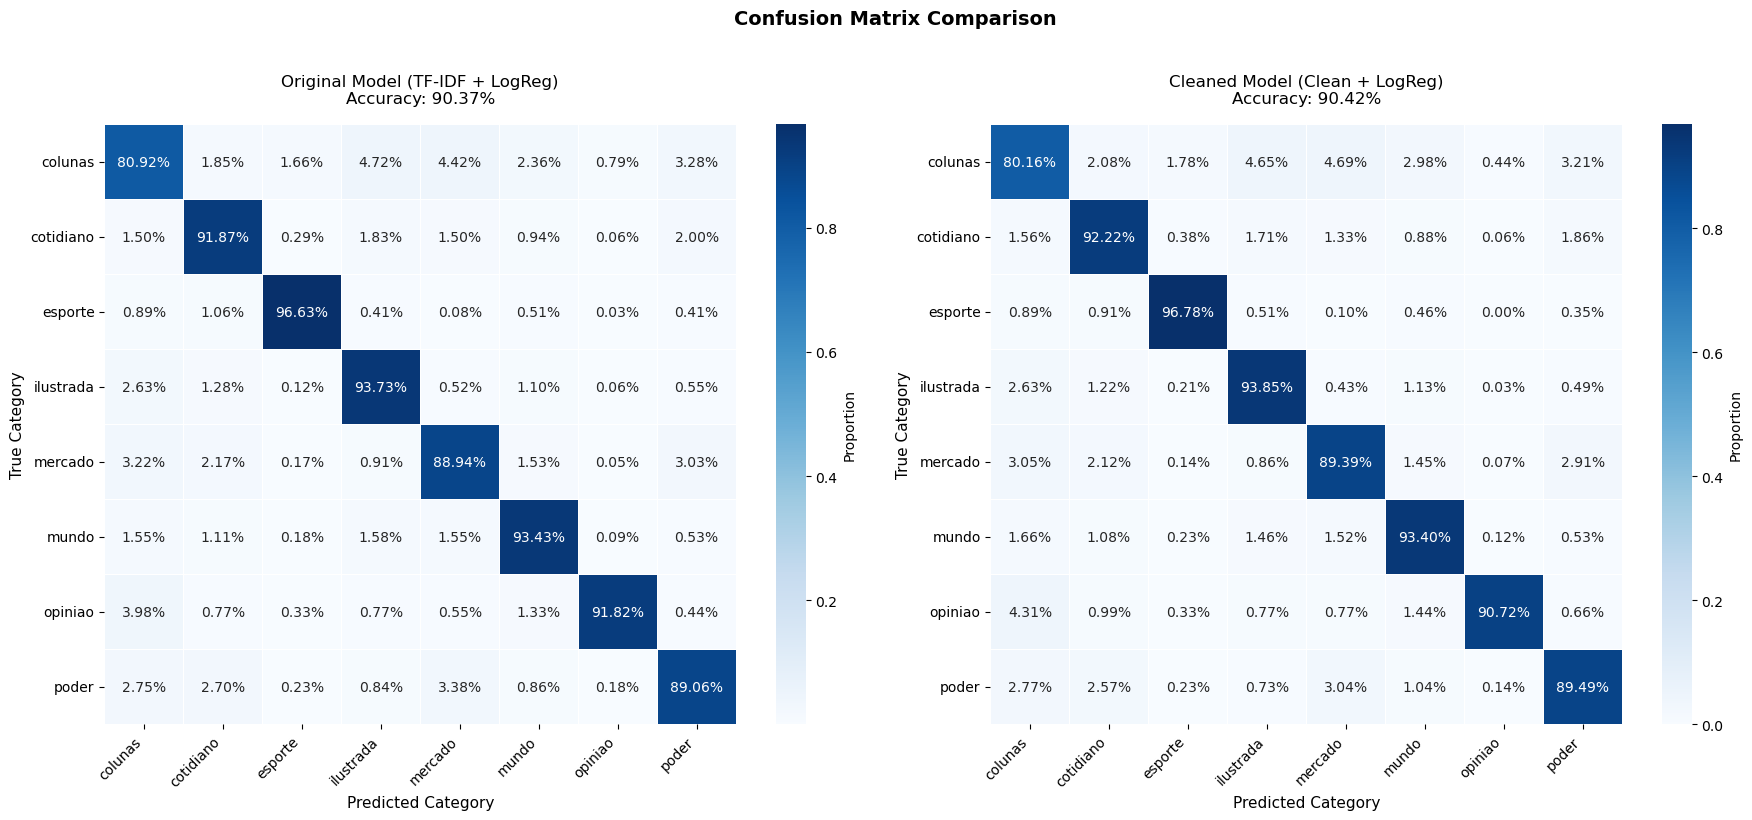

In [57]:
# Calculate accuracy
acc_original = np.trace(cm_original) / np.sum(cm_original)
acc_clean = np.trace(cm_clean) / np.sum(cm_clean)

# Create figure with subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Plot first matrix
im1 = sns.heatmap(cm_original_norm, annot=True, fmt='.2%', cmap='Blues',
                  xticklabels=classes, yticklabels=classes,
                  linewidths=0.5, ax=ax1, cbar=True, cbar_kws={'label': 'Proportion'})
ax1.set_title(f'Original Model (TF-IDF + LogReg)\nAccuracy: {acc_original:.2%}', 
              fontsize=12, pad=15)
ax1.set_xlabel('Predicted Category', fontsize=11)
ax1.set_ylabel('True Category', fontsize=11)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
ax1.set_yticklabels(ax1.get_yticklabels(), rotation=0)

# Plot second matrix
im2 = sns.heatmap(cm_clean_norm, annot=True, fmt='.2%', cmap='Blues',
                  xticklabels=classes, yticklabels=classes,
                  linewidths=0.5, ax=ax2, cbar=True, cbar_kws={'label': 'Proportion'})
ax2.set_title(f'Cleaned Model (Clean + LogReg)\nAccuracy: {acc_clean:.2%}', 
              fontsize=12, pad=15)
ax2.set_xlabel('Predicted Category', fontsize=11)
ax2.set_ylabel('True Category', fontsize=11)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
ax2.set_yticklabels(ax2.get_yticklabels(), rotation=0)

plt.suptitle('Confusion Matrix Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

##### <span style="color:green">Confusion Pattern Changes</span>

In [ ]:
# Calculate changes in confusion patterns
print("CONFUSION PATTERN CHANGES AFTER REMOVING 'disse'")
for i, true_cat in enumerate(classes):
    for j, pred_cat in enumerate(classes):
        if i != j:
            original_conf = cm_original[i][j]
            clean_conf = cm_clean[i][j]
            if clean_conf != original_conf:
                change = clean_conf - original_conf
                print(f"{true_cat:12} → {pred_cat:12}: {original_conf:4d} → {clean_conf:4d} ({change:+3d})")

# Identify if any category improved significantly
print("\nPER-CATEGORY F1 SCORE COMPARISON")

# Get per-category F1 scores for both models
report_original = classification_report(y_test, y_pred_tfidf, output_dict=True)
report_clean = classification_report(y_test, y_pred_clean, output_dict=True)

for cat in classes:
    f1_orig = report_original[cat]['f1-score']
    f1_clean = report_clean[cat]['f1-score']
    change = (f1_clean - f1_orig) * 100
    arrow = "↑" if change > 0 else "↓" if change < 0 else "→"
    print(f"{cat:12}: {f1_orig:.4f} → {f1_clean:.4f} ({arrow}{abs(change):.2f}%)")

##### <span style="color:green">Feature Coefficient by Category</span>

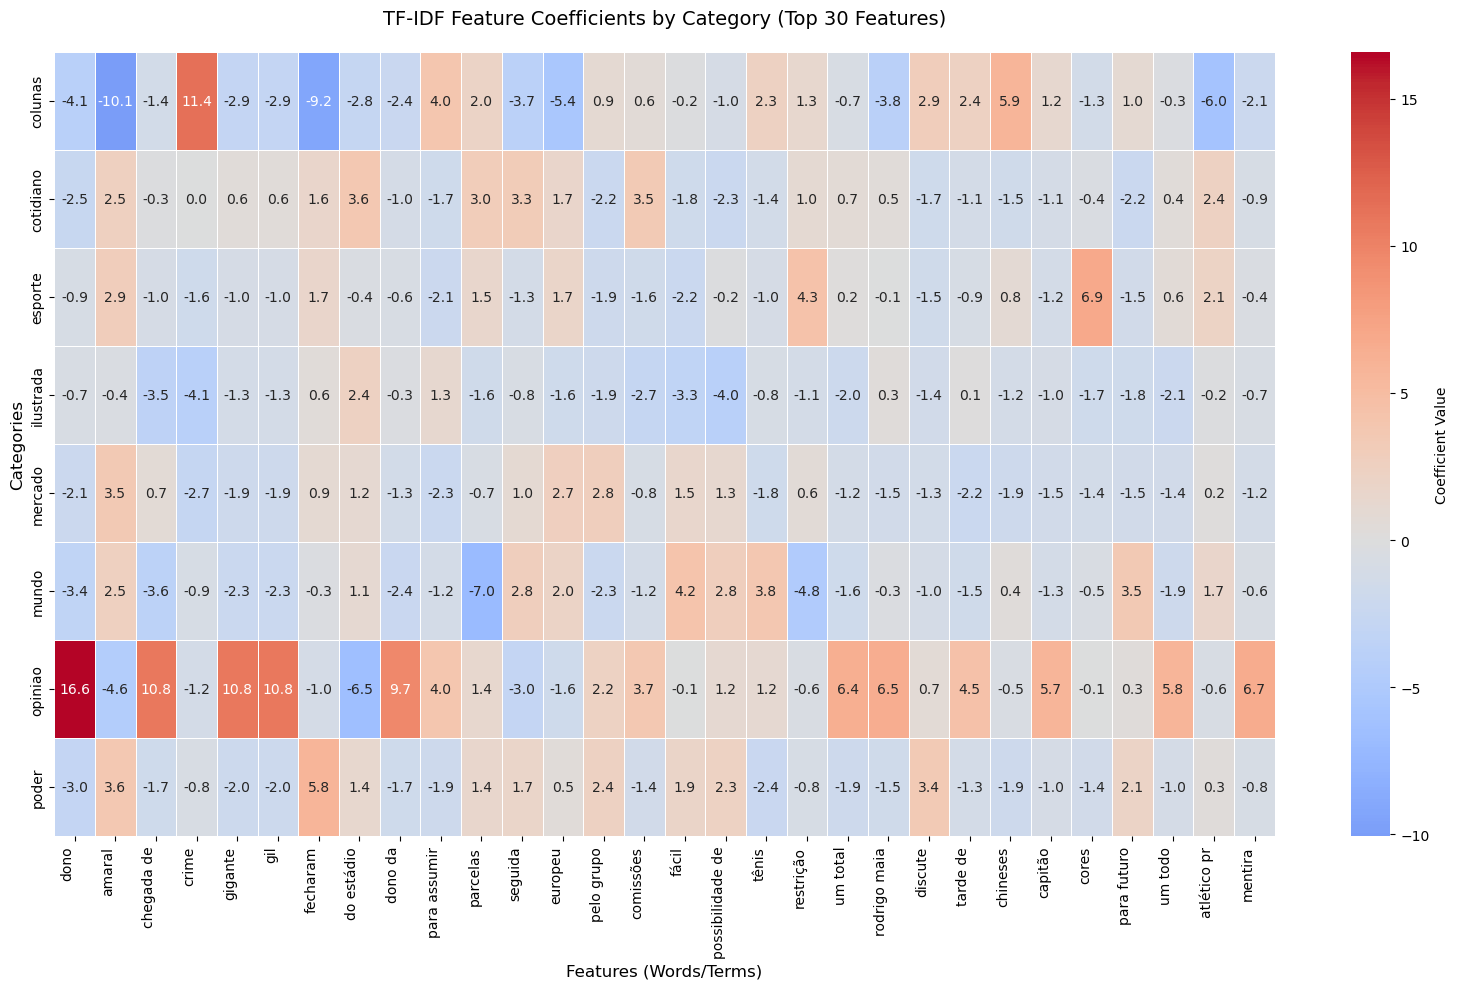

In [72]:
# Extract the vectorizer and model from the pipeline
tfidf_vectorizer = pipeline_tfidf_clean.named_steps['tfidf']
model = pipeline_tfidf_clean.named_steps['clf']

# Get feature names (words)
feature_names = vectorizer.get_feature_names_out()

# Get coefficients from the model
# For multi-class Logistic Regression, coef_ shape is (n_classes, n_features)
coefficients = model.coef_  # Shape: (n_categories, n_vocabulary)

# Create DataFrame of coefficients
coef_df = pd.DataFrame(
    coefficients,
    columns=feature_names,
    index=classes
)

# For better visualization, select top N features per category
# Let's get top n features across all categories
n_top_features = 30

# Get the absolute mean coefficients across categories to find important features
mean_abs_coefs = coef_df.abs().mean(axis=0).sort_values(ascending=False)
top_features = mean_abs_coefs.head(n_top_features).index

# Subset the DataFrame to top features
coef_df_top = coef_df[top_features]

# Plot heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(coef_df_top, annot=True, fmt='.1f', cmap='coolwarm', center=0, linewidths=0.5, cbar_kws={'label': 'Coefficient Value'})
plt.title(f'TF-IDF Feature Coefficients by Category (Top {n_top_features} Features)', fontsize=14, pad=20)
plt.xlabel('Features (Words/Terms)', fontsize=12)
plt.ylabel('Categories', fontsize=12)
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

##### <span style="color:green">Top 5 Predictive Features by Category</span>

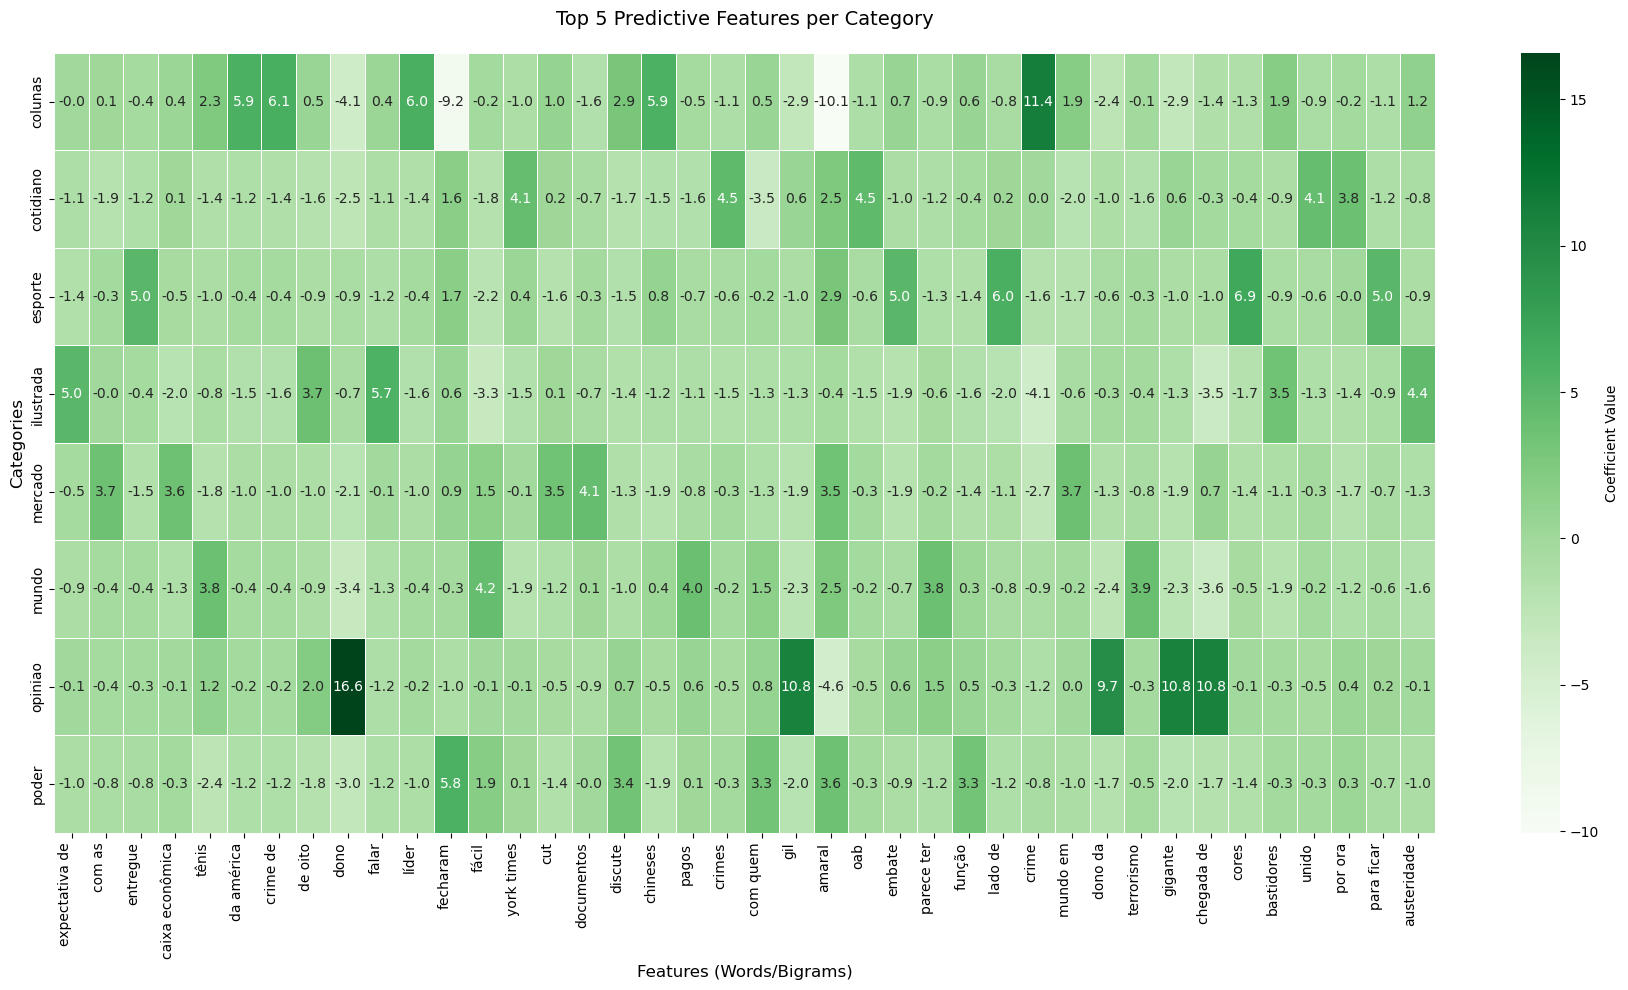

In [70]:
# Get top features for each category
n_top_per_category = 5
top_features_per_category = []

for category in classes:
    top_positive = coef_df.loc[category].nlargest(n_top_per_category).index
    top_features_per_category.extend(top_positive)

# Get unique features
unique_top_features = list(set(top_features_per_category))

# Create heatmap
plt.figure(figsize=(18, 10))
sns.heatmap(
    coef_df[unique_top_features], 
    annot=True, 
    fmt='.1f', 
    cmap='Greens',
    linewidths=0.5,
    cbar_kws={'label': 'Coefficient Value'}
)
plt.title(f'Top {n_top_per_category} Predictive Features per Category', fontsize=14, pad=20)
plt.xlabel('Features (Words/Bigrams)', fontsize=12)
plt.ylabel('Categories', fontsize=12)
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

##### <span style="color:green">Feature Importance Distribution by Category</span>

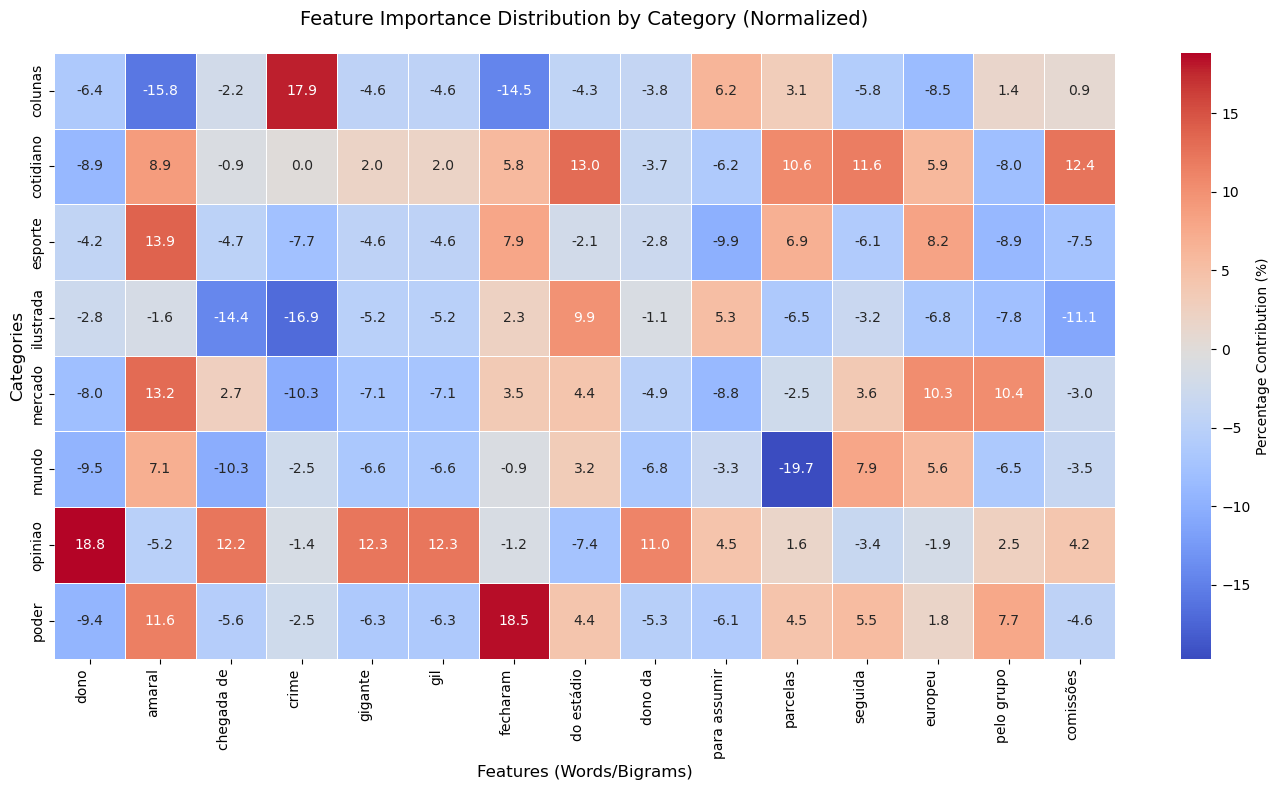

In [74]:
# Select top features
n_top_features = 15
mean_abs_coefs = coef_df.abs().mean(axis=0).sort_values(ascending=False)
top_features = mean_abs_coefs.head(n_top_features).index
coef_df_top = coef_df[top_features]

# Normalize row-wise (sum to 100% for each category)
coef_df_normalized = coef_df_top.div(coef_df_top.abs().sum(axis=1), axis=0) * 100

plt.figure(figsize=(14, 8))
sns.heatmap(
    coef_df_normalized, 
    annot=True, 
    fmt='.1f', 
    cmap='coolwarm',
    linewidths=0.5,
    cbar_kws={'label': 'Percentage Contribution (%)'}
)
plt.title('Feature Importance Distribution by Category (Normalized)', fontsize=14, pad=20)
plt.xlabel('Features (Words/Bigrams)', fontsize=12)
plt.ylabel('Categories', fontsize=12)
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

##### <span style="color:green">Top 10 Predictive Words by Category</span>

In [75]:
print("TOP 10 PREDICTIVE WORDS PER CATEGORY")

for category in classes:
    print(f"\n{category.upper()}:")
    top_words = coef_df.loc[category].nlargest(10)
    for i, (word, coef) in enumerate(top_words.items(), 1):
        print(f"  {i}. '{word}' → {coef:.4f}")

TOP 10 PREDICTIVE WORDS PER CATEGORY

COLUNAS:
  1. 'crime' → 11.3717
  2. 'crime de' → 6.1438
  3. 'líder' → 5.9883
  4. 'da américa' → 5.9280
  5. 'chineses' → 5.8590
  6. 'crimes de' → 5.7535
  7. 'executiva' → 5.7147
  8. 'tem se' → 4.7080
  9. 'resultado da' → 4.5814
  10. 'grátis' → 4.5614

COTIDIANO:
  1. 'oab' → 4.5227
  2. 'crimes' → 4.5216
  3. 'unido' → 4.1280
  4. 'york times' → 4.1188
  5. 'por ora' → 3.8228
  6. 'do estádio' → 3.6426
  7. 'comissões' → 3.4711
  8. 'do plano' → 3.4565
  9. 'salas' → 3.4091
  10. 'zona leste' → 3.3241

ESPORTE:
  1. 'cores' → 6.9055
  2. 'lado de' → 5.9774
  3. 'embate' → 5.0314
  4. 'para ficar' → 4.9921
  5. 'entregue' → 4.9745
  6. 'baseada' → 4.9172
  7. 'baseado' → 4.5074
  8. 'baixos' → 4.5053
  9. 'torno de' → 4.5023
  10. 'lançado em' → 4.3558

ILUSTRADA:
  1. 'falar' → 5.6979
  2. 'expectativa de' → 5.0036
  3. 'austeridade' → 4.4341
  4. 'de oito' → 3.7115
  5. 'bastidores' → 3.5365
  6. 'na internet' → 3.5113
  7. 'seu país' → 3.